C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\940620255.py:29: DtypeWarning: Columns (0: centroid_in_cell_mask, 1: pw_mask, 2: pw_source_label_file, 3: partially_wrapped_group_name, 4: partially_wrapped, 5: corrected_mito_source_label_file, 6: corrected_mito_unique_ID, 7: corrected_mito_group_name, 8: corrected_mito_key, 9: is_main_mitolysosome, 10: is_mitolysosome_content, 11: parent_source_label_file, 12: parent_annotation_uid, 13: content_morphology_response, 14: content_morphology_label, 15: content_morphology_status, 16: content_morphology_rated) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)
C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\940620255.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfr

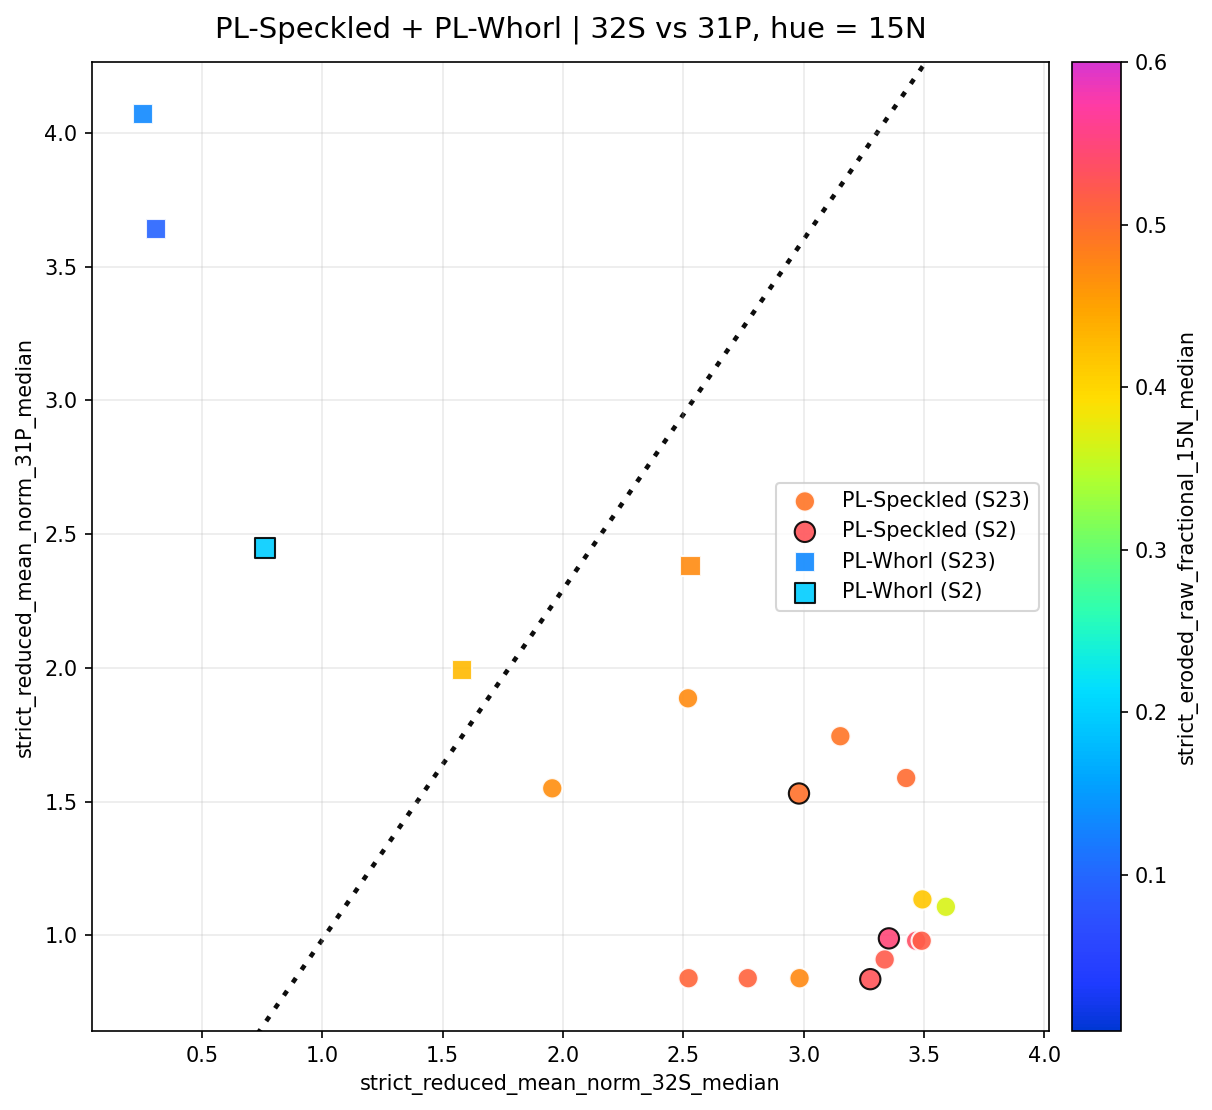

Saved: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_analysis\pl_speckled_pl_whorl_kmeans.pdf


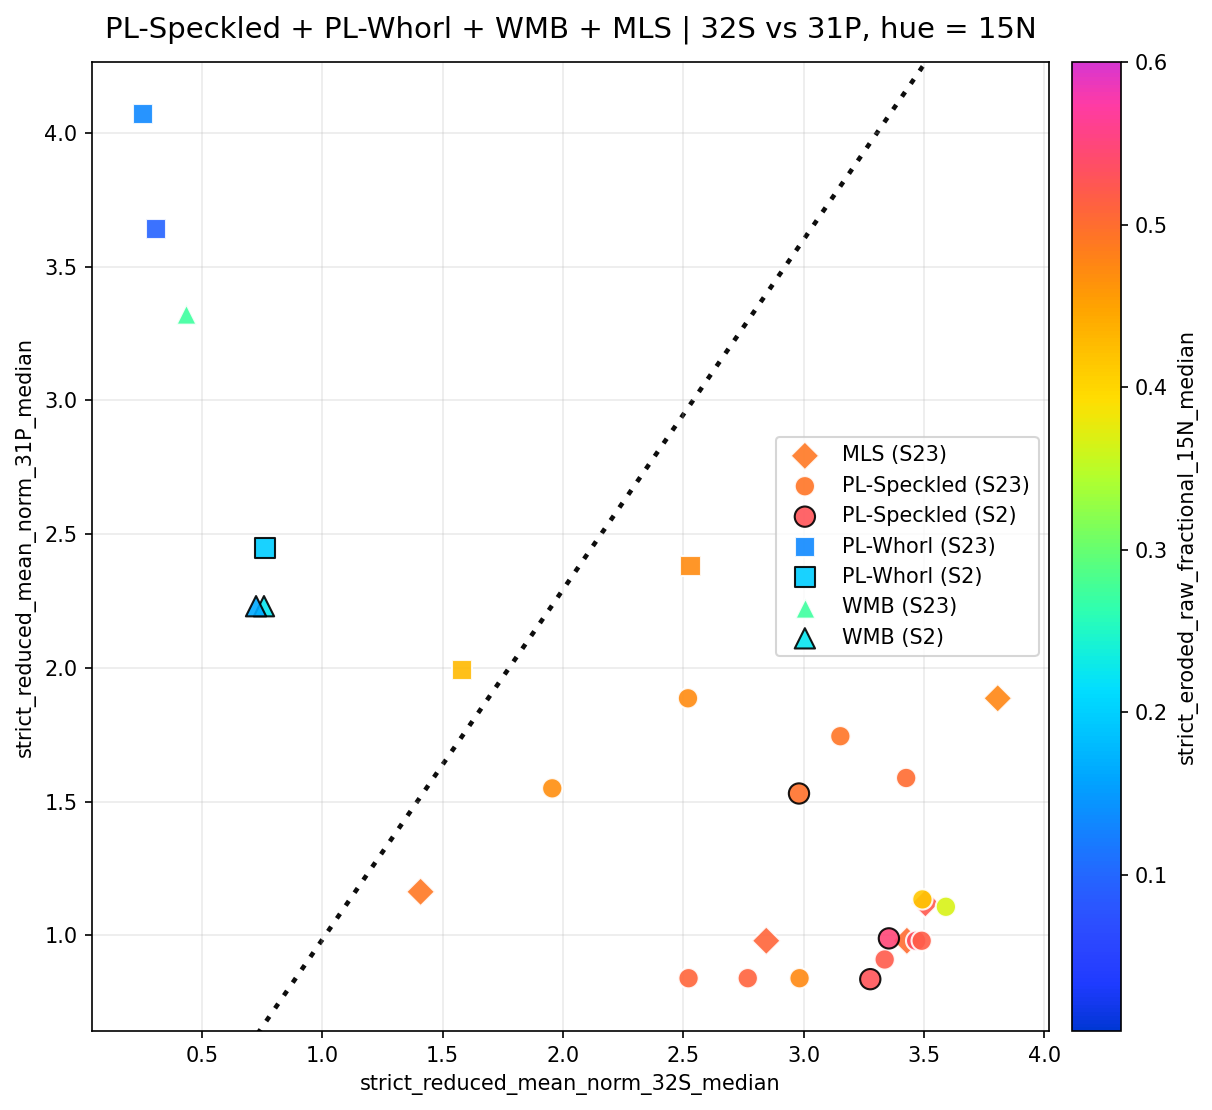

Saved: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_analysis\pl_speckled_pl_whorl_wmb_mls_kmeans.pdf


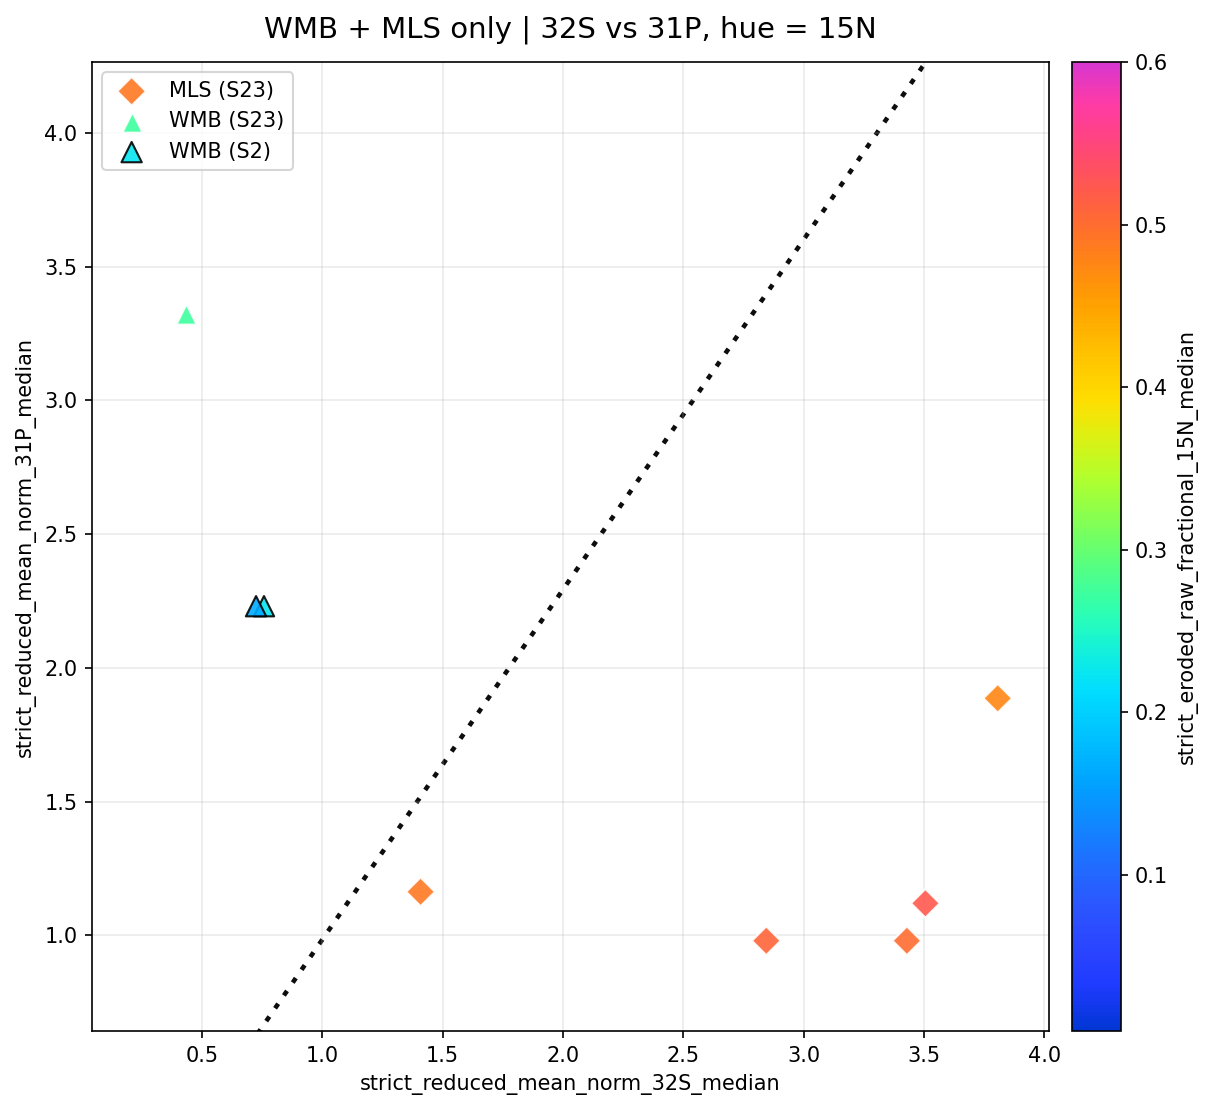

Saved: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_analysis\wmb_mls_only_kmeans.pdf


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.cluster import KMeans
from pathlib import Path

# ----------------------------
# File paths
# ----------------------------
base_dir = Path.cwd()
data_path = base_dir / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv"
lut_path = base_dir / "LUT.csv"
output_dir = base_dir / "output_lysosome_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

output_pdf_pl_only = output_dir / "pl_speckled_pl_whorl_kmeans.pdf"
output_pdf_pl_wmb_mls = output_dir / "pl_speckled_pl_whorl_wmb_mls_kmeans.pdf"
output_pdf_wmb_mls_only = output_dir / "wmb_mls_only_kmeans.pdf"

# Illustrator-friendly PDF settings
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(data_path)
lut = pd.read_csv(lut_path)

# ----------------------------
# Custom colormap from LUT.csv
# ----------------------------
lut_rgb = lut[["Red", "Green", "Blue"]].to_numpy() / 255.0
custom_cmap = ListedColormap(lut_rgb, name="custom_lut")
norm_15n = Normalize(vmin=0.0037, vmax=0.6, clip=True)

# ----------------------------
# Metadata
# ----------------------------
df["category"] = df["source_label_file"].astype(str).str.split("_").str[0]
df["sample_prefix"] = df["sample"].astype(str).str.split("_").str[0]

# Exclude S21 globally
df = df[df["sample_prefix"] != "S21"].copy()

# ----------------------------
# Columns
# ----------------------------
x_col = "strict_reduced_mean_norm_32S_median"
y_col = "strict_reduced_mean_norm_31P_median"
c_col = "strict_eroded_raw_fractional_15N_median"

for col in [x_col, y_col, c_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# KMeans helper
# ----------------------------
def fit_kmeans(x, y):
    pts = np.column_stack([x, y])
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    km.fit(pts)
    return km.cluster_centers_

def plot_boundary(ax, c1, c2, **line_kwargs):
    midpoint = (c1 + c2) / 2.0
    d = c2 - c1
    dx, dy = d

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    if abs(dy) < 1e-12:
        ax.axvline(midpoint[0], **line_kwargs)
        return

    x = np.linspace(xlim[0], xlim[1], 200)
    y = midpoint[1] - (dx / dy) * (x - midpoint[0])

    if np.all((y < ylim[0]) | (y > ylim[1])):
        y = np.linspace(ylim[0], ylim[1], 200)
        x = midpoint[0] - (dy / dx) * (y - midpoint[1])

    ax.plot(x, y, **line_kwargs)

# ----------------------------
# Plot styling
# ----------------------------
marker_map = {
    "PL-Speckled": "o",
    "PL-Whorl": "s",
    "WMB": "^",
    "MLS": "D",
}

# ----------------------------
# Helper to assign plot categories
# ----------------------------
def add_plot_category(dataframe):
    out = dataframe.copy()
    out["plot_category"] = out["category"]

    wmb_mask = out["source_label_file"].astype(str).str.contains("WMB", case=False, na=False)
    mls_mask = out["source_label_file"].astype(str).str.contains("MLS", case=False, na=False)

    out.loc[wmb_mask, "plot_category"] = "WMB"
    out.loc[mls_mask, "plot_category"] = "MLS"
    return out

# ----------------------------
# Subsets
# ----------------------------
pl_only = df[df["category"].isin(["PL-Speckled", "PL-Whorl"])].dropna(subset=[x_col, y_col, c_col]).copy()
pl_only = pl_only[pl_only["sample_prefix"].isin(["S2", "S23"])].copy()
pl_only = add_plot_category(pl_only)

pl_wmb_mls = df[
    (
        df["category"].isin(["PL-Speckled", "PL-Whorl"]) |
        df["source_label_file"].astype(str).str.contains("WMB", case=False, na=False) |
        df["source_label_file"].astype(str).str.contains("MLS", case=False, na=False)
    )
].dropna(subset=[x_col, y_col, c_col]).copy()
pl_wmb_mls = pl_wmb_mls[pl_wmb_mls["sample_prefix"].isin(["S2", "S23"])].copy()
pl_wmb_mls = add_plot_category(pl_wmb_mls)

wmb_mls_only = df[
    (
        df["source_label_file"].astype(str).str.contains("WMB", case=False, na=False) |
        df["source_label_file"].astype(str).str.contains("MLS", case=False, na=False)
    )
].dropna(subset=[x_col, y_col, c_col]).copy()
wmb_mls_only = wmb_mls_only[wmb_mls_only["sample_prefix"].isin(["S2", "S23"])].copy()
wmb_mls_only = add_plot_category(wmb_mls_only)

# ----------------------------
# Build grayscale edge colors from samples
#   - 2 samples -> black and white
#   - >2 samples -> gray ramp
# ----------------------------
all_samples = sorted(
    pd.unique(
        pd.concat(
            [pl_only["sample_prefix"], pl_wmb_mls["sample_prefix"], wmb_mls_only["sample_prefix"]],
            ignore_index=True
        ).dropna()
    )
)

def make_sample_edgecolor_map(sample_list):
    sample_list = list(sample_list)
    if len(sample_list) == 0:
        return {}
    if len(sample_list) == 1:
        return {sample_list[0]: "black"}
    if len(sample_list) == 2:
        return {
            sample_list[0]: "black",
            sample_list[1]: "white",
        }

    # More than 2 samples: use a grayscale ramp from dark gray to light gray
    vals = np.linspace(0.20, 0.85, len(sample_list))
    return {s: str(v) for s, v in zip(sample_list, vals)}

sample_edgecolor_map = make_sample_edgecolor_map(all_samples)

# ----------------------------
# Fit boundary ONLY from PL-Speckled + PL-Whorl
# ----------------------------
pl_boundary_df = pl_only[pl_only["plot_category"].isin(["PL-Speckled", "PL-Whorl"])].copy()
pl_centers = None
if len(pl_boundary_df) >= 2:
    pl_centers = fit_kmeans(pl_boundary_df[x_col].to_numpy(), pl_boundary_df[y_col].to_numpy())

# ----------------------------
# Shared axis limits across all three plots
# ----------------------------
all_for_limits = pd.concat([pl_only, pl_wmb_mls, wmb_mls_only], ignore_index=True)
all_for_limits = all_for_limits.dropna(subset=[x_col, y_col, c_col]).copy()

x_min, x_max = all_for_limits[x_col].min(), all_for_limits[x_col].max()
y_min, y_max = all_for_limits[y_col].min(), all_for_limits[y_col].max()

x_pad = (x_max - x_min) * 0.06 if x_max > x_min else 1.0
y_pad = (y_max - y_min) * 0.06 if y_max > y_min else 1.0

shared_xlim = (x_min - x_pad, x_max + x_pad)
shared_ylim = (y_min - y_pad, y_max + y_pad)

# ----------------------------
# Plot function
# ----------------------------
def make_plot(data, title, output_pdf, boundary_centers=None):
    fig, ax = plt.subplots(figsize=(8.5, 7.5), dpi=150)

    # Plot by category and sample, using grayscale edge colors only
    for cat in data["plot_category"].dropna().unique():
        dcat = data[data["plot_category"] == cat]
        for sample in dcat["sample_prefix"].dropna().unique():
            dsub = dcat[dcat["sample_prefix"] == sample]
            if dsub.empty:
                continue

            ax.scatter(
                dsub[x_col],
                dsub[y_col],
                c=dsub[c_col],
                cmap=custom_cmap,
                norm=norm_15n,
                s=95,  # larger markers
                marker=marker_map.get(cat, "o"),
                edgecolors=sample_edgecolor_map.get(sample, "black"),
                linewidths=1.0,
                alpha=0.90,
                label=f"{cat} ({sample})",
                zorder=2,
            )

    ax.set_xlim(shared_xlim)
    ax.set_ylim(shared_ylim)

    if boundary_centers is not None:
        plot_boundary(
            ax,
            boundary_centers[0],
            boundary_centers[1],
            color="black",
            linestyle=(0, (1.2, 2.2)),
            linewidth=2.2,
            alpha=0.95,
            zorder=1,
        )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), frameon=True)

    sm = ScalarMappable(norm=norm_15n, cmap=custom_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(c_col)

    plt.tight_layout()
    fig.savefig(
        output_pdf,
        format="pdf",
        bbox_inches="tight",
        transparent=False,
        metadata={"Title": title, "Creator": "Matplotlib"},
    )
    plt.show()
    print(f"Saved: {output_pdf}")

# ----------------------------
# Plot 1: PL only
# ----------------------------
make_plot(
    pl_only,
    "PL-Speckled + PL-Whorl | 32S vs 31P, hue = 15N",
    output_pdf_pl_only,
    boundary_centers=pl_centers,
)

# ----------------------------
# Plot 2: PL + WMB + MLS
# ----------------------------
make_plot(
    pl_wmb_mls,
    "PL-Speckled + PL-Whorl + WMB + MLS | 32S vs 31P, hue = 15N",
    output_pdf_pl_wmb_mls,
    boundary_centers=pl_centers,
)

# ----------------------------
# Plot 3: WMB + MLS only
# ----------------------------
make_plot(
    wmb_mls_only,
    "WMB + MLS only | 32S vs 31P, hue = 15N",
    output_pdf_wmb_mls_only,
    boundary_centers=pl_centers,
)

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\1916764630.py:46: DtypeWarning: Columns (0: centroid_in_cell_mask, 1: pw_mask, 2: pw_source_label_file, 3: partially_wrapped_group_name, 4: partially_wrapped, 5: corrected_mito_source_label_file, 6: corrected_mito_unique_ID, 7: corrected_mito_group_name, 8: corrected_mito_key, 9: is_main_mitolysosome, 10: is_mitolysosome_content, 11: parent_source_label_file, 12: parent_annotation_uid, 13: content_morphology_response, 14: content_morphology_label, 15: content_morphology_status, 16: content_morphology_rated) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)



[Cell] Within-replicate MWU tests (cell-level values):
  replicate wt_sample sl_sample  n_wt  n_sl  median_wt  median_sl   U  p_value  p_adj_holm sig_label
Replicate 1       S26        S2     7     9   0.230236   0.439687 0.0 0.000175    0.000206       ***
Replicate 2       S21       S23     7    10   0.267232   0.473118 0.0 0.000103    0.000206       ***


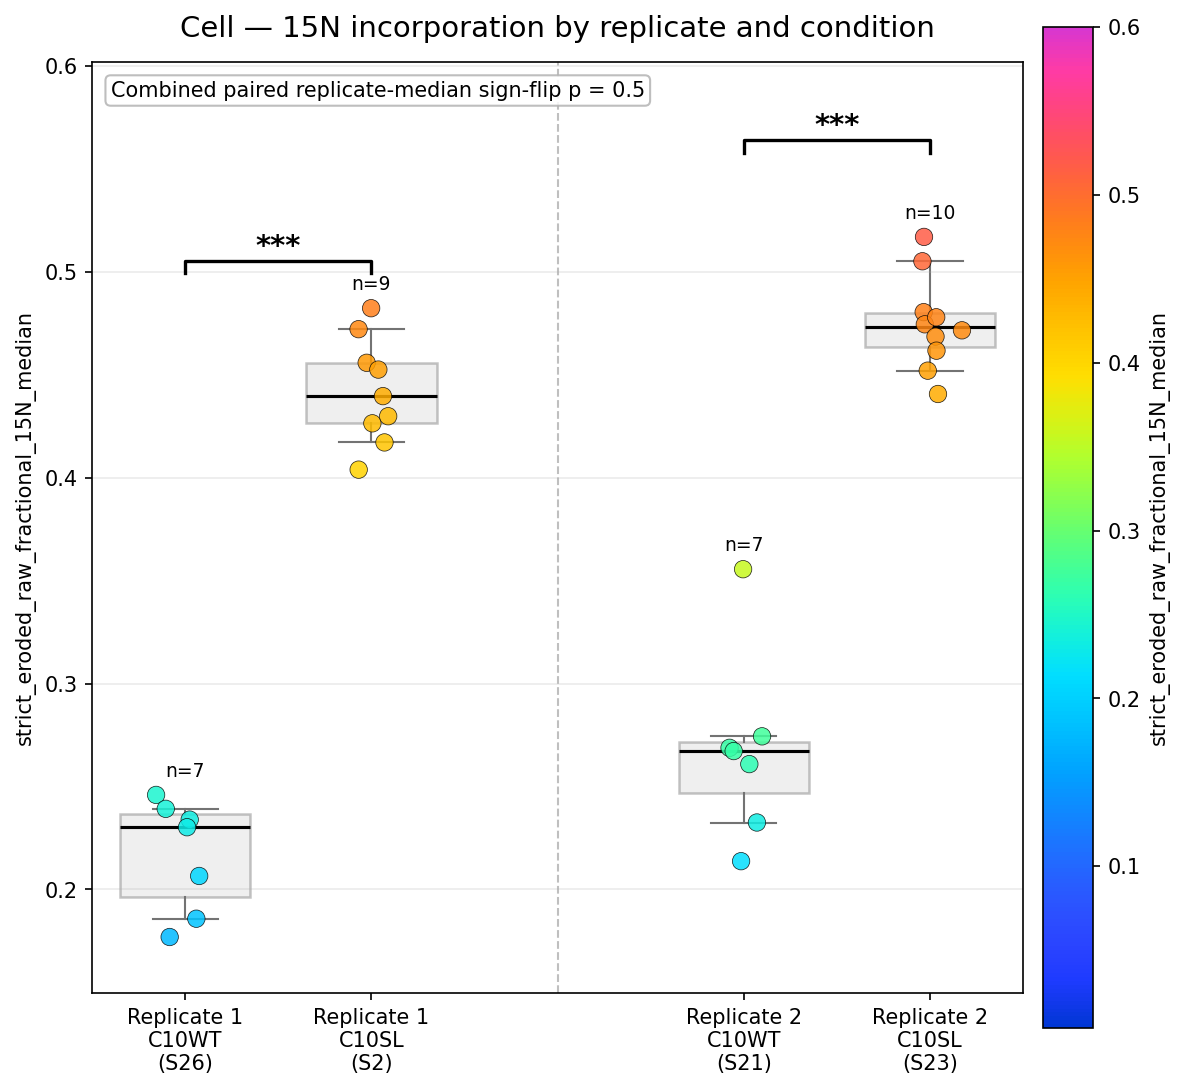


[Mitochondria] Within-replicate MWU tests (cell-level values):
  replicate wt_sample sl_sample  n_wt  n_sl  median_wt  median_sl     U       p_value    p_adj_holm sig_label
Replicate 2       S21       S23   546   609   0.200648    0.44902 546.0 1.917860e-188 1.917860e-188      ****


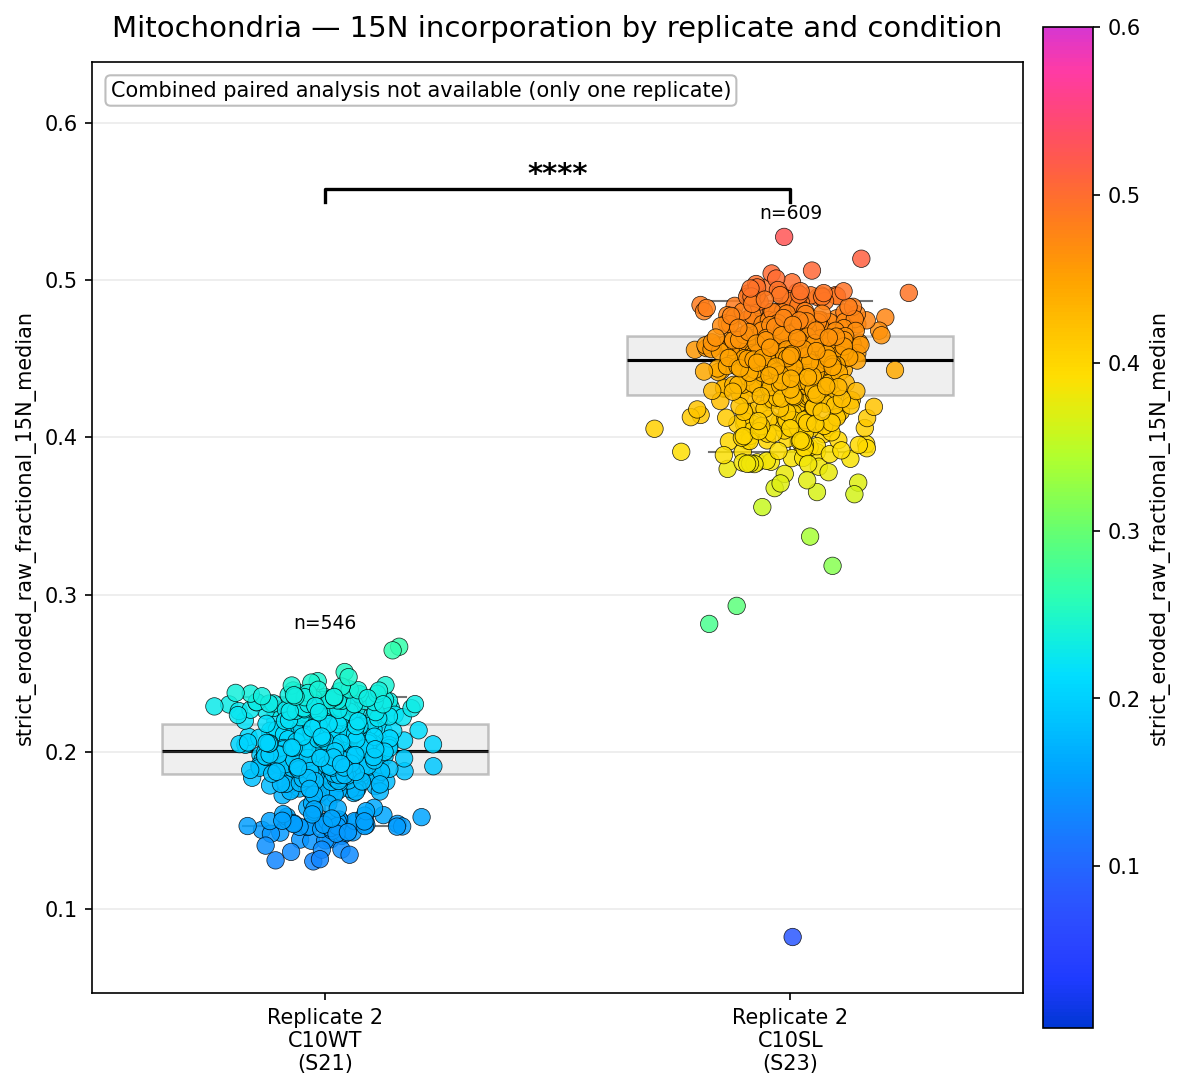


[Sarcomere] Within-replicate MWU tests (cell-level values):
  replicate wt_sample sl_sample  n_wt  n_sl  median_wt  median_sl   U      p_value   p_adj_holm sig_label
Replicate 1       S26        S2   192    61   0.256301   0.481239 0.0 6.243529e-32 6.243529e-32      ****
Replicate 2       S21       S23   386   228   0.288684   0.534716 0.0 2.310837e-95 4.621674e-95      ****


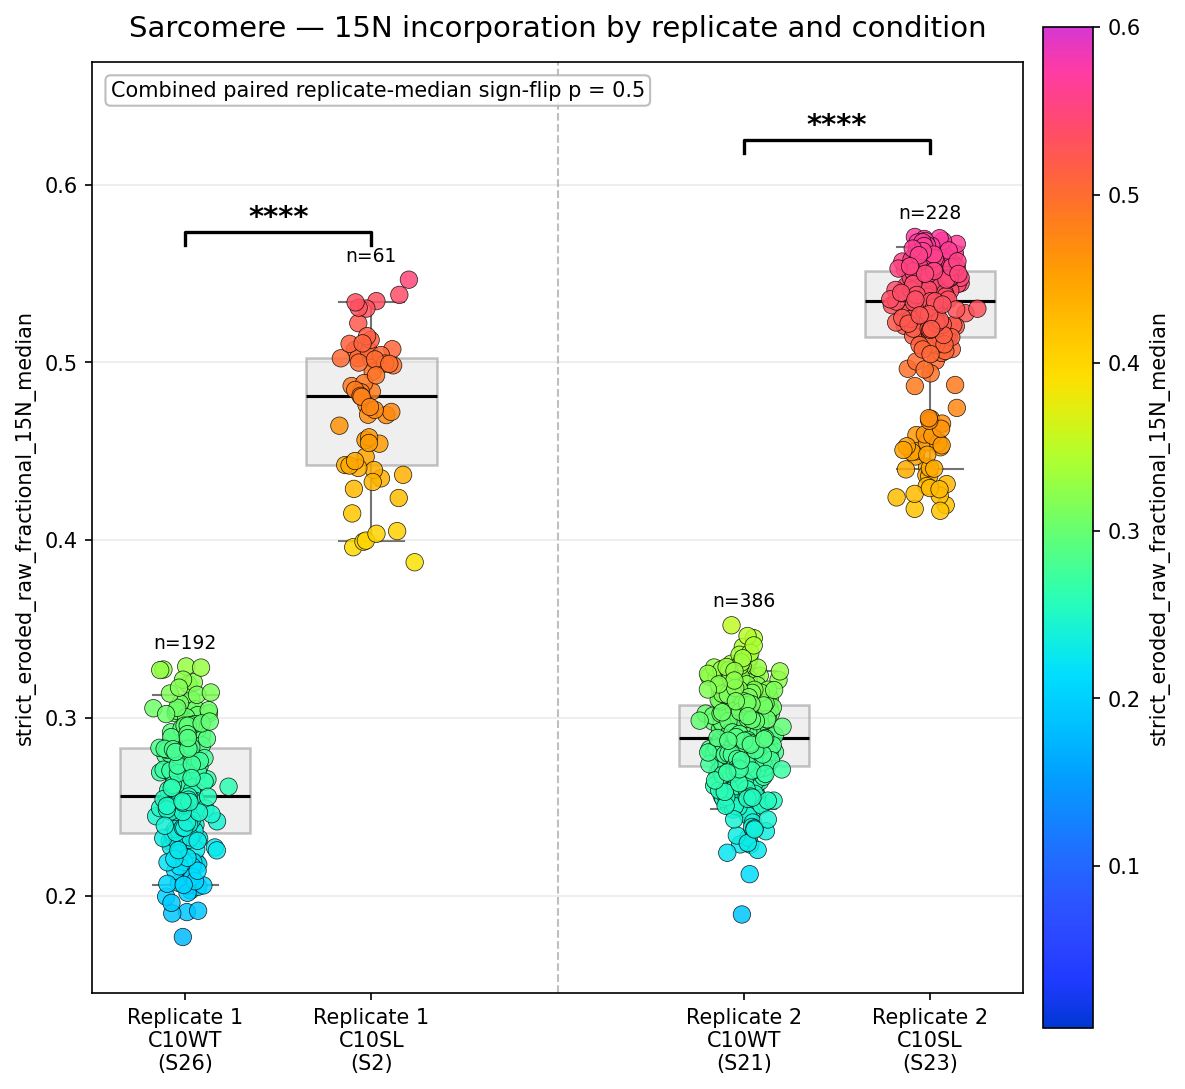


Saved Illustrator-friendly PDF to: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_wholecell_analysis\wholecell_15N_compartment_analysis.pdf


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import mannwhitneyu
from pathlib import Path
import itertools

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ----------------------------
# File paths (robust to notebook location)
# ----------------------------
base_dir = Path.cwd()
possible_data = [
    base_dir / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv",
    Path("/mnt/data/MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
]
possible_lut = [base_dir / "LUT.csv", Path("/mnt/data/LUT.csv")]

for p in possible_data:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("Could not find the input CSV file.")

for p in possible_lut:
    if p.exists():
        lut_path = p
        break
else:
    raise FileNotFoundError("Could not find LUT.csv.")

output_dir = base_dir / "output_wholecell_analysis"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "wholecell_15N_compartment_analysis.pdf"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(data_path)
lut = pd.read_csv(lut_path)

# Use the requested 15N median column, with a safe fallback
preferred_col = "strict_eroded_raw_fractional_15N_median"
if preferred_col in df.columns:
    c_col = preferred_col
else:
    candidates = [c for c in df.columns if ("fractional_15N" in c and "median" in c)]
    if not candidates:
        raise KeyError("No suitable 15N median column was found.")
    c_col = candidates[0]

# ----------------------------
# Custom LUT colormap
# ----------------------------
lut_rgb = lut[["Red", "Green", "Blue"]].to_numpy() / 255.0
custom_cmap = ListedColormap(lut_rgb, name="custom_lut")
vmin_15n, vmax_15n = 0.0037, 0.6
norm_15n = Normalize(vmin=vmin_15n, vmax=vmax_15n, clip=True)

# ----------------------------
# Helpers
# ----------------------------
def star_label(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=14):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.6, c="black", zorder=5)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold", zorder=6)


def exact_sign_flip_test(diffs):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    if len(diffs) == 0:
        return np.nan, np.nan
    obs = np.mean(diffs)
    if len(diffs) == 1:
        # With one replicate pair, the sign-flip distribution is just +/- the observed value.
        return obs, 1.0

    null_stats = []
    for signs in itertools.product([-1, 1], repeat=len(diffs)):
        null_stats.append(np.mean(np.asarray(signs) * diffs))
    null_stats = np.asarray(null_stats)
    p_two_sided = np.mean(np.abs(null_stats) >= abs(obs))
    return obs, p_two_sided


def mwu_p(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative="two-sided", method="auto")
    return stat, p

# ----------------------------
# Compartment definitions
# ----------------------------
# For each compartment, define which sample prefixes belong to replicate 1 or 2.
# Mitochondria is restricted to replicate 2 per the request.
compartments = [
    {
        "name": "Cell",
        "pattern": "cell_",
        "pairs": [
            ("Replicate 1", "C10WT", "S26", "C10SL", "S2"),
            ("Replicate 2", "C10WT", "S21", "C10SL", "S23"),
        ],
    },
    {
        "name": "Mitochondria",
        "pattern": "mitochondria",
        "pairs": [
            ("Replicate 2", "C10WT", "S21", "C10SL", "S23"),
        ],
    },
    {
        "name": "Sarcomere",
        "pattern": "sarcomere",
        "pairs": [
            ("Replicate 1", "C10WT", "S26", "C10SL", "S2"),
            ("Replicate 2", "C10WT", "S21", "C10SL", "S23"),
        ],
    },
]

# ----------------------------
# Read / parse once
# ----------------------------
df = df.copy()
df["source_label_lower"] = df["source_label_file"].astype(str).str.lower()
df["sample_prefix"] = df["sample"].astype(str).str.extract(r"^(S\d+)_", expand=False)
df[c_col] = pd.to_numeric(df[c_col], errors="coerce")

# ----------------------------
# Plot each compartment as a separate page in a multi-page PDF
# ----------------------------
with PdfPages(pdf_path) as pdf:
    for comp in compartments:
        analysis_df = df[
            df["source_label_lower"].str.contains(comp["pattern"], na=False)
            & df["sample_prefix"].notna()
        ].copy()

        if analysis_df.empty:
            print(f"[{comp['name']}] No rows matched; skipping.")
            continue

        # Keep only the desired sample prefixes that actually exist for this compartment.
        available_prefixes = set(analysis_df["sample_prefix"].dropna().unique())
        present_pairs = []
        for rep_name, wt_label, wt_sp, sl_label, sl_sp in comp["pairs"]:
            if wt_sp in available_prefixes and sl_sp in available_prefixes:
                present_pairs.append((rep_name, wt_label, wt_sp, sl_label, sl_sp))

        if not present_pairs:
            print(f"[{comp['name']}] No complete WT/SL pair found; skipping.")
            continue

        # Restrict to the plotted sample prefixes
        plotted_prefixes = {sp for pair in present_pairs for sp in (pair[2], pair[4])}
        analysis_df = analysis_df[analysis_df["sample_prefix"].isin(plotted_prefixes)].copy()
        analysis_df = analysis_df.dropna(subset=[c_col])

        # Dynamic x layout: each replicate pair gets two positions with a gap between pairs.
        x_positions = {}
        x_labels = {}
        group_order = []
        current_x = 0.0
        for i, (rep_name, wt_label, wt_sp, sl_label, sl_sp) in enumerate(present_pairs):
            x_positions[wt_sp] = current_x
            x_positions[sl_sp] = current_x + 1.0
            x_labels[wt_sp] = f"{rep_name}\n{wt_label}\n({wt_sp})"
            x_labels[sl_sp] = f"{rep_name}\n{sl_label}\n({sl_sp})"
            group_order.extend([wt_sp, sl_sp])
            current_x += 3.0

        analysis_df["sample_prefix"] = pd.Categorical(
            analysis_df["sample_prefix"], categories=group_order, ordered=True
        )
        analysis_df = analysis_df.sort_values("sample_prefix")

        # Statistics: within each replicate pair, run MWU on cell-level values; Holm-correct across pairs.
        pair_stats = []
        pair_pvals = []
        replicate_diffs = []
        for rep_name, wt_label, wt_sp, sl_label, sl_sp in present_pairs:
            wt_vals = analysis_df.loc[analysis_df["sample_prefix"] == wt_sp, c_col].to_numpy()
            sl_vals = analysis_df.loc[analysis_df["sample_prefix"] == sl_sp, c_col].to_numpy()
            stat, p = mwu_p(wt_vals, sl_vals)
            pair_stats.append({
                "replicate": rep_name,
                "wt_sample": wt_sp,
                "sl_sample": sl_sp,
                "n_wt": len(wt_vals),
                "n_sl": len(sl_vals),
                "median_wt": np.nanmedian(wt_vals) if len(wt_vals) else np.nan,
                "median_sl": np.nanmedian(sl_vals) if len(sl_vals) else np.nan,
                "U": stat,
                "p_value": p,
            })
            if np.isfinite(p):
                pair_pvals.append(p)
            replicate_diffs.append(
                (np.nanmedian(wt_vals) if len(wt_vals) else np.nan) -
                (np.nanmedian(sl_vals) if len(sl_vals) else np.nan)
            )

        # Holm correction for within-panel replicate tests
        if len(pair_pvals) > 1:
            order = np.argsort(pair_pvals)
            adj = np.empty(len(pair_pvals), dtype=float)
            m = len(pair_pvals)
            prev = 0.0
            for rank, idx in enumerate(order):
                corrected = min((m - rank) * pair_pvals[idx], 1.0)
                prev = max(prev, corrected)
                adj[idx] = prev
        elif len(pair_pvals) == 1:
            adj = np.asarray(pair_pvals)
        else:
            adj = np.asarray([])

        for i, val in enumerate(adj):
            pair_stats[i]["p_adj_holm"] = val
            pair_stats[i]["sig_label"] = star_label(val)

        stats_df = pd.DataFrame(pair_stats)
        print(f"\n[{comp['name']}] Within-replicate MWU tests (cell-level values):")
        print(stats_df.to_string(index=False))

        # Combined effect across replicates: paired sign-flip on replicate medians.
        finite_diffs = [d for d in replicate_diffs if np.isfinite(d)]
        if len(finite_diffs) >= 2:
            obs_diff, p_combined = exact_sign_flip_test(finite_diffs)
            combined_text = f"Combined paired replicate-median sign-flip p = {p_combined:.3g}"
        else:
            obs_diff, p_combined = exact_sign_flip_test(finite_diffs)
            combined_text = "Combined paired analysis not available (only one replicate)"

        # ----------------------------
        # Plot
        # ----------------------------
        fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
        ax.set_box_aspect(1)

        # Boxplots behind points
        box_data = []
        box_positions = []
        for sp in group_order:
            vals = analysis_df.loc[analysis_df["sample_prefix"] == sp, c_col].dropna().to_numpy()
            if len(vals) == 0:
                continue
            box_data.append(vals)
            box_positions.append(x_positions[sp])

        bp = ax.boxplot(
            box_data,
            positions=box_positions,
            widths=0.70,
            patch_artist=True,
            showfliers=False,
            whis=(5, 95),
            zorder=1,
        )
        for box in bp["boxes"]:
            box.set(facecolor="#D3D3D3", edgecolor="0.35", alpha=0.35, linewidth=1.2)
        for key in ["whiskers", "caps"]:
            for artist in bp[key]:
                artist.set(color="0.45", linewidth=1.0)
        for median in bp["medians"]:
            median.set(color="black", linewidth=1.5)

        # Points
        rng = np.random.default_rng(42)
        for sp in group_order:
            dsub = analysis_df[analysis_df["sample_prefix"] == sp]
            if dsub.empty:
                continue
            vals = dsub[c_col].to_numpy()
            x0 = x_positions[sp]
            x = np.full(len(vals), x0, dtype=float) + rng.normal(loc=0.0, scale=0.08, size=len(vals))
            ax.scatter(
                x,
                vals,
                c=vals,
                cmap=custom_cmap,
                norm=norm_15n,
                s=70,
                marker="o",
                alpha=0.85,
                edgecolors="black",
                linewidths=0.35,
                zorder=3,
            )
            ytext = np.nanmax(vals) + 0.02 * (np.nanmax(analysis_df[c_col]) - np.nanmin(analysis_df[c_col]) + 1e-9)
            ax.text(x0, ytext, f"n={len(vals)}", ha="center", va="bottom", fontsize=9)

        # Significance brackets above each complete replicate pair
        data_max = np.nanmax(analysis_df[c_col].to_numpy())
        data_min = np.nanmin(analysis_df[c_col].to_numpy())
        y_range = max(data_max - data_min, 1e-9)
        ax.set_ylim(data_min - 0.08 * y_range, data_max + 0.25 * y_range)

        for j, row in stats_df.reset_index(drop=True).iterrows():
            wt_sp = row["wt_sample"]
            sl_sp = row["sl_sample"]
            x1, x2 = x_positions[wt_sp], x_positions[sl_sp]
            sub = analysis_df[analysis_df["sample_prefix"].isin([wt_sp, sl_sp])]
            pair_max = np.nanmax(sub[c_col].to_numpy())
            y = pair_max + 0.05 * y_range + j * 0.07 * y_range
            h = 0.018 * y_range
            add_sig_bracket(ax, x1, x2, y, h, row["sig_label"], fontsize=14)

        # Group separators and labels
        if len(present_pairs) > 1:
            separators = []
            for i in range(len(present_pairs) - 1):
                right_x = x_positions[present_pairs[i][4]]
                left_next = x_positions[present_pairs[i + 1][2]]
                separators.append((right_x + left_next) / 2)
            for sep in separators:
                ax.axvline(sep, color="0.75", linestyle="--", linewidth=1.0, zorder=0)

        ax.set_xticks([x_positions[sp] for sp in group_order])
        ax.set_xticklabels([x_labels[sp] for sp in group_order], fontsize=10)
        ax.set_ylabel(c_col)
        ax.set_title(f"{comp['name']} — 15N incorporation by replicate and condition", fontsize=14, pad=12)
        ax.grid(True, axis="y", alpha=0.25)

        # Combined p-value annotation
        ax.text(
            0.02,
            0.98,
            combined_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.85),
        )

        # Colorbar
        sm = ScalarMappable(norm=norm_15n, cmap=custom_cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.05)
        cbar.set_label(c_col)

        fig.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print(f"\nSaved Illustrator-friendly PDF to: {pdf_path}")

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\3602195694.py:133: DtypeWarning: Columns (0: centroid_in_cell_mask, 1: pw_mask, 2: pw_source_label_file, 3: partially_wrapped_group_name, 4: partially_wrapped, 5: corrected_mito_source_label_file, 6: corrected_mito_unique_ID, 7: corrected_mito_group_name, 8: corrected_mito_key, 9: is_main_mitolysosome, 10: is_mitolysosome_content, 11: parent_source_label_file, 12: parent_annotation_uid, 13: content_morphology_response, 14: content_morphology_label, 15: content_morphology_status, 16: content_morphology_rated) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)
C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\3602195694.py:203: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `n

Saved Illustrator-editable PDF to:
c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_analysis\lysosome_category_15N_stripplot.pdf

Saved Illustrator-editable SVG to:
c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_analysis\lysosome_category_15N_stripplot.svg


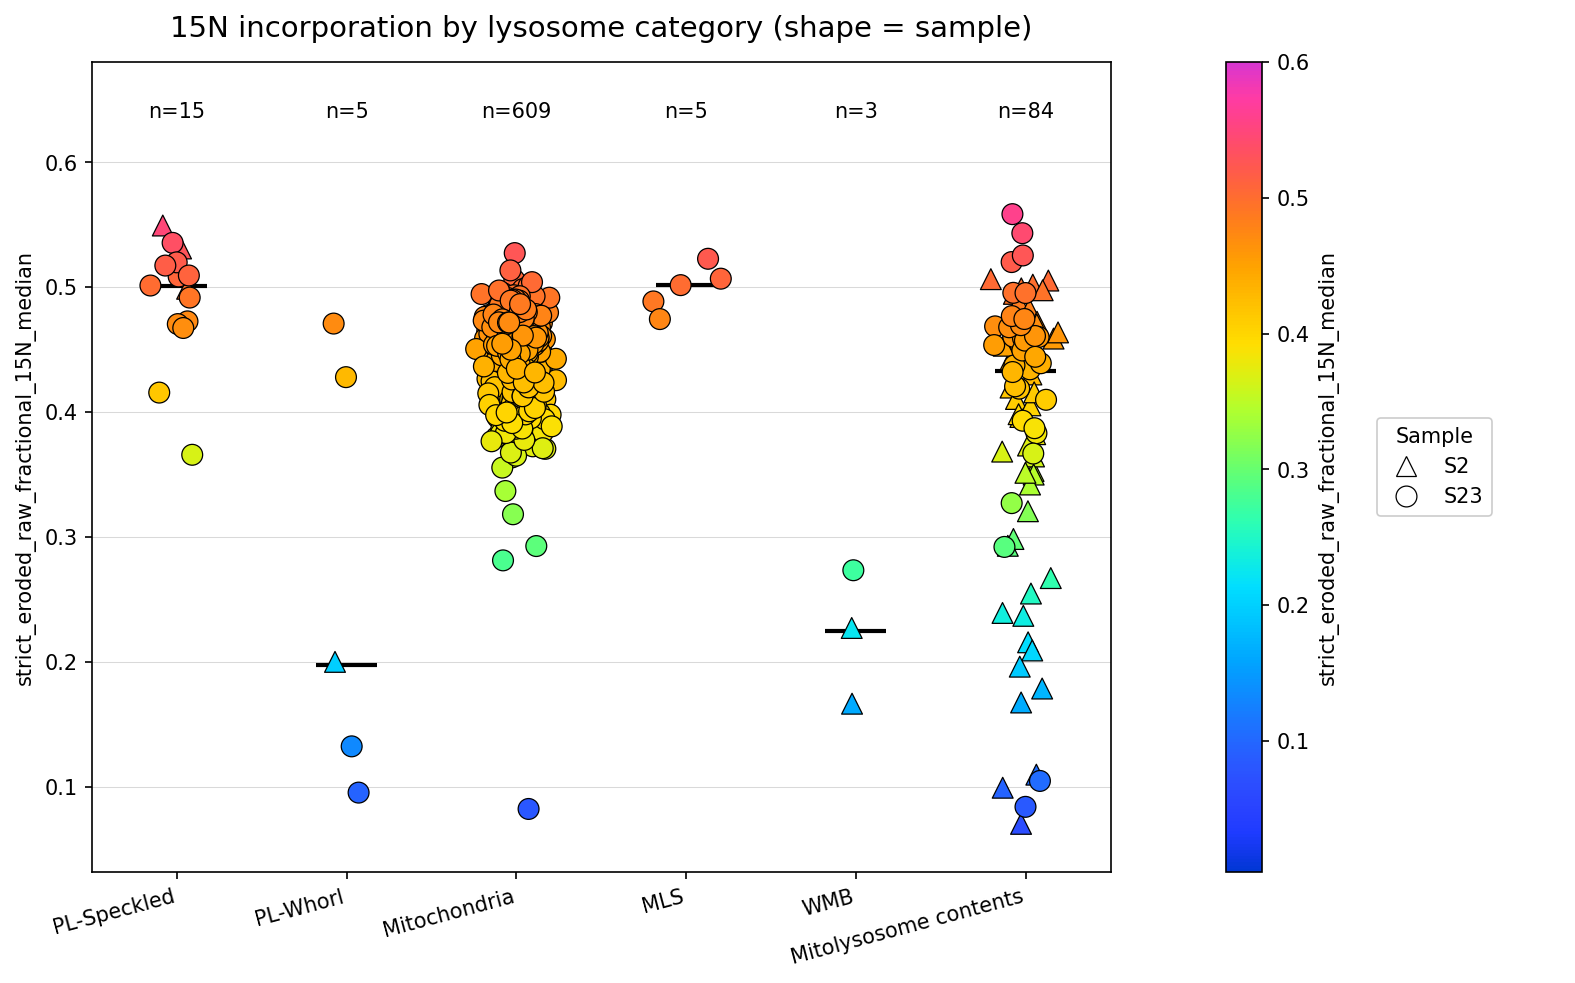


Kruskal-Wallis omnibus test:
H = 51.7500, p = 6.071e-10

Pairwise Mann-Whitney U tests (Holm-corrected):
     group_1               group_2  n_1  n_2  U_stat  p_value  p_adj_holm  significant_0.05
 PL-Speckled              PL-Whorl   15    5    69.0 0.003741    0.033669              True
 PL-Speckled          Mitochondria   15  609  7656.0 0.000008    0.000114              True
 PL-Speckled                   MLS   15    5    37.0 1.000000    1.000000             False
 PL-Speckled                   WMB   15    3    45.0 0.002451    0.026961              True
 PL-Speckled Mitolysosome contents   15   84  1048.0 0.000046    0.000646              True
    PL-Whorl          Mitochondria    5  609   659.0 0.028919    0.144594             False
    PL-Whorl                   MLS    5    5     0.0 0.007937    0.055556             False
    PL-Whorl                   WMB    5    3     7.0 1.000000    1.000000             False
    PL-Whorl Mitolysosome contents    5   84   123.0 0.126019    0

In [3]:
# ============================================================
# Lysosome-category 15N strip plot
# Illustrator-editable PDF and SVG export
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Polygon

from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from pathlib import Path


# ============================================================
# Illustrator-friendly Matplotlib settings
# ============================================================

plt.rcParams.update({
    # Preserve text as TrueType text in PDF rather than Type 3 outlines.
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Preserve text as editable text in SVG.
    "svg.fonttype": "none",

    # General export settings.
    "savefig.transparent": False,
    "axes.linewidth": 0.8,
})


# ============================================================
# User-adjustable appearance settings
#
# Line widths are in typographic points, corresponding directly
# to the stroke-width units shown in Adobe Illustrator.
# ============================================================

POINT_DIAMETER_PT = 10.0
POINT_EDGE_WIDTH_PT = 0.60
MEDIAN_WIDTH_PT = 2.0
AXIS_WIDTH_PT = 0.8
GRID_WIDTH_PT = 0.5

# Keep at 1.0 for the simplest Illustrator objects.
# Values below 1.0 introduce transparency groups.
POINT_FACE_ALPHA = 1.0

# "round" prevents sharp miter spikes at triangle corners.
# Other supported options include "miter" and "bevel".
POINT_JOINSTYLE = "round"

# Horizontal jitter applied around each category.
JITTER_SD = 0.08

# Random seed makes the jitter reproducible.
RANDOM_SEED = 42


# ============================================================
# File paths
# ============================================================

base_dir = Path.cwd()

data_path = base_dir / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv"
lut_path = base_dir / "LUT.csv"

output_dir = base_dir / "output_lysosome_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

pdf_output_file = output_dir / "lysosome_category_15N_stripplot.pdf"
svg_output_file = output_dir / "lysosome_category_15N_stripplot.svg"
stats_output_file = output_dir / "lysosome_category_15N_pairwise_statistics.csv"


# ============================================================
# Analysis settings
# ============================================================

c_col = "strict_eroded_raw_fractional_15N_median"

sample_list = [
    "S2",
    "S23",
]

categories = [
    "PL-Speckled",
    "PL-Whorl",
    "Mitochondria",
    "MLS",
    "WMB",
    "Mitolysosome contents",
]

# This preserves the marker mapping from the plotting portion of
# the original script:
#
# S2  = triangle
# S23 = circle
marker_map = {
    "S2": "^",
    "S23": "o",
}

# 15N color scaling range.
vmin_15n = 0.0037
vmax_15n = 0.6


# ============================================================
# Load and validate input files
# ============================================================

if not data_path.exists():
    raise FileNotFoundError(
        f"Could not find the data file:\n{data_path}"
    )

if not lut_path.exists():
    raise FileNotFoundError(
        f"Could not find the LUT file:\n{lut_path}"
    )

df = pd.read_csv(data_path)
lut = pd.read_csv(lut_path)

required_data_columns = {
    "source_label_file",
    "sample",
    c_col,
}

missing_data_columns = required_data_columns.difference(df.columns)

if missing_data_columns:
    raise KeyError(
        "combined_output.csv is missing the following required "
        f"columns: {sorted(missing_data_columns)}"
    )

required_lut_columns = {
    "Red",
    "Green",
    "Blue",
}

missing_lut_columns = required_lut_columns.difference(lut.columns)

if missing_lut_columns:
    raise KeyError(
        "LUT.csv is missing the following required columns: "
        f"{sorted(missing_lut_columns)}"
    )


# ============================================================
# Build custom colormap from LUT.csv
# ============================================================

lut_rgb_df = lut[
    ["Red", "Green", "Blue"]
].apply(
    pd.to_numeric,
    errors="coerce",
).dropna()

if len(lut_rgb_df) < 2:
    raise ValueError(
        "LUT.csv must contain at least two valid RGB rows."
    )

lut_rgb = lut_rgb_df.to_numpy(dtype=float) / 255.0
lut_rgb = np.clip(lut_rgb, 0.0, 1.0)

custom_cmap = ListedColormap(
    lut_rgb,
    name="custom_lut",
)

norm_15n = Normalize(
    vmin=vmin_15n,
    vmax=vmax_15n,
    clip=True,
)


# ============================================================
# Extract metadata
# ============================================================

source_label_text = df["source_label_file"].astype(str)
sample_text = df["sample"].astype(str)

df["category"] = source_label_text.str.split("_").str[0]
df["sample_prefix"] = sample_text.str.split("_").str[0]


# ============================================================
# Map source filenames to requested plot categories
# ============================================================

df["plot_category"] = pd.NA

pl_speckled_mask = df["category"].eq("PL-Speckled")
pl_whorl_mask = df["category"].eq("PL-Whorl")
mitochondria_mask = df["category"].eq("Mitochondria")

mls_mask = source_label_text.str.contains(
    "MLS",
    case=False,
    na=False,
)

wmb_mask = source_label_text.str.contains(
    "WMB",
    case=False,
    na=False,
)

mito_contents_mask = (
    source_label_text.str.contains(
        "Mitolysosome",
        case=False,
        na=False,
    )
    &
    source_label_text.str.contains(
        "Contents",
        case=False,
        na=False,
    )
)

df.loc[
    pl_speckled_mask,
    "plot_category",
] = "PL-Speckled"

df.loc[
    pl_whorl_mask,
    "plot_category",
] = "PL-Whorl"

df.loc[
    mitochondria_mask,
    "plot_category",
] = "Mitochondria"

df.loc[
    mls_mask,
    "plot_category",
] = "MLS"

df.loc[
    wmb_mask,
    "plot_category",
] = "WMB"

# This assignment is performed last so it takes precedence over
# any broader filename matches above.
df.loc[
    mito_contents_mask,
    "plot_category",
] = "Mitolysosome contents"


# ============================================================
# Filter and clean the analysis data
# ============================================================

analysis_df = df[
    df["plot_category"].isin(categories)
    &
    df["sample_prefix"].isin(sample_list)
].copy()

analysis_df[c_col] = pd.to_numeric(
    analysis_df[c_col],
    errors="coerce",
)

analysis_df = analysis_df.dropna(
    subset=[c_col]
)

if analysis_df.empty:
    raise ValueError(
        "No valid observations remain after filtering by category, "
        "sample, and numeric 15N values."
    )

analysis_df["plot_category"] = pd.Categorical(
    analysis_df["plot_category"],
    categories=categories,
    ordered=True,
)


# ============================================================
# Helper functions for Illustrator-editable datapoints
# ============================================================

def marker_size_in_data_units(ax, diameter_pt):
    """
    Convert a marker diameter from typographic points into x-axis
    and y-axis data units.

    This must be called after the figure layout has been finalized
    and fig.canvas.draw() has been called.

    The conversion is intended for linear axes.
    """

    fig = ax.figure

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    center_data = np.array([
        np.mean(xlim),
        np.mean(ylim),
    ], dtype=float)

    center_display = ax.transData.transform(center_data)

    # Matplotlib display coordinates are measured in pixels.
    diameter_pixels = diameter_pt * fig.dpi / 72.0

    shifted_display = center_display + np.array([
        diameter_pixels,
        diameter_pixels,
    ])

    shifted_data = ax.transData.inverted().transform(
        shifted_display
    )

    width_data = abs(
        shifted_data[0] - center_data[0]
    )

    height_data = abs(
        shifted_data[1] - center_data[1]
    )

    return width_data, height_data


def add_editable_marker(
    ax,
    x,
    y,
    marker,
    facecolor,
    width_data,
    height_data,
    gid,
):
    """
    Add one independent marker as a normal vector patch.

    Unlike ax.scatter(), this does not create a PathCollection.
    Each marker is exported as an independently selectable path
    with an ordinary fill and stroke.
    """

    common_style = {
        "facecolor": facecolor,
        "edgecolor": "black",
        "linewidth": POINT_EDGE_WIDTH_PT,
        "joinstyle": POINT_JOINSTYLE,
        "antialiased": True,

        # Avoid placing all datapoints inside an axes clipping mask.
        "clip_on": False,

        "zorder": 3,
    }

    if marker == "o":
        artist = Ellipse(
            xy=(x, y),
            width=width_data,
            height=height_data,
            **common_style,
        )

    elif marker == "^":
        # Vertices are arranged so that the visual centroid of the
        # triangle is positioned at x, y.
        vertices = np.array([
            [
                x,
                y + (2.0 / 3.0) * height_data,
            ],
            [
                x - width_data / 2.0,
                y - (1.0 / 3.0) * height_data,
            ],
            [
                x + width_data / 2.0,
                y - (1.0 / 3.0) * height_data,
            ],
        ])

        artist = Polygon(
            vertices,
            closed=True,
            **common_style,
        )

    else:
        raise ValueError(
            f"Unsupported marker {marker!r}. "
            "This function currently supports 'o' and '^'."
        )

    # SVG exports use this as the object's XML ID, which can help
    # distinguish datapoints in Illustrator or an XML editor.
    artist.set_gid(gid)

    ax.add_patch(artist)

    return artist


# ============================================================
# Establish y-axis range and annotation position
# ============================================================

all_y_values = analysis_df[c_col].to_numpy(dtype=float)

data_min = float(np.nanmin(all_y_values))
data_max = float(np.nanmax(all_y_values))

reference_span = max(
    data_max - data_min,
    vmax_15n - vmin_15n,
    1e-9,
)

n_label_y = (
    max(data_max, vmax_15n)
    + 0.055 * reference_span
)

y_bottom = (
    data_min
    - 0.06 * reference_span
)

y_top = (
    n_label_y
    + 0.08 * reference_span
)


# ============================================================
# Set up figure layout
#
# Separate axes are used for the plot, colorbar, and legend so
# the colorbar and legend do not overlap.
# ============================================================

fig = plt.figure(
    figsize=(11, 7.5),
    dpi=150,
)

grid_spec = fig.add_gridspec(
    nrows=1,
    ncols=3,

    # Main plot, narrow colorbar, legend area.
    width_ratios=[
        1.0,
        0.035,
        0.18,
    ],

    left=0.09,
    right=0.98,
    bottom=0.18,
    top=0.90,
    wspace=0.28,
)

ax = fig.add_subplot(
    grid_spec[0, 0]
)

colorbar_ax = fig.add_subplot(
    grid_spec[0, 1]
)

legend_ax = fig.add_subplot(
    grid_spec[0, 2]
)

legend_ax.axis("off")


# ============================================================
# Construct plot data
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

x_positions = {
    category: index
    for index, category in enumerate(categories)
}

# Datapoint information is stored first. The actual patches are
# added after the figure layout is finalized so their physical
# diameter can be calculated accurately.
point_records = []


for category_index, category in enumerate(categories):

    for sample in sample_list:

        subset = analysis_df[
            (
                analysis_df["plot_category"] == category
            )
            &
            (
                analysis_df["sample_prefix"] == sample
            )
        ]

        if subset.empty:
            continue

        values = subset[c_col].to_numpy(
            dtype=float
        )

        x_values = np.full(
            len(values),
            x_positions[category],
            dtype=float,
        )

        x_values += rng.normal(
            loc=0.0,
            scale=JITTER_SD,
            size=len(values),
        )

        # Convert data values into explicit marker fill colors.
        facecolors = np.asarray(
            custom_cmap(
                norm_15n(values)
            )
        ).copy()

        # Opaque fills make the imported Illustrator paths simpler.
        facecolors[:, 3] = POINT_FACE_ALPHA

        for point_index, (
            x_value,
            y_value,
            facecolor,
        ) in enumerate(
            zip(
                x_values,
                values,
                facecolors,
            )
        ):

            point_records.append({
                "x": float(x_value),
                "y": float(y_value),
                "marker": marker_map[sample],
                "facecolor": tuple(facecolor),
                "gid": (
                    f"data_point_category_{category_index}_"
                    f"sample_{sample}_"
                    f"point_{point_index}"
                ),
            })


    # --------------------------------------------------------
    # Median across both samples for the current category
    # --------------------------------------------------------

    category_values = analysis_df.loc[
        analysis_df["plot_category"] == category,
        c_col,
    ].to_numpy(dtype=float)

    if len(category_values) > 0:

        median_value = float(
            np.nanmedian(category_values)
        )

        # ax.plot() creates an ordinary Line2D stroke instead of
        # the LineCollection produced by ax.hlines().
        median_line, = ax.plot(
            [
                x_positions[category] - 0.18,
                x_positions[category] + 0.18,
            ],
            [
                median_value,
                median_value,
            ],
            color="black",
            linewidth=MEDIAN_WIDTH_PT,
            solid_capstyle="butt",
            clip_on=False,
            zorder=2,
        )

        median_line.set_gid(
            f"median_category_{category_index}"
        )

        ax.text(
            x_positions[category],
            n_label_y,
            f"n={len(category_values)}",
            horizontalalignment="center",
            verticalalignment="bottom",
            fontsize=10,
            clip_on=False,
        )


# ============================================================
# Format main axes
# ============================================================

ax.set_xlim(
    -0.5,
    len(categories) - 0.5,
)

ax.set_ylim(
    y_bottom,
    y_top,
)

ax.set_xticks(
    list(x_positions.values())
)

ax.set_xticklabels(
    categories,
    rotation=15,
    horizontalalignment="right",
)

ax.set_ylabel(
    c_col
)

ax.set_title(
    "15N incorporation by lysosome category "
    "(shape = sample)",
    fontsize=14,
    pad=12,
)

# Use an opaque light gray rather than transparent black.
# This avoids unnecessary transparency groups in Illustrator.
ax.set_axisbelow(True)

ax.grid(
    visible=True,
    axis="y",
    color="0.85",
    linewidth=GRID_WIDTH_PT,
    alpha=1.0,
)

for spine in ax.spines.values():
    spine.set_linewidth(
        AXIS_WIDTH_PT
    )

ax.tick_params(
    axis="both",
    width=AXIS_WIDTH_PT,
)


# ============================================================
# Legend
#
# Legend entries are generated directly from marker_map so the
# shapes cannot become reversed relative to the plotted data.
# ============================================================

legend_elements = [
    Line2D(
        [0],
        [0],
        marker=marker_map[sample],
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=POINT_EDGE_WIDTH_PT,
        markersize=POINT_DIAMETER_PT,
        label=sample,
    )
    for sample in sample_list
]

legend = legend_ax.legend(
    handles=legend_elements,
    title="Sample",
    frameon=True,
    framealpha=1.0,
    facecolor="white",
    edgecolor="0.8",
    loc="center left",
    bbox_to_anchor=(0.0, 0.5),
    borderaxespad=0.0,
)

legend.get_frame().set_linewidth(
    AXIS_WIDTH_PT
)


# ============================================================
# Colorbar
# ============================================================

scalar_mappable = ScalarMappable(
    norm=norm_15n,
    cmap=custom_cmap,
)

scalar_mappable.set_array(
    np.array([])
)

colorbar = fig.colorbar(
    scalar_mappable,
    cax=colorbar_ax,
)

colorbar.set_label(
    c_col
)

colorbar.outline.set_linewidth(
    AXIS_WIDTH_PT
)

colorbar.ax.tick_params(
    width=AXIS_WIDTH_PT
)

# Remove visible boundaries between adjacent LUT rectangles.
# This helps prevent white hairline artifacts in PDF viewers.
if colorbar.solids is not None:
    colorbar.solids.set_edgecolor("face")
    colorbar.solids.set_linewidth(0)


# ============================================================
# Add independent vector datapoint patches
# ============================================================

# The final axes dimensions must be known before converting a
# physical point diameter into x and y data units.
fig.canvas.draw()

marker_width_data, marker_height_data = marker_size_in_data_units(
    ax,
    POINT_DIAMETER_PT,
)

for record in point_records:

    add_editable_marker(
        ax=ax,
        x=record["x"],
        y=record["y"],
        marker=record["marker"],
        facecolor=record["facecolor"],
        width_data=marker_width_data,
        height_data=marker_height_data,
        gid=record["gid"],
    )


# ============================================================
# Save vector outputs
# ============================================================

pdf_metadata = {
    "Creator": "Matplotlib",
    "Title": (
        "15N incorporation by lysosome category"
    ),
    "Subject": (
        "Illustrator-editable vector strip plot"
    ),
}

fig.savefig(
    pdf_output_file,
    format="pdf",
    facecolor="white",
    transparent=False,
    metadata=pdf_metadata,
)

fig.savefig(
    svg_output_file,
    format="svg",
    facecolor="white",
    transparent=False,
)

print(
    f"Saved Illustrator-editable PDF to:\n"
    f"{pdf_output_file}"
)

print(
    f"\nSaved Illustrator-editable SVG to:\n"
    f"{svg_output_file}"
)

plt.show()


# ============================================================
# Statistical testing
#
# Kruskal-Wallis omnibus test followed by pairwise
# Mann-Whitney U tests with Holm multiple-testing correction.
# ============================================================

group_values = {
    category: analysis_df.loc[
        analysis_df["plot_category"] == category,
        c_col,
    ].dropna().to_numpy(dtype=float)

    for category in categories
}

# Remove empty categories before statistical testing.
group_values = {
    category: values
    for category, values in group_values.items()
    if len(values) > 0
}


if len(group_values) >= 2:

    try:
        kw_statistic, kw_p_value = kruskal(
            *group_values.values()
        )

        print(
            "\nKruskal-Wallis omnibus test:"
        )

        print(
            f"H = {kw_statistic:.4f}, "
            f"p = {kw_p_value:.4g}"
        )

    except ValueError as error:
        # For example, scipy raises an error when every value in
        # every group is identical.
        kw_statistic = np.nan
        kw_p_value = np.nan

        print(
            "\nKruskal-Wallis test could not be calculated:"
        )

        print(
            str(error)
        )


    pairwise_rows = []
    pairwise_p_values = []

    for category_1, category_2 in combinations(
        group_values.keys(),
        2,
    ):

        values_1 = group_values[category_1]
        values_2 = group_values[category_2]

        u_statistic, raw_p_value = mannwhitneyu(
            values_1,
            values_2,
            alternative="two-sided",
        )

        pairwise_rows.append({
            "group_1": category_1,
            "group_2": category_2,
            "n_1": len(values_1),
            "n_2": len(values_2),
            "U_stat": u_statistic,
            "p_value": raw_p_value,
        })

        pairwise_p_values.append(
            raw_p_value
        )


    reject_null, adjusted_p_values, _, _ = multipletests(
        pairwise_p_values,
        alpha=0.05,
        method="holm",
    )

    results_df = pd.DataFrame(
        pairwise_rows
    )

    results_df["p_adj_holm"] = adjusted_p_values
    results_df["significant_0.05"] = reject_null

    results_df.to_csv(
        stats_output_file,
        index=False,
    )

    print(
        "\nPairwise Mann-Whitney U tests "
        "(Holm-corrected):"
    )

    print(
        results_df.to_string(
            index=False
        )
    )

    print(
        f"\nSaved pairwise statistics to:\n"
        f"{stats_output_file}"
    )

else:

    print(
        "\nNot enough non-empty groups for "
        "statistical testing."
    )

Reading: MitoFLUXEM_2D_dataset_cleaned_annotations.csv

Sample audit: raw objects are counted separately from selected organelle-category objects.


,experiment_group,sample_id,replicate_number,n_fields,total_raw_objects,selected_organelle_objects,has_selected_organelle
0,SL_0wk-chase,S02,R2,5,188,40,True
1,SL_0wk-chase,S23,R1,5,1592,83,True
2,SL_1wk-chase,S18,R1,5,765,23,True
3,SL_1wk-chase,S25,R1,3,835,15,True
4,SL_2wk-chase,S24,R1,5,886,18,True
5,SL_4wk-chase,S20,R1,5,982,32,True
6,WT_0wk-chase,S21,R1,5,1020,2,True
7,WT_0wk-chase,S26,R2,5,891,0,False



S21 and S26 audit check:


,experiment_group,sample_id,replicate_number,n_fields,total_raw_objects,selected_organelle_objects,has_selected_organelle
6,WT_0wk-chase,S21,R1,5,1020,2,True
7,WT_0wk-chase,S26,R2,5,891,0,False



Normalized abundance table:


,experiment_group,sample_id,replicate_number,category,total_count,n_fields,total_raw_objects,count_per_field
2,SL_0wk-chase,S02,R2,MLS,0,5,188,0.000000
5,SL_0wk-chase,S02,R2,Mitolysosome,29,5,188,5.800000
4,SL_0wk-chase,S02,R2,Mitophagophore,2,5,188,0.400000
0,SL_0wk-chase,S02,R2,PL-Speck,3,5,188,0.600000
1,SL_0wk-chase,S02,R2,PL-whorl,1,5,188,0.200000
3,SL_0wk-chase,S02,R2,WMB,5,5,188,1.000000
8,SL_0wk-chase,S23,R1,MLS,5,5,1592,1.000000
11,SL_0wk-chase,S23,R1,Mitolysosome,45,5,1592,9.000000
10,SL_0wk-chase,S23,R1,Mitophagophore,4,5,1592,0.800000
6,SL_0wk-chase,S23,R1,PL-Speck,19,5,1592,3.800000



Normalized abundance table as text:
experiment_group sample_id replicate_number       category  total_count  n_fields  total_raw_objects  count_per_field
    SL_0wk-chase       S02               R2            MLS            0         5                188         0.000000
    SL_0wk-chase       S02               R2   Mitolysosome           29         5                188         5.800000
    SL_0wk-chase       S02               R2 Mitophagophore            2         5                188         0.400000
    SL_0wk-chase       S02               R2       PL-Speck            3         5                188         0.600000
    SL_0wk-chase       S02               R2       PL-whorl            1         5                188         0.200000
    SL_0wk-chase       S02               R2            WMB            5         5                188         1.000000
    SL_0wk-chase       S23               R1            MLS            5         5               1592         1.000000
    SL_0wk-chase   

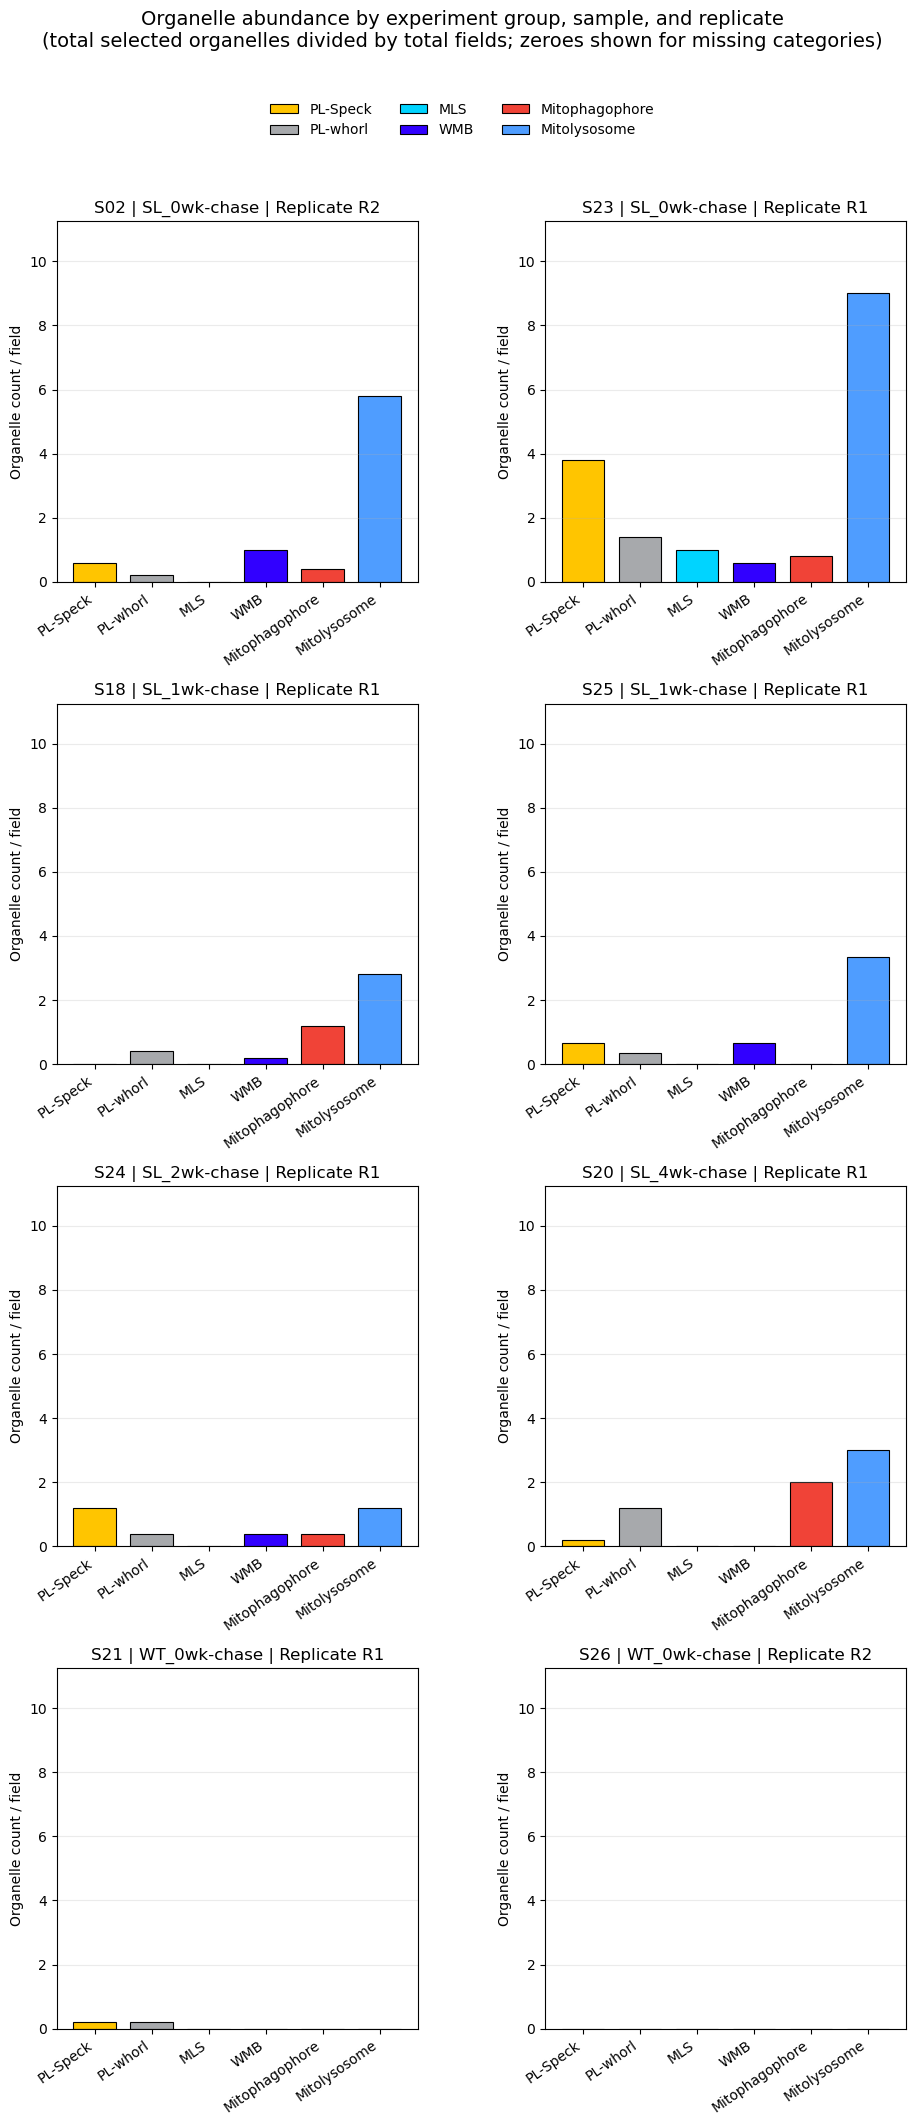


SL_summary_ML category medians:


,category,median_value,n_sample_replicates
0,PL-Speck,0.633333,6
1,PL-whorl,0.400000,6
2,MLS,0.000000,6
3,WMB,0.500000,6
4,Mitophagophore,0.600000,6
5,Mitolysosome,3.166667,6


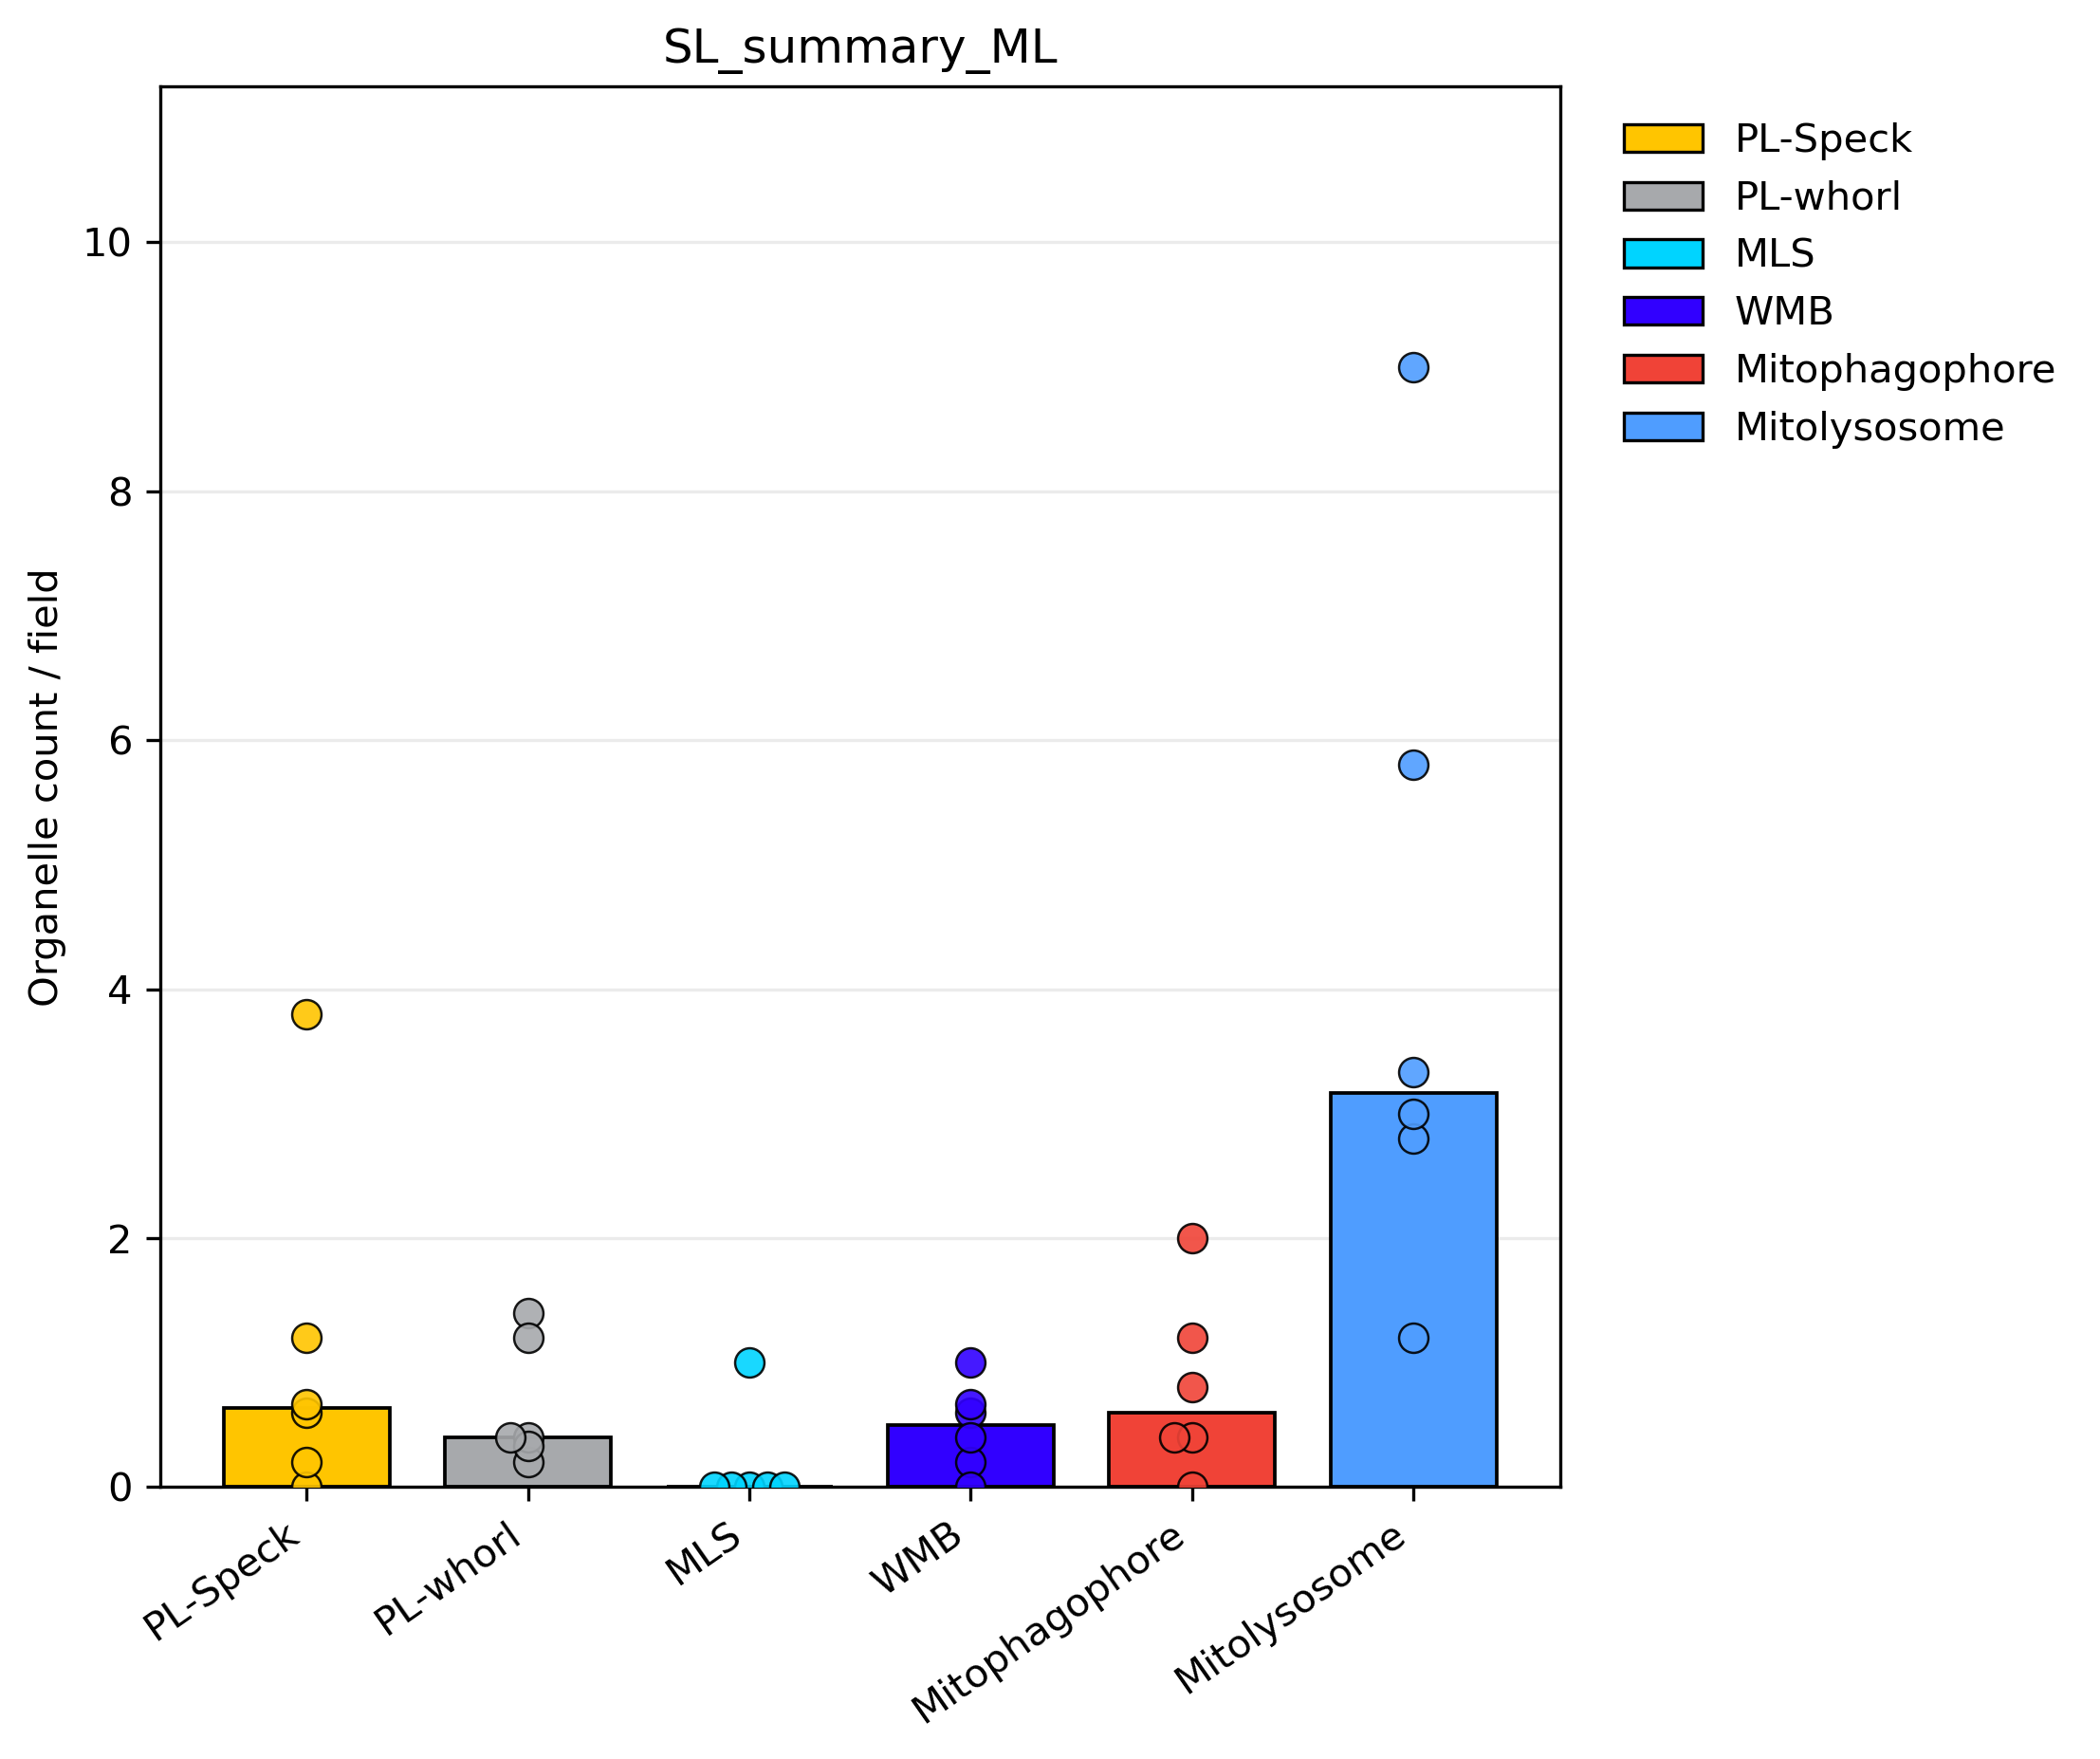


WT_summary_ML category medians:


,category,median_value,n_sample_replicates
0,PL-Speck,0.1,2
1,PL-whorl,0.1,2
2,MLS,0.0,2
3,WMB,0.0,2
4,Mitophagophore,0.0,2
5,Mitolysosome,0.0,2


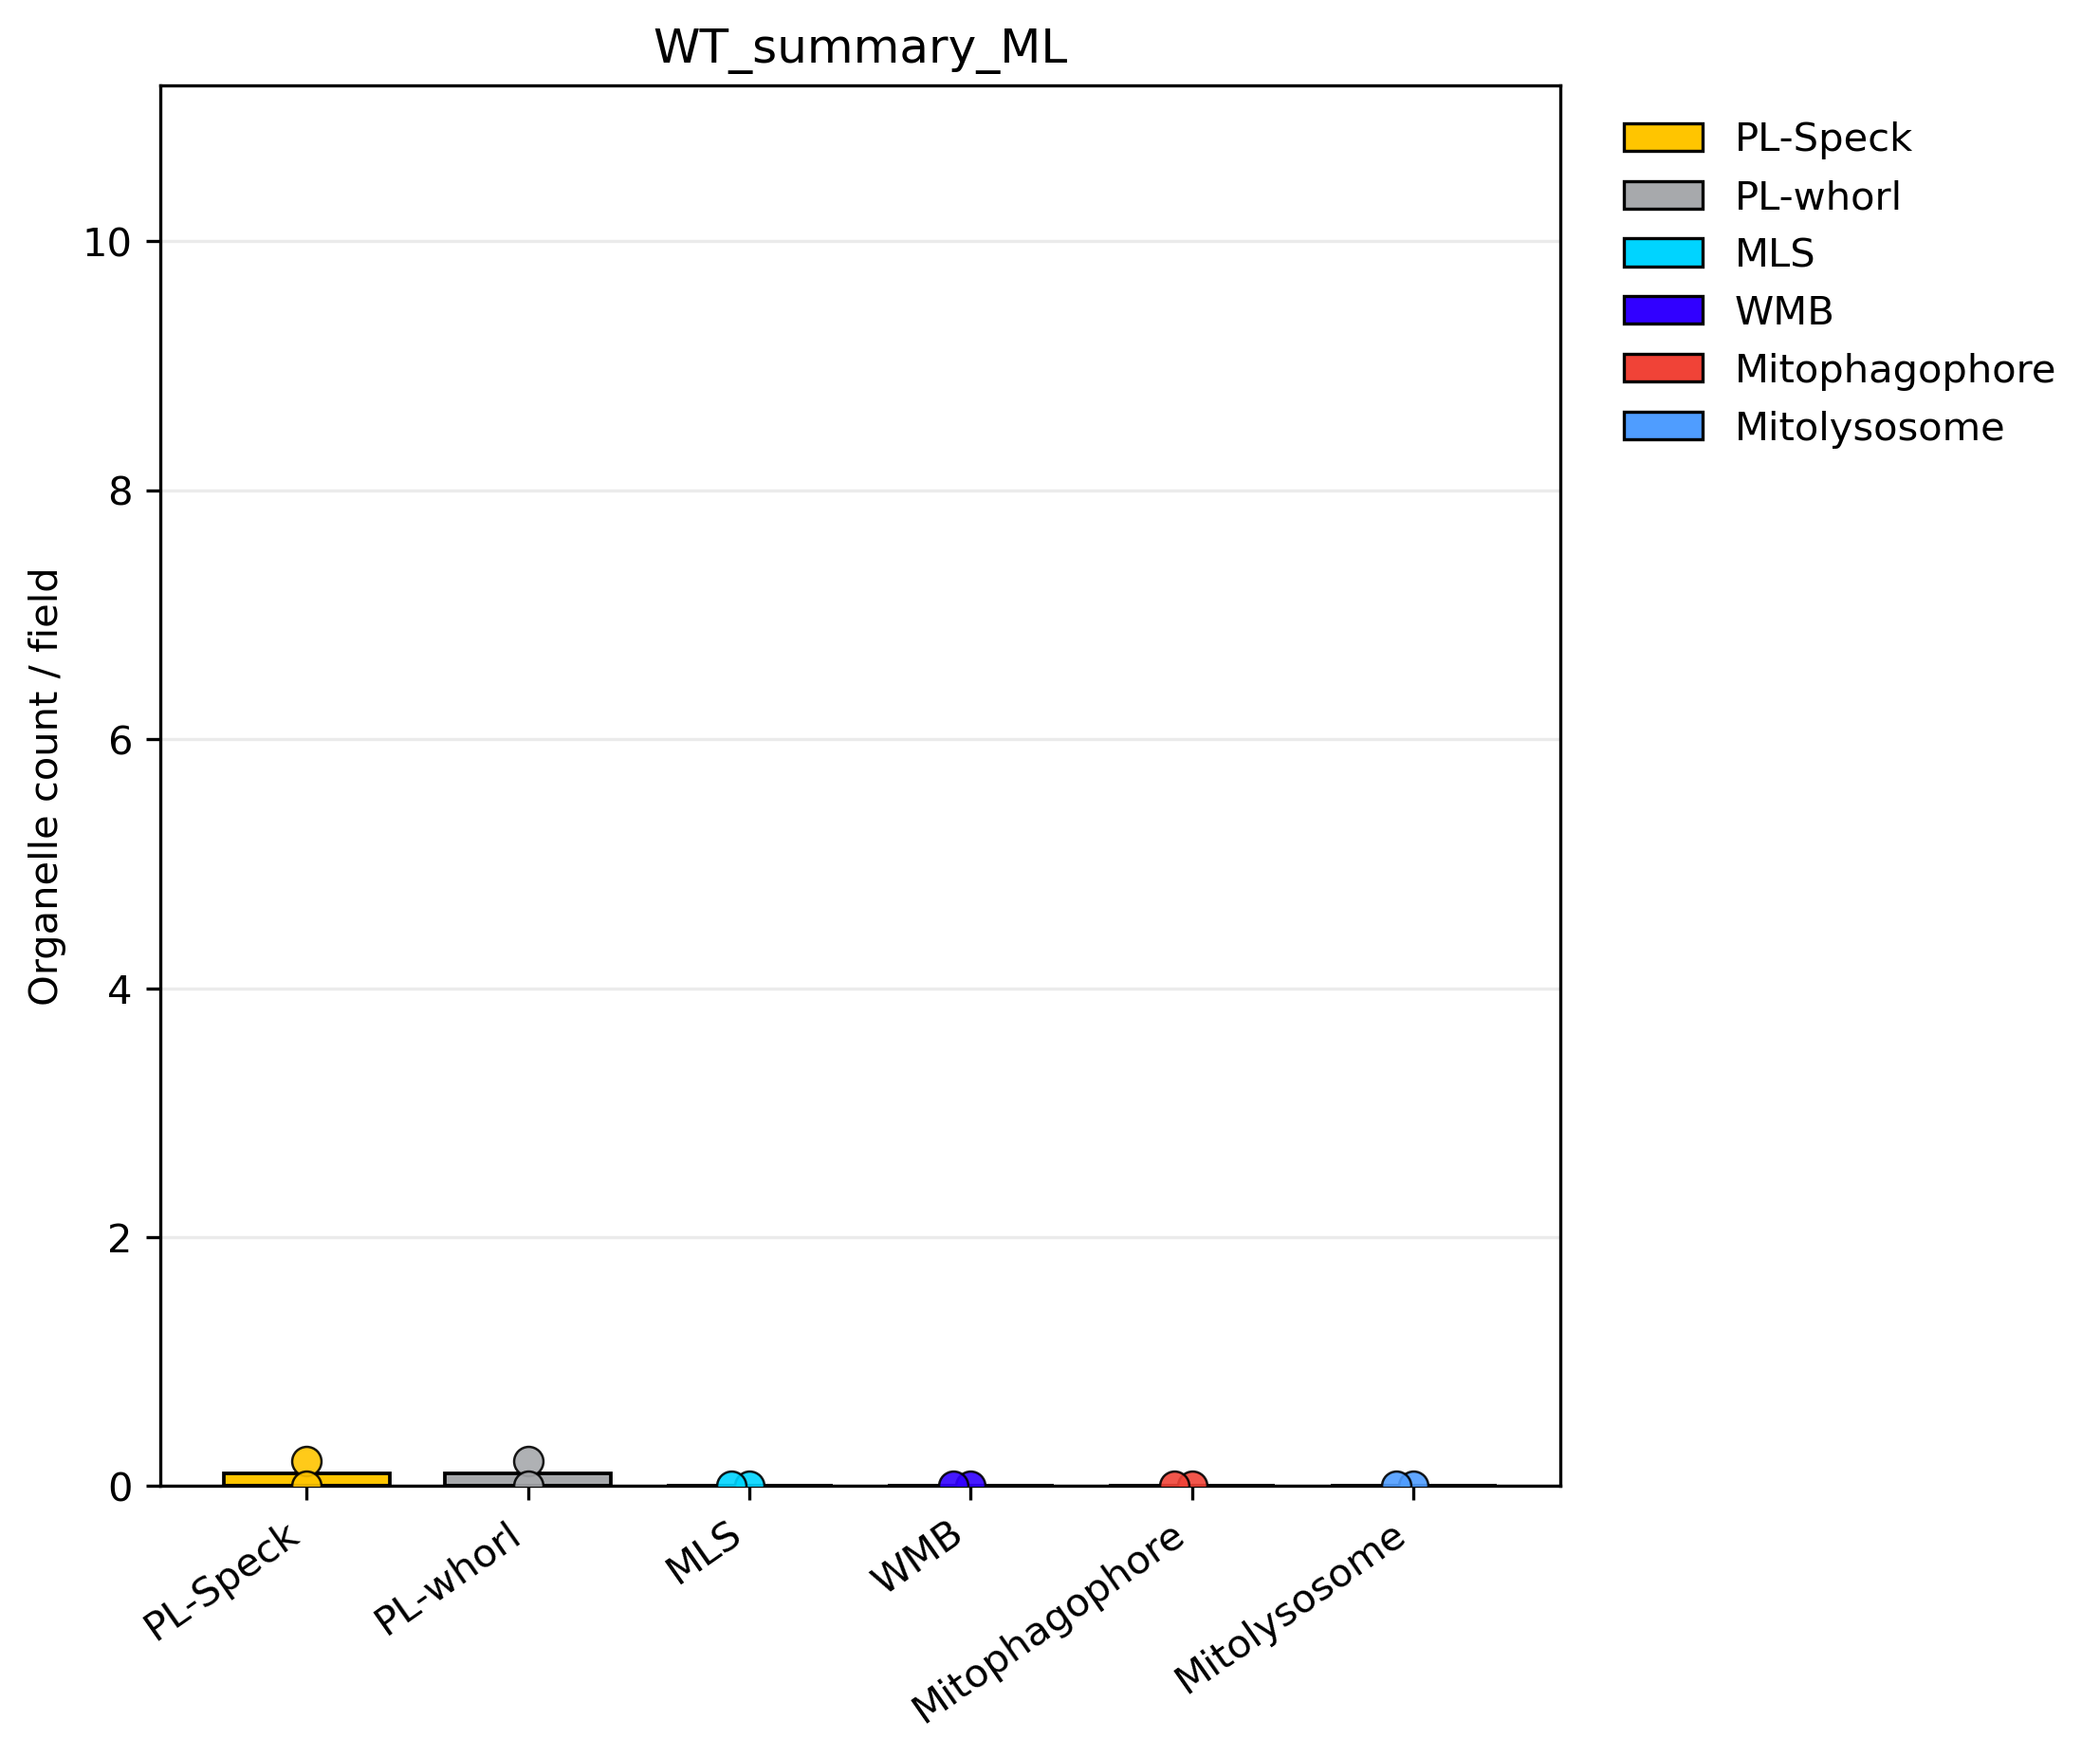

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.transparent": False,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# ============================================================
# Input
# ============================================================
# This tries both the original filename and the uploaded filename with (1).
candidate_paths = [
    Path("MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
    Path("MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
    Path("/mnt/data/MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
    Path("/mnt/data/MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
]

existing_paths = [p for p in candidate_paths if p.exists()]
if existing_paths:
    data_path = existing_paths[0]
else:
    matches = sorted(
        Path.cwd().glob(
            "MitoFLUXEM_2D_dataset_cleaned_annotations*.csv"
        )
    )
    if not matches:
        raise FileNotFoundError(
            "Could not find the CSV. Put it in the same folder as this notebook, "
            "or update data_path manually."
        )
    data_path = matches[0]

print(f"Reading: {data_path}")
df = pd.read_csv(data_path, low_memory=False).copy()

# ============================================================
# Column checks / standardization
# ============================================================
required = ["group_name", "replicate_number", "source_label_file"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df["experiment_group"] = df["group_name"].astype(str).str.strip()
df["replicate_number"] = df["replicate_number"].astype(str).str.strip()
df["source_label_lower"] = df["source_label_file"].astype(str).str.lower()

# Keep only the real experiment rows if your file includes miscellaneous rows.
df = df.loc[df["experiment_group"].str.contains("chase", case=False, na=False)].copy()

# Field ID column.
field_col = None
for candidate in ["field_id", "field_id_raw"]:
    if candidate in df.columns:
        field_col = candidate
        break

if field_col is None:
    raise KeyError("Neither 'field_id' nor 'field_id_raw' was found in the CSV.")

# ============================================================
# Explicit sample ID
# This is the important fix:
# S21 and S26 stay visible as separate samples.
# ============================================================
if "sample_name" in df.columns:
    df["sample_id"] = df["sample_name"].astype(str).str.strip()
elif "sample" in df.columns:
    df["sample_id"] = df["sample"].astype(str).str.strip()
else:
    df["sample_id"] = np.nan

bad_sample = df["sample_id"].isna() | df["sample_id"].str.lower().isin(["", "nan", "none"])

if bad_sample.any():
    extracted_from_field = (
        df.loc[bad_sample, field_col]
        .astype(str)
        .str.extract(r"(S\d+)", expand=False)
    )
    df.loc[bad_sample, "sample_id"] = extracted_from_field

bad_sample = df["sample_id"].isna() | df["sample_id"].str.lower().isin(["", "nan", "none"])

if bad_sample.any():
    extracted_from_source = (
        df.loc[bad_sample, "source_label_file"]
        .astype(str)
        .str.extract(r"(S\d+)", expand=False)
    )
    df.loc[bad_sample, "sample_id"] = extracted_from_source

bad_sample = df["sample_id"].isna() | df["sample_id"].str.lower().isin(["", "nan", "none"])

if bad_sample.any():
    display(
        df.loc[
            bad_sample,
            ["group_name", "replicate_number", field_col, "source_label_file"]
        ].head(20)
    )
    raise ValueError(
        "Some rows do not have a usable sample_id. "
        "Check sample_name/sample/field_id/source_label_file."
    )

# Keep a copy of all chase rows for denominators and raw object counts.
raw_df = df.copy()

# ============================================================
# Native relationship columns for Mitolysosome
# ============================================================
required_relationship_cols = ["is_main_mitolysosome"]
missing_rel = [c for c in required_relationship_cols if c not in df.columns]

if missing_rel:
    raise KeyError(
        f"Missing relationship columns required for Mitolysosome analysis: {missing_rel}"
    )

def parse_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    return str(x).strip().lower() in {"true", "t", "1", "yes", "y"}

df["is_main_mitolysosome"] = df["is_main_mitolysosome"].map(parse_bool)

# Optional content flag; if present, exclude all content rows from organelle classification.
if "is_mitolysosome_content" in df.columns:
    df["is_mitolysosome_content"] = df["is_mitolysosome_content"].map(parse_bool)
else:
    df["is_mitolysosome_content"] = False

# Optional mitophagophore flag if present.
if "_is_mitophagophore" in df.columns:
    df["_is_mitophagophore"] = df["_is_mitophagophore"].map(parse_bool)
else:
    df["_is_mitophagophore"] = False

# ============================================================
# Exclude all Mitolysosome content rows from category assignment
# ============================================================
df = df.loc[~df["is_mitolysosome_content"]].copy()

# ============================================================
# Category assignment
#   - Keep PL-Speck, PL-whorl, Mitophagophore, MLS, WMB, Mitolysosome
#   - Mitolysosome is a single category, no grades
#   - All content rows are excluded above
# ============================================================
def assign_category(row):
    s = row["source_label_lower"]

    if row["is_main_mitolysosome"]:
        return "Mitolysosome"

    # Mitophagophore: use explicit flag if present, then text fallback.
    if row["_is_mitophagophore"]:
        return "Mitophagophore"

    if (
        ("mitophagophore" in s)
        or ("mitophahophore" in s)
        or ("mitoph" in s and "phag" in s)
    ):
        return "Mitophagophore"

    # Direct label categories.
    if "pl-speck" in s:
        return "PL-Speck"

    if "pl-whorl" in s:
        return "PL-whorl"

    if "mls" in s:
        return "MLS"

    if "wmb" in s:
        return "WMB"

    return np.nan

df["category"] = df.apply(assign_category, axis=1)

# These are only the objects that match one of the selected organelle categories.
organelle_df = df.loc[df["category"].notna()].copy()

# ============================================================
# Category order and palette
# ============================================================
category_order = [
    "PL-Speck",
    "PL-whorl",
    "MLS",
    "WMB",
    "Mitophagophore",
    "Mitolysosome",
]

palette = {
    "PL-Speck": "#FFC500",        # Yellow
    "PL-whorl": "#A7A9AC",        # Gray
    "Mitophagophore": "#F04337",  # Red
    "MLS": "#00D4FF",             # Light blue
    "WMB": "#3100FF",             # Blue
    "Mitolysosome": "#4F9DFF",    # Blue for Mitolysosome
}

# ============================================================
# Correct normalization:
#   total selected organelles / total fields
#
# Important change:
#   Build from all samples first, then merge category counts.
#   This keeps zero-organelle samples such as S26 in the summary.
# ============================================================
id_cols = ["experiment_group", "sample_id", "replicate_number"]

field_counts = (
    raw_df.groupby(id_cols, dropna=False)
    .agg(
        n_fields=(field_col, "nunique"),
        total_raw_objects=("source_label_file", "size"),
    )
    .reset_index()
)

category_counts = (
    organelle_df.groupby(id_cols + ["category"], dropna=False)
    .size()
    .reset_index(name="total_count")
)

full_grid = (
    field_counts[id_cols]
    .drop_duplicates()
    .assign(_tmp=1)
    .merge(
        pd.DataFrame({"category": category_order, "_tmp": 1}),
        on="_tmp",
    )
    .drop(columns="_tmp")
)

summary = (
    full_grid.merge(
        category_counts,
        on=id_cols + ["category"],
        how="left",
    )
    .merge(
        field_counts,
        on=id_cols,
        how="left",
    )
)

summary["total_count"] = summary["total_count"].fillna(0).astype(int)

summary["count_per_field"] = np.where(
    summary["n_fields"].gt(0),
    summary["total_count"] / summary["n_fields"],
    np.nan,
)

# ============================================================
# Sample audit
# This confirms that S26 is counted as a sample even if it has
# zero selected organelle-category objects.
# ============================================================
sample_audit = field_counts.merge(
    organelle_df.groupby(id_cols, dropna=False)
    .size()
    .reset_index(name="selected_organelle_objects"),
    on=id_cols,
    how="left",
)

sample_audit["selected_organelle_objects"] = (
    sample_audit["selected_organelle_objects"]
    .fillna(0)
    .astype(int)
)

sample_audit["has_selected_organelle"] = sample_audit["selected_organelle_objects"].gt(0)

print("\nSample audit: raw objects are counted separately from selected organelle-category objects.")
display(sample_audit.sort_values(id_cols))

print("\nS21 and S26 audit check:")
display(
    sample_audit.loc[
        sample_audit["sample_id"].isin(["S21", "S26"])
    ].sort_values(id_cols)
)

print("\nNormalized abundance table:")
display(summary.sort_values(id_cols + ["category"]))

print("\nNormalized abundance table as text:")
print(
    summary[
        [
            "experiment_group",
            "sample_id",
            "replicate_number",
            "category",
            "total_count",
            "n_fields",
            "total_raw_objects",
            "count_per_field",
        ]
    ]
    .sort_values(id_cols + ["category"])
    .to_string(index=False)
)

# ============================================================
# Plot one panel per experiment_group / sample_id / replicate_number
# ============================================================
panel_df = (
    summary[id_cols]
    .drop_duplicates()
    .sort_values(id_cols)
)

panels = list(panel_df.itertuples(index=False, name=None))
n_panels = len(panels)

ncols = 2 if n_panels > 1 else 1
nrows = int(np.ceil(n_panels / ncols))
panel_size = 5.0

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(panel_size * ncols, panel_size * nrows),
    squeeze=False,
)

all_vals = summary["count_per_field"].to_numpy()
ymax = max(1.0, np.nanmax(all_vals) * 1.25) if len(all_vals) else 1.0

for ax, (group, sample_id, rep) in zip(axes.flat, panels):
    sub = summary[
        (summary["experiment_group"] == group)
        & (summary["sample_id"] == sample_id)
        & (summary["replicate_number"] == rep)
    ].copy()

    plot_series = (
        sub.set_index("category")["count_per_field"]
        .reindex(category_order, fill_value=0)
    )

    vals = plot_series.to_numpy()
    x = np.arange(len(category_order))

    ax.bar(
        x,
        vals,
        color=[palette[c] for c in category_order],
        edgecolor="black",
        linewidth=0.8,
        width=0.75,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(category_order, rotation=35, ha="right")
    ax.set_ylim(0, ymax)
    ax.set_ylabel("Organelle count / field")
    ax.set_title(f"{sample_id} | {group} | Replicate {rep}")
    ax.grid(axis="y", alpha=0.25)
    ax.set_box_aspect(1)

for ax in axes.flat[len(panels):]:
    ax.axis("off")

handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=palette[c],
        edgecolor="black",
        linewidth=0.8,
    )
    for c in category_order
]

fig.legend(
    handles,
    category_order,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Organelle abundance by experiment group, sample, and replicate\n"
    "(total selected organelles divided by total fields; zeroes shown for missing categories)",
    y=1.06,
    fontsize=14,
)

fig.tight_layout()
plt.show()

# ============================================================
# Summary figure helper
#   - each dot = one sample/replicate value
#   - bar = median across sample/replicate values
#   - no IQR/error bars
# ============================================================
def make_summary_figure(summary_df, group_label, title_text):
    group_df = summary_df[
        summary_df["experiment_group"].str.contains(group_label, case=False, na=False)
    ].copy()

    if group_df.empty:
        print(f"No {group_label} groups found.")
        return

    # Ensure every category exists in every sample/replicate panel.
    panel_keys = group_df[id_cols].drop_duplicates()

    full_grid = (
        panel_keys.assign(_tmp=1)
        .merge(
            pd.DataFrame({"category": category_order, "_tmp": 1}),
            on="_tmp",
        )
        .drop(columns="_tmp")
    )

    group_df = full_grid.merge(
        group_df[
            id_cols
            + [
                "category",
                "count_per_field",
            ]
        ],
        on=id_cols + ["category"],
        how="left",
    )

    group_df["count_per_field"] = group_df["count_per_field"].fillna(0)

    category_stats = (
        group_df.groupby("category", dropna=False)
        .agg(
            median_value=("count_per_field", "median"),
            n_sample_replicates=("count_per_field", "size"),
        )
        .reindex(category_order)
        .fillna({"median_value": 0, "n_sample_replicates": 0})
        .reset_index()
    )

    print(f"\n{title_text} category medians:")
    display(category_stats)

    fig, ax = plt.subplots(figsize=(7.5, 15), dpi=300)
    ax.set_box_aspect(1 / 1)

    def stagger_duplicates(values, center_x, step=0.08):
        """
        Spread duplicate y-values horizontally in a deterministic way:
        0, -step, +step, -2*step, +2*step, ...
        """
        values = np.asarray(values, dtype=float)
        x_positions = np.full(len(values), center_x, dtype=float)

        seen = {}
        for idx, v in enumerate(values):
            key = round(float(v), 6)
            n = seen.get(key, 0)

            if n == 0:
                offset = 0.0
            else:
                k = (n + 1) // 2
                offset = k * step * (-1 if n % 2 else 1)

            x_positions[idx] = center_x + offset
            seen[key] = n + 1

        return x_positions

    x = np.arange(len(category_order))

    for i, cat in enumerate(category_order):
        vals = group_df.loc[
            group_df["category"] == cat,
            "count_per_field",
        ].to_numpy()

        if len(vals):
            x_pos = stagger_duplicates(vals, i, step=0.08)

            ax.scatter(
                x_pos,
                vals,
                s=55,
                color=palette[cat],
                edgecolors="black",
                linewidths=0.6,
                alpha=0.9,
                zorder=3,
            )

        med = float(
            category_stats.loc[
                category_stats["category"] == cat,
                "median_value",
            ].iloc[0]
        )

        ax.bar(
            i,
            med,
            color=palette[cat],
            edgecolor="black",
            linewidth=0.9,
            width=0.75,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(category_order, rotation=35, ha="right")
    ax.set_ylabel("Organelle count / field")
    ax.set_title(title_text)
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", alpha=0.25)

    handles = [
        plt.Rectangle(
            (0, 0),
            2,
            1,
            facecolor=palette[c],
            edgecolor="black",
            linewidth=0.8,
        )
        for c in category_order
    ]

    ax.legend(
        handles,
        category_order,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
    )

    output_dir = Path("output_lysosome_analysis")
    output_dir.mkdir(parents=True, exist_ok=True)

    safe_title = title_text.replace("/", "-").replace(" ", "_")

    fig.tight_layout()
    plt.savefig(output_dir / f"{safe_title}.pdf")
    plt.show()

# ============================================================
# SL and WT summary figures
# ============================================================
make_summary_figure(
    summary,
    group_label="SL",
    title_text="SL_summary_ML",
)

make_summary_figure(
    summary,
    group_label="WT",
    title_text="WT_summary_ML",
)

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_group_norm"] = df[GROUP_COL].astype(str).str.replace("_", "-", regex=False).str.strip()
C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_is_s23"] = df["sample"].astype(str).str.startswith("S23")
C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:105: PerformanceWarning: DataFrame is highly fragmented.  This is usual

Reviewed rows per time point:
_group_norm
SL-0wk-chase    175
SL-1wk-chase     58
SL-2wk-chase     11
SL-4wk-chase     49
Name: count, dtype: int64

Mitochondria rows: 3958
Mitophagophore rows: 23
Mitoplasts rows: 24
PL-Speckled rows: 31
PL-whorl rows: 19
Mitolysosome rows: 282


C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\reviewed_morphology_score_panels.pdf


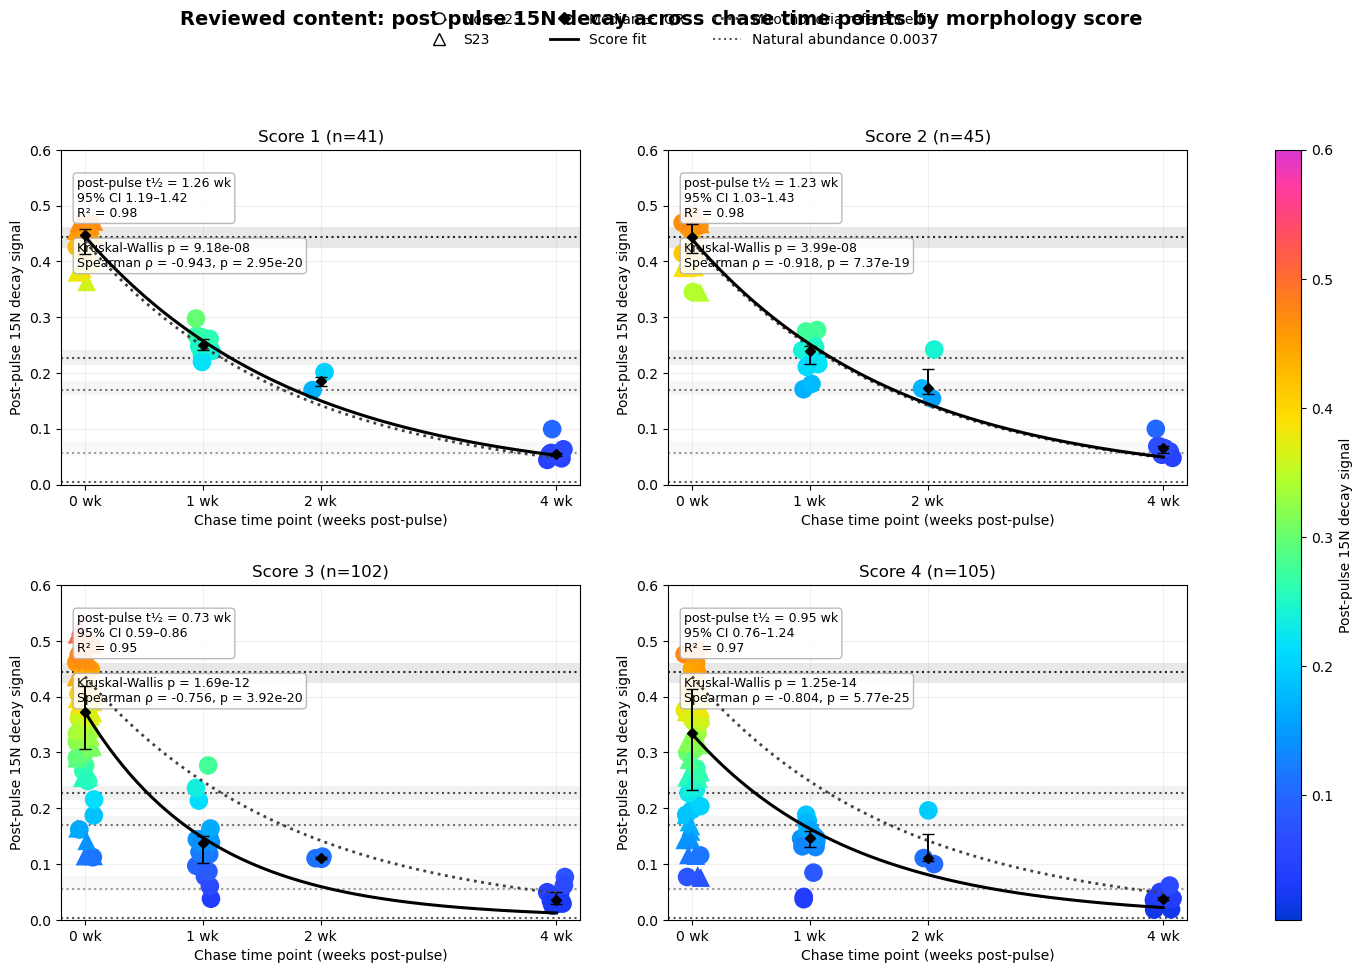


Post-pulse half-life estimates for reviewed morphology-score groups:
 score  post_pulse_t_half   ci_low  ci_high  boot_n
     1           1.258133 1.193466 1.424059    2000
     2           1.226868 1.029436 1.428409    2000
     3           0.733730 0.594623 0.864576    2000
     4           0.954275 0.762886 1.240299    2000

Pairwise post-pulse half-life comparisons among reviewed morphology scores:
         family  group_a  group_b  mean_diff_a_minus_b  diff_ci_low  diff_ci_high  p_boot  p_holm
reviewed_scores        1        2             0.068597    -0.171950      0.295044  0.5596  0.5596
reviewed_scores        1        3             0.563568     0.382552      0.754631  0.0000  0.0000
reviewed_scores        1        4             0.313419     0.024183      0.576424  0.0366  0.1464
reviewed_scores        2        3             0.496251     0.262507      0.748530  0.0000  0.0000
reviewed_scores        2        4             0.246102    -0.080629      0.553913  0.1250  0.2500
revie

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitochondria_post_pulse_decay.pdf


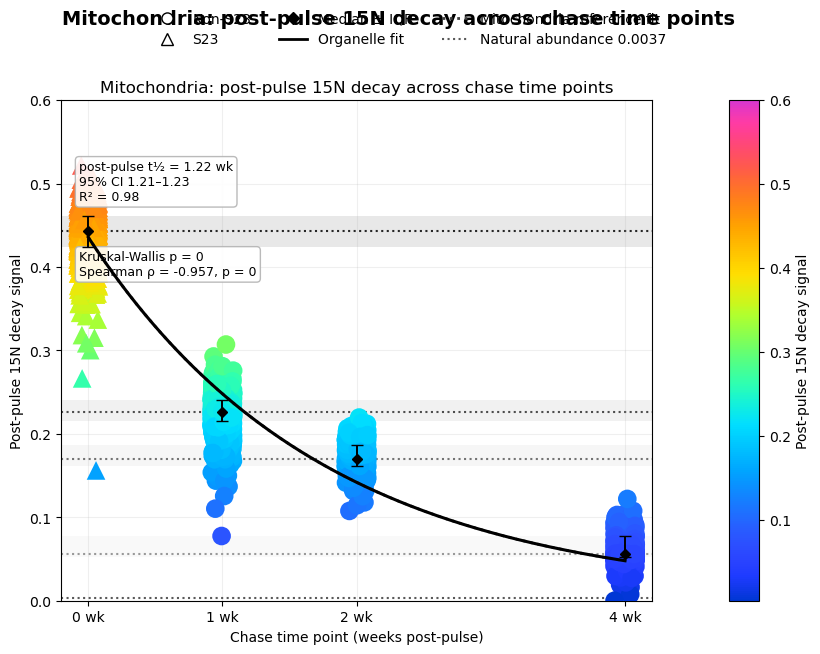

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitophagophore_post_pulse_decay.pdf


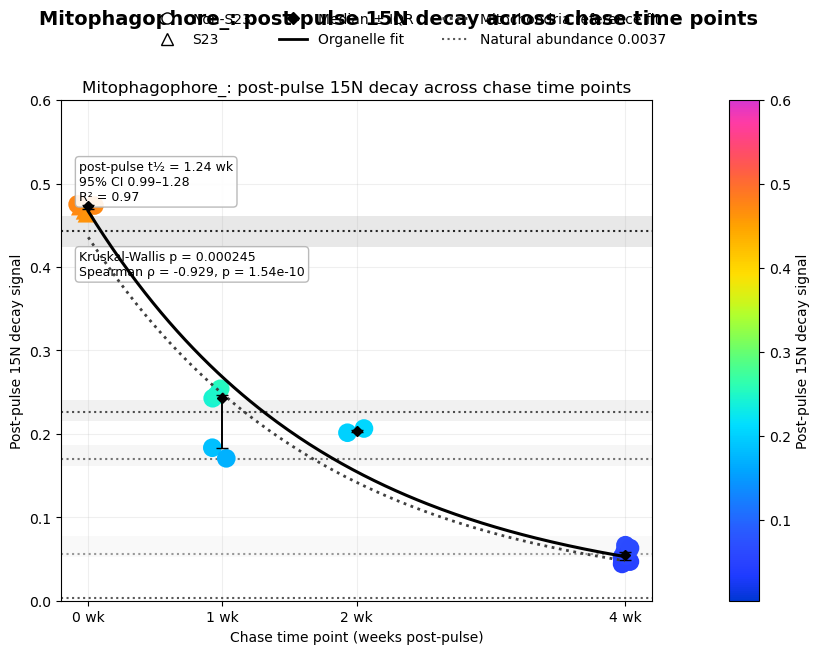

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitoplasts_post_pulse_decay.pdf


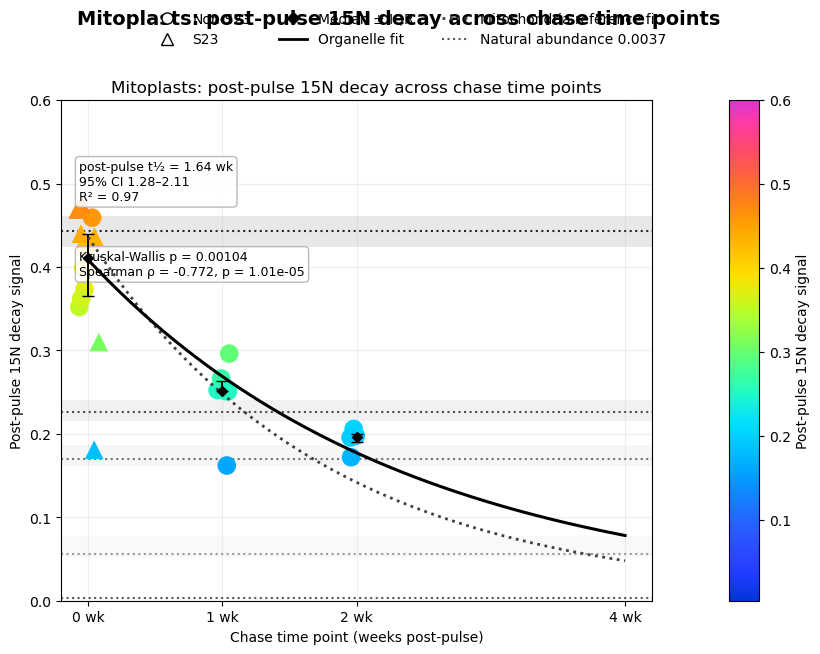


Mitoplasts 0, 1, 2 wk-only rows per time point:
_group_norm
SL-0wk-chase    14
SL-1wk-chase     6
SL-2wk-chase     4
Name: count, dtype: int64

Using full mitochondria reference fit, clipped visually to 0-2 wk:
  mitochondrial reference t1/2 = 1.216 wk


C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:1064: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitoplasts_post_pulse_decay_0_1_2wk.pdf


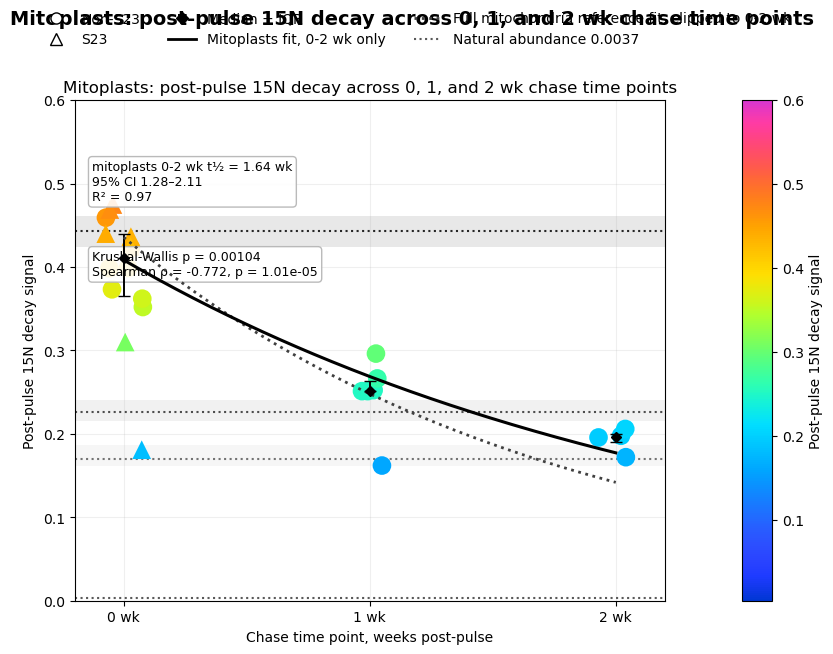

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\pl_speckled_post_pulse_decay.pdf


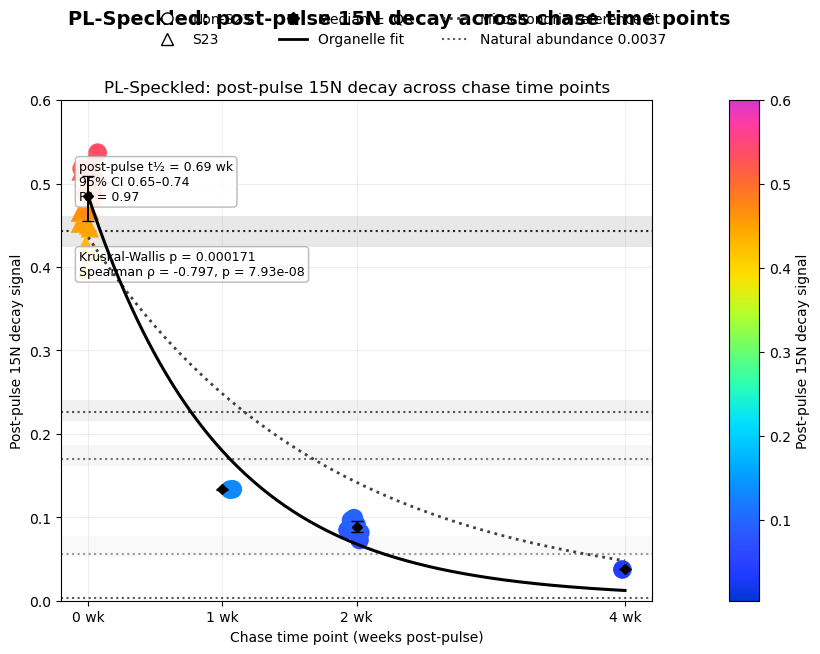

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\pl_whorl_post_pulse_decay.pdf


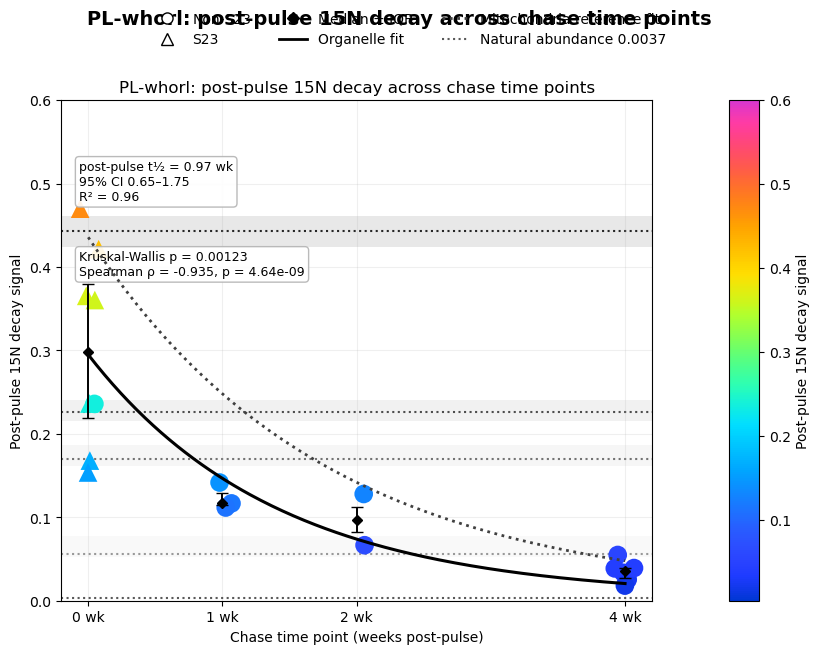

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitolysosome_scores_1-2.pdf


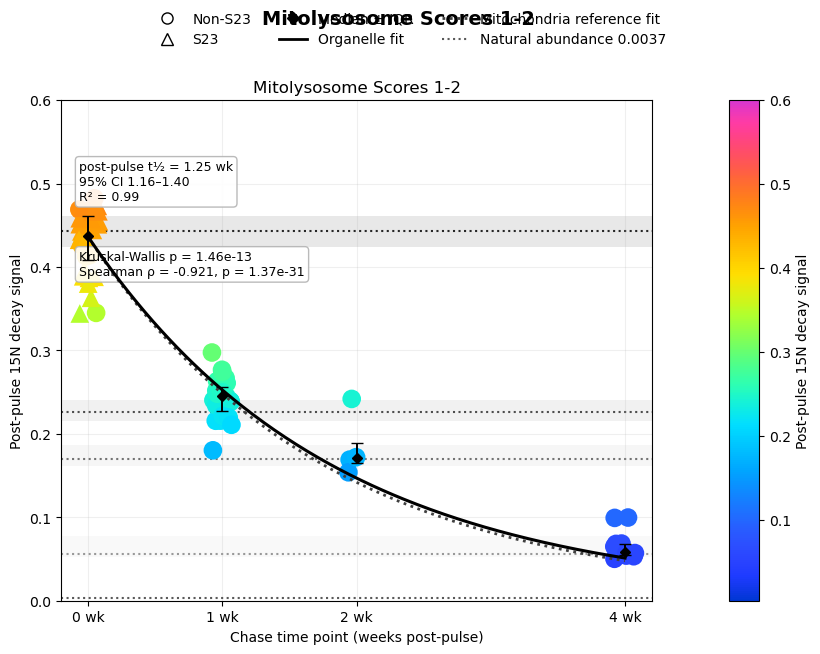

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\2314133592.py:601: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: output_lysosome_pulse_chase_analysis\mitolysosome_scores_3-4.pdf


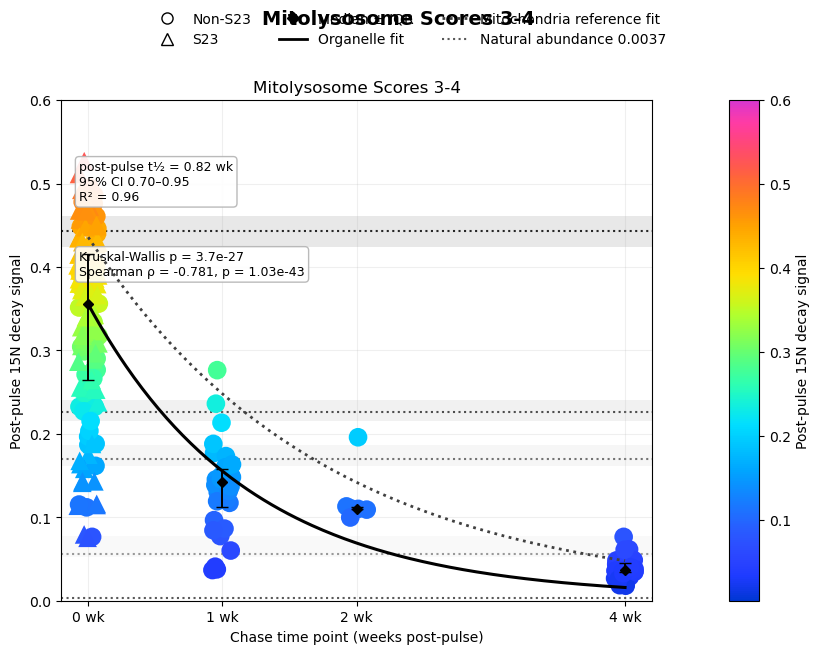


Post-pulse half-life estimates for mitolysosome grouped scores:
                  group  post_pulse_t_half   ci_low  ci_high  boot_n
Mitolysosome Scores 1-2           1.254932 1.161731 1.400525    2000
Mitolysosome Scores 3-4           0.824265 0.704781 0.949221    2000

Mitolysosome post-pulse half-life comparison:
                     family                 group_a                 group_b  mean_diff_a_minus_b  diff_ci_low  diff_ci_high  p_boot  p_holm
mitolysosome_grouped_scores Mitolysosome Scores 1-2 Mitolysosome Scores 3-4             0.447083       0.2776      0.623005     0.0     0.0

Mitochondria vs Mitophagophore post-pulse half-life comparison:
                family      group_a         group_b  mean_diff_a_minus_b  diff_ci_low  diff_ci_high  p_boot  p_holm
mito_vs_mitophagophore Mitochondria Mitophagophore_             0.035692    -0.065219      0.229856  0.7188  0.7188


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import Normalize
import matplotlib as mpl
from scipy.stats import kruskal, spearmanr
from scipy.optimize import curve_fit
from itertools import combinations
from matplotlib.lines import Line2D

# =============================
# Matplotlib / export settings
# =============================
# Keep text editable in Adobe Illustrator and preserve vector output.
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
})

# =============================
# File / columns
# =============================
CSV_PATH = Path("MitoFLUXEM_2D_dataset_cleaned_annotations.csv")
LUT_PATH = Path("LUT.csv")
OUTPUT_DIR = Path("output_lysosome_pulse_chase_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GROUP_COL = "group_name"
SCORE_COL = "content_morphology_score"
METRIC_COL = "strict_reduced_raw_fractional_15N_mean"

# =============================
# Experimental design
# =============================
# All samples: 2-week 15N pulse, then chase for 0, 1, 2, or 4 weeks.
# t = 0 corresponds to the end of the pulse.
TIME_ORDER = ["SL_0wk-chase", "SL_1wk-chase", "SL_2wk-chase", "SL_4wk-chase"]
TIME_ORDER_NORM = [t.replace("_", "-") for t in TIME_ORDER]
TIME_TO_X = {
    "SL_0wk-chase": 0.0,
    "SL_1wk-chase": 1.0,
    "SL_2wk-chase": 2.0,
    "SL_4wk-chase": 4.0,
}
TIME_TO_X_NORM = {k.replace("_", "-"): v for k, v in TIME_TO_X.items()}
TIME_TICKS = [0.0, 1.0, 2.0, 4.0]
TIME_TICK_LABELS = ["0 wk", "1 wk", "2 wk", "4 wk"]

SCORE_ORDER = [1, 2, 3, 4]

GLOBAL_VMIN = 0.0037
GLOBAL_VMAX = 0.6
Y_LIM = (0.0, GLOBAL_VMAX)
NATURAL_ABUNDANCE_15N = 0.0037

# =============================
# LUT loader
# =============================
def load_fiji_lut(path=LUT_PATH):
    try:
        df = pd.read_csv(path)
        cols = [c.strip().lower() for c in df.columns]

        if "red" in cols:
            r, g, b = cols.index("red"), cols.index("green"), cols.index("blue")
        elif "r" in cols:
            r, g, b = cols.index("r"), cols.index("g"), cols.index("b")
        else:
            r, g, b = 1, 2, 3

        rgb = df.iloc[:, [r, g, b]].to_numpy(dtype=float) / 255.0
        cmap = mpl.colors.ListedColormap(rgb)

        if hasattr(cmap, "with_extremes"):
            cmap = cmap.with_extremes(bad=(0, 0, 0, 0))

        return cmap
    except Exception as e:
        print(f"Could not load LUT.csv ({e}); falling back to viridis.")
        return plt.get_cmap("viridis")

CUSTOM_LUT = load_fiji_lut()
NORM_15N = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

# =============================
# Load / clean
# =============================
df = pd.read_csv(CSV_PATH, low_memory=False)

rated_status = df["content_morphology_status"].astype(str).str.strip().str.lower().eq("rated")
rated_true = df["content_morphology_rated"].astype(str).str.strip().str.lower().isin(["true", "1", "yes"])
reviewed_mask = rated_status | rated_true

df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")
df[METRIC_COL] = pd.to_numeric(df[METRIC_COL], errors="coerce")
df["_group_norm"] = df[GROUP_COL].astype(str).str.replace("_", "-", regex=False).str.strip()
df["_is_s23"] = df["sample"].astype(str).str.startswith("S23")

# Source-label-based classes
df["_is_mito"] = df["source_label_file"].astype(str).str.contains("Mitochondria", case=False, na=False)
df["_is_mitophagophore"] = df["source_label_file"].astype(str).str.contains("Mitophagophore", case=False, na=False)
df["_is_mitolysosome"] = df["source_label_file"].astype(str).str.contains("Mitolysosome", case=False, na=False)
df["_is_mitoplasts"] = df["source_label_file"].astype(str).str.contains("Mitoplast", case=False, na=False)
df["_is_pl_speckled"] = df["source_label_file"].astype(str).str.contains("PL-Speckled", case=False, na=False)
df["_is_pl_whorl"] = df["source_label_file"].astype(str).str.contains("PL-whorl", case=False, na=False)

df = df.dropna(subset=[METRIC_COL, "_group_norm"]).copy()
df = df[df["_group_norm"].isin(TIME_ORDER_NORM)].copy()

# Reviewed rows for morphology-score panels
df_reviewed = df.loc[reviewed_mask & df[SCORE_COL].isin(SCORE_ORDER)].copy()

# Source-label-based classes do not require reviewed=True
df_mito = df.loc[df["_is_mito"]].copy()
df_mitophagophore = df.loc[df["_is_mitophagophore"]].copy()
df_mitoplasts = df.loc[df["_is_mitoplasts"]].copy()
df_pl_speckled = df.loc[df["_is_pl_speckled"]].copy()
df_pl_whorl = df.loc[df["_is_pl_whorl"]].copy()
df_mitolysosome = df.loc[df["_is_mitolysosome"] & df[SCORE_COL].isin(SCORE_ORDER)].copy()

print("Reviewed rows per time point:")
print(df_reviewed["_group_norm"].value_counts().reindex(TIME_ORDER_NORM).fillna(0).astype(int))
print("\nMitochondria rows:", len(df_mito))
print("Mitophagophore rows:", len(df_mitophagophore))
print("Mitoplasts rows:", len(df_mitoplasts))
print("PL-Speckled rows:", len(df_pl_speckled))
print("PL-whorl rows:", len(df_pl_whorl))
print("Mitolysosome rows:", len(df_mitolysosome))

# =============================
# Decay model helpers
# =============================
def exp_decay_excess(t, A, k):
    return A * np.exp(-k * t)


def fit_decay_points(x, y, weights=None, floor=NATURAL_ABUNDANCE_15N):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 3 or len(y) < 3:
        return None

    # Fit only the signal above natural abundance.
    y_excess = np.clip(y - floor, 0.0, None)

    A0 = max(float(np.max(y_excess) - np.min(y_excess)), 1e-6)
    k0 = 0.5

    sigma = None
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        sigma = 1.0 / np.sqrt(np.maximum(weights, 1.0))

    try:
        popt, pcov = curve_fit(
            exp_decay_excess,
            x,
            y_excess,
            p0=[A0, k0],
            bounds=([0.0, 0.0], [np.inf, np.inf]),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=20000,
        )
        A, k = popt
        yhat = exp_decay_excess(x, *popt) + floor
        ss_res = float(np.sum((y - yhat) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        r2 = np.nan if ss_tot <= 0 else 1.0 - (ss_res / ss_tot)
        half_life = np.log(2) / k if k > 0 else np.nan

        return {
            "A": A,
            "k": k,
            "C": floor,
            "half_life": half_life,
            "r2": r2,
            "yhat": yhat,
            "pcov": pcov,
        }
    except Exception:
        return None


def summarize_by_timepoint(sub):
    rows = []
    for tp in TIME_ORDER_NORM:
        vals = sub.loc[sub["_group_norm"] == tp, METRIC_COL].dropna().to_numpy()
        if len(vals) == 0:
            continue
        rows.append({
            "timepoint": tp,
            "x": TIME_TO_X_NORM[tp],
            "median": np.median(vals),
            "q1": np.percentile(vals, 25),
            "q3": np.percentile(vals, 75),
            "n": len(vals),
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["timepoint"] = pd.Categorical(out["timepoint"], categories=TIME_ORDER_NORM, ordered=True)
        out = out.sort_values("timepoint")
    return out


def fit_decay_to_subgroup(sub):
    summary = summarize_by_timepoint(sub)
    if summary.empty or len(summary) < 3:
        return None

    x = summary["x"].to_numpy(dtype=float)
    y = summary["median"].to_numpy(dtype=float)
    weights = summary["n"].to_numpy(dtype=float)
    return fit_decay_points(x, y, weights=weights)


def bootstrap_half_life(sub, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)

    group_arrays = {}
    for tp in TIME_ORDER_NORM:
        arr = sub.loc[sub["_group_norm"] == tp, METRIC_COL].dropna().to_numpy()
        if len(arr) > 0:
            group_arrays[tp] = arr

    if len(group_arrays) < 3:
        return np.array([])

    boot_t12 = []
    for _ in range(n_boot):
        xs = []
        ys = []
        ws = []
        for tp in TIME_ORDER_NORM:
            arr = group_arrays.get(tp, None)
            if arr is None or len(arr) == 0:
                continue
            samp = rng.choice(arr, size=len(arr), replace=True)
            xs.append(TIME_TO_X_NORM[tp])
            ys.append(np.median(samp))
            ws.append(len(samp))

        if len(xs) < 3:
            continue

        fit = fit_decay_points(np.array(xs), np.array(ys), weights=np.array(ws))
        if fit is not None and np.isfinite(fit["half_life"]):
            boot_t12.append(fit["half_life"])

    return np.array(boot_t12, dtype=float)


def bootstrap_t12_summary(sub, n_boot=2000, seed=0):
    fit = fit_decay_to_subgroup(sub)
    boot = bootstrap_half_life(sub, n_boot=n_boot, seed=seed)

    out = {
        "fit": fit,
        "boot": boot,
        "half_life": np.nan,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "boot_n": len(boot),
    }

    if fit is not None:
        out["half_life"] = fit["half_life"]

    if len(boot) > 10:
        out["ci_low"] = np.percentile(boot, 2.5)
        out["ci_high"] = np.percentile(boot, 97.5)

    return out


def bootstrap_compare_halflife(dist_a, dist_b, n_draw=10000, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(dist_a, dtype=float)
    b = np.asarray(dist_b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) < 10 or len(b) < 10:
        return {
            "p": np.nan,
            "diff_low": np.nan,
            "diff_high": np.nan,
            "mean_diff": np.nan,
            "n_a": len(a),
            "n_b": len(b),
        }

    draws_a = rng.choice(a, size=n_draw, replace=True)
    draws_b = rng.choice(b, size=n_draw, replace=True)
    diff = draws_a - draws_b

    p = 2.0 * min(np.mean(diff <= 0), np.mean(diff >= 0))
    p = min(p, 1.0)

    return {
        "p": p,
        "diff_low": np.percentile(diff, 2.5),
        "diff_high": np.percentile(diff, 97.5),
        "mean_diff": float(np.mean(diff)),
        "n_a": len(a),
        "n_b": len(b),
    }


def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return adj

    order = idx[np.argsort(pvals[valid])]
    m = len(order)
    running_max = 0.0

    for rank, i in enumerate(order):
        raw = pvals[i] * (m - rank)
        running_max = max(running_max, raw)
        adj[i] = min(running_max, 1.0)

    return adj

# =============================
# Plot / save helpers
# =============================
def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in text).strip("_")


def save_figure_pdf(fig, filename):
    out_path = OUTPUT_DIR / filename
    fig.savefig(
        out_path,
        format="pdf",
        bbox_inches="tight",
        transparent=False,
        facecolor="white",
        edgecolor="none",
    )
    print(f"Saved: {out_path}")


def compute_reference_iqr(sub):
    ref = summarize_by_timepoint(sub)
    if ref.empty:
        return ref
    return ref[["timepoint", "x", "median", "q1", "q3"]].copy()


mito_iqr_ref = compute_reference_iqr(df_mito)
mito_fit_ref = bootstrap_t12_summary(df_mito, n_boot=2000, seed=0)



def add_mito_reference(ax, ref):
    """
    Draw full-width mitochondria IQR bands and dotted median lines.
    Earlier timepoints = darker gray, later = lighter gray.
    """
    if ref is None or ref.empty:
        return

    gray_shades = [
        (0.15, 0.15, 0.15, 0.10),  # 0 wk
        (0.30, 0.30, 0.30, 0.08),  # 1 wk
        (0.45, 0.45, 0.45, 0.06),  # 2 wk
        (0.60, 0.60, 0.60, 0.05),  # 4 wk
    ]

    for i, tp in enumerate(TIME_ORDER_NORM):
        row = ref.loc[ref["timepoint"] == tp]
        if row.empty:
            continue

        q1 = float(row["q1"].iloc[0])
        q3 = float(row["q3"].iloc[0])
        median = float(row["median"].iloc[0])

        ax.axhspan(
            q1,
            q3,
            facecolor=gray_shades[i],
            edgecolor="none",
            zorder=0,
        )
        ax.axhline(
            median,
            color=gray_shades[i][:3],
            linestyle=":",
            linewidth=1.5,
            zorder=1,
        )


def add_natural_abundance_line(ax, y=NATURAL_ABUNDANCE_15N):
    ax.axhline(
        y,
        color="0.35",
        linestyle=":",
        linewidth=1.5,
        zorder=2,
    )


def annotate_fit(ax, fit_info, label="t½"):
    if fit_info is None or fit_info.get("fit") is None:
        ax.text(
            0.03, 0.80, "Decay fit failed",
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
        )
        return

    fit = fit_info["fit"]
    t12 = fit["half_life"]
    r2 = fit["r2"]

    if np.isfinite(fit_info["ci_low"]) and np.isfinite(fit_info["ci_high"]):
        txt = f"{label} = {t12:.2f} wk\n95% CI {fit_info['ci_low']:.2f}–{fit_info['ci_high']:.2f}\nR² = {r2:.2f}"
    else:
        txt = f"{label} = {t12:.2f} wk\nR² = {r2:.2f}"

    ax.text(
        0.03, 0.80, txt,
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
    )


def add_decay_curve(ax, fit, color="black", linestyle="-", linewidth=2.2, zorder=6):
    if fit is None or fit.get("fit") is None:
        return
    params = fit["fit"]
    x_fit = np.linspace(0, 4, 200)
    y_fit = exp_decay_excess(x_fit, params["A"], params["k"]) + NATURAL_ABUNDANCE_15N
    ax.plot(x_fit, y_fit, linestyle=linestyle, color=color, linewidth=linewidth, zorder=zorder)


def add_timepoint_scatter(ax, sub):
    for tp in TIME_ORDER_NORM:
        tp_df = sub[sub["_group_norm"] == tp]
        if tp_df.empty:
            continue

        x0 = TIME_TO_X_NORM[tp]

        for mask, marker in [
            (~tp_df["_is_s23"], "o"),
            (tp_df["_is_s23"], "^"),
        ]:
            tmp = tp_df.loc[mask]
            if tmp.empty:
                continue

            x = (
                np.full(len(tmp), x0, dtype=float)
                + np.random.uniform(-0.08, 0.08, size=len(tmp))
            )

            ax.scatter(
                x,
                tmp[METRIC_COL],
                c=tmp[METRIC_COL],
                cmap=CUSTOM_LUT,
                norm=NORM_15N,
                s=180,
                marker=marker,
                alpha=1.0,
                edgecolors="none",
                linewidths=0,
                zorder=3,
            )

def add_summary_and_stats(ax, sub, y_anchor=0.65):
    summary = summarize_by_timepoint(sub)
    if not summary.empty:
        ax.errorbar(
            summary["x"].to_numpy(),
            summary["median"].to_numpy(),
            yerr=np.vstack([
                summary["median"].to_numpy() - summary["q1"].to_numpy(),
                summary["q3"].to_numpy() - summary["median"].to_numpy(),
            ]),
            fmt="D",
            linestyle="none",
            color="black",
            ecolor="black",
            elinewidth=1.4,
            capsize=4,
            markersize=4.8,
            zorder=5,
        )

    groups = []
    trend_x = []
    trend_y = []

    for tp in TIME_ORDER_NORM:
        vals = sub.loc[sub["_group_norm"] == tp, METRIC_COL].dropna().to_numpy()
        if len(vals) >= 2:
            groups.append(vals)
        if len(vals) > 0:
            trend_x.extend([TIME_TO_X_NORM[tp]] * len(vals))
            trend_y.extend(vals.tolist())

    kw_p = np.nan
    sp_rho = np.nan
    sp_p = np.nan

    if len(groups) >= 2:
        try:
            kw_p = kruskal(*groups).pvalue
        except Exception:
            pass

    if len(trend_x) >= 3:
        try:
            sp = spearmanr(trend_x, trend_y, nan_policy="omit")
            sp_rho = sp.correlation
            sp_p = sp.pvalue
        except Exception:
            pass

    ax.text(
        0.03, y_anchor,
        f"Kruskal-Wallis p = {kw_p:.3g}\nSpearman ρ = {sp_rho:.3f}, p = {sp_p:.3g}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
    )


def make_timepoint_figure(sub, title, save_name, ylabel="Post-pulse 15N decay signal", return_fit=False):
    sub = sub.copy()
    if sub.empty:
        print(f"No data for: {title}")
        return None

    fit_info = bootstrap_t12_summary(sub, n_boot=2000, seed=0)

    fig = plt.figure(figsize=(9, 6.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.05], wspace=0.25)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.set_ylim(*Y_LIM)
    ax.set_xlim(-0.2, 4.2)
    
    add_mito_reference(ax, mito_iqr_ref)
    add_natural_abundance_line(ax)

    add_timepoint_scatter(ax, sub)
    add_summary_and_stats(ax, sub, y_anchor=0.65)

    # Solid line: fit for the graphed organelle/group.
    add_decay_curve(ax, fit_info, color="black", linestyle="-", linewidth=2.2, zorder=6)

    # Dotted line: mitochondria reference fit.
    add_decay_curve(ax, mito_fit_ref, color="0.25", linestyle=":", linewidth=2.0, zorder=5)

    annotate_fit(ax, fit_info, label="post-pulse t½")

    ax.set_title(title)
    ax.set_xlabel("Chase time point (weeks post-pulse)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(TIME_TICKS)
    ax.set_xticklabels(TIME_TICK_LABELS)
    ax.grid(True, alpha=0.2)

    sm = mpl.cm.ScalarMappable(norm=NORM_15N, cmap=CUSTOM_LUT)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Post-pulse 15N decay signal")

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
               markeredgecolor="black", markersize=8, label="Non-S23"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="white",
               markeredgecolor="black", markersize=8, label="S23"),
        Line2D([0], [0], marker="D", color="black", markersize=6, linestyle="none",
               label="Median ± IQR"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Organelle fit"),
        Line2D([0], [0], color="0.25", linestyle=":", linewidth=2, label="Mitochondria reference fit"),
        Line2D([0], [0], color="0.35", linestyle=":", linewidth=1.5, label="Natural abundance 0.0037"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False)
    fig.suptitle(title, y=1.02, fontsize=14, weight="bold")
    plt.tight_layout()

    save_figure_pdf(fig, f"{safe_filename(save_name)}.pdf")
    plt.show()

    return fit_info if return_fit else None


def plot_reviewed_score_panels(sub, save_name="reviewed_morphology_score_panels"):
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05], wspace=0.25, hspace=0.30)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
    ]
    cax = fig.add_subplot(gs[:, 2])

    fit_map = {}

    for ax, score in zip(axes, SCORE_ORDER):
        s = sub[sub[SCORE_COL] == score].copy()

        if s.empty:
            ax.set_axis_off()
            ax.set_title(f"Score {score}\n(no data)")
            fit_map[score] = None
            continue

        fit_info = bootstrap_t12_summary(s, n_boot=2000, seed=score)
        fit_map[score] = fit_info

        ax.set_ylim(*Y_LIM)
        ax.set_xlim(-0.2, 4.2)
        add_mito_reference(ax, mito_iqr_ref)
        add_natural_abundance_line(ax)

        add_timepoint_scatter(ax, s)
        add_summary_and_stats(ax, s, y_anchor=0.65)

        # Solid line: score-specific fit.
        add_decay_curve(ax, fit_info, color="black", linestyle="-", linewidth=2.2, zorder=6)

        # Dotted line: mitochondria reference fit.
        add_decay_curve(ax, mito_fit_ref, color="0.25", linestyle=":", linewidth=2.0, zorder=5)

        annotate_fit(ax, fit_info, label="post-pulse t½")

        ax.set_title(f"Score {score} (n={len(s)})")
        ax.set_xlabel("Chase time point (weeks post-pulse)")
        ax.set_ylabel("Post-pulse 15N decay signal")
        ax.set_xticks(TIME_TICKS)
        ax.set_xticklabels(TIME_TICK_LABELS)
        ax.grid(True, alpha=0.2)

    sm = mpl.cm.ScalarMappable(norm=NORM_15N, cmap=CUSTOM_LUT)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Post-pulse 15N decay signal")

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
               markeredgecolor="black", markersize=8, label="Non-S23"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="white",
               markeredgecolor="black", markersize=8, label="S23"),
        Line2D([0], [0], marker="D", color="black", markersize=6, linestyle="none",
               label="Median ± IQR"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Score fit"),
        Line2D([0], [0], color="0.25", linestyle=":", linewidth=2, label="Mitochondria reference fit"),
        Line2D([0], [0], color="0.35", linestyle=":", linewidth=1.5, label="Natural abundance 0.0037"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False)
    fig.suptitle(
        "Reviewed content: post-pulse 15N decay across chase time points by morphology score",
        y=1.02, fontsize=14, weight="bold"
    )
    plt.tight_layout()

    save_figure_pdf(fig, f"{safe_filename(save_name)}.pdf")
    plt.show()

    return fit_map


def compare_fit_maps(fit_map, family_name, pairs=None):
    labels = list(fit_map.keys())
    if pairs is None:
        pairs = list(combinations(labels, 2))

    rows = []
    for a, b in pairs:
        fa = fit_map.get(a, None)
        fb = fit_map.get(b, None)
        dist_a = fa["boot"] if fa is not None else np.array([])
        dist_b = fb["boot"] if fb is not None else np.array([])

        comp = bootstrap_compare_halflife(dist_a, dist_b, n_draw=10000, seed=0)
        rows.append({
            "family": family_name,
            "group_a": a,
            "group_b": b,
            "mean_diff_a_minus_b": comp["mean_diff"],
            "diff_ci_low": comp["diff_low"],
            "diff_ci_high": comp["diff_high"],
            "p_boot": comp["p"],
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_holm"] = holm_adjust(out["p_boot"].to_numpy())
    return out

# =============================
# Main reviewed morphology-score figure
# =============================
reviewed_fit_map = plot_reviewed_score_panels(df_reviewed)
print("\nPost-pulse half-life estimates for reviewed morphology-score groups:")
reviewed_summary = []
for score in SCORE_ORDER:
    info = reviewed_fit_map.get(score)
    reviewed_summary.append({
        "score": score,
        "post_pulse_t_half": np.nan if info is None or info["fit"] is None else info["fit"]["half_life"],
        "ci_low": np.nan if info is None else info["ci_low"],
        "ci_high": np.nan if info is None else info["ci_high"],
        "boot_n": 0 if info is None else info["boot_n"],
    })
print(pd.DataFrame(reviewed_summary).to_string(index=False))

print("\nPairwise post-pulse half-life comparisons among reviewed morphology scores:")
print(compare_fit_maps(reviewed_fit_map, "reviewed_scores").to_string(index=False))

# =============================
# Mitochondria figure
# =============================
mito_fit = make_timepoint_figure(
    df_mito,
    "Mitochondria: post-pulse 15N decay across chase time points",
    save_name="mitochondria_post_pulse_decay",
    return_fit=True,
)

# =============================
# Mitophagophore figure
# =============================
mitophagophore_fit = make_timepoint_figure(
    df_mitophagophore,
    "Mitophagophore_: post-pulse 15N decay across chase time points",
    save_name="mitophagophore_post_pulse_decay",
    return_fit=True,
)

# =============================
# Mitoplasts figure
# =============================
mitoplasts_fit = make_timepoint_figure(
    df_mitoplasts,
    "Mitoplasts: post-pulse 15N decay across chase time points",
    save_name="mitoplasts_post_pulse_decay",
    return_fit=True,
)


# =============================
# Mitoplasts figure: 0, 1, 2 wk only
# =============================
# Important:
# - The mitoplasts fit is calculated using only 0, 1, and 2 wk mitoplast data.
# - The mitochondria reference fit is NOT recalculated.
# - The mitochondria reference trendline uses mito_fit_ref, which was already
#   calculated from the full df_mito dataset.
# - The mitochondria reference trendline is only visually clipped to 0-2 wk.

MITOPLASTS_012_TIMEPOINTS = TIME_ORDER_NORM[:3]   # ["SL-0wk-chase", "SL-1wk-chase", "SL-2wk-chase"]
MITOPLASTS_012_TICKS = [TIME_TO_X_NORM[tp] for tp in MITOPLASTS_012_TIMEPOINTS]
MITOPLASTS_012_LABELS = TIME_TICK_LABELS[:3]


def add_mito_reference_bands_012(ax, ref):
    """
    Draw mitochondria reference IQR bands and median lines only for
    the displayed 0, 1, and 2 wk timepoints.

    This does not affect the mitochondria reference trendline.
    """
    if ref is None or ref.empty:
        return

    gray_shades = [
        (0.15, 0.15, 0.15, 0.10),  # 0 wk
        (0.30, 0.30, 0.30, 0.08),  # 1 wk
        (0.45, 0.45, 0.45, 0.06),  # 2 wk
    ]

    for i, tp in enumerate(MITOPLASTS_012_TIMEPOINTS):
        row = ref.loc[ref["timepoint"] == tp]
        if row.empty:
            continue

        q1 = float(row["q1"].iloc[0])
        q3 = float(row["q3"].iloc[0])
        median = float(row["median"].iloc[0])

        ax.axhspan(
            q1,
            q3,
            facecolor=gray_shades[i],
            edgecolor="none",
            zorder=0,
        )

        ax.axhline(
            median,
            color=gray_shades[i][:3],
            linestyle=":",
            linewidth=1.5,
            zorder=1,
        )


def add_existing_decay_curve_clipped(
    ax,
    fit_info,
    x_min=0.0,
    x_max=2.0,
    color="black",
    linestyle="-",
    linewidth=2.2,
    zorder=6,
):
    """
    Draw an already-computed decay fit over a clipped x-range.

    This function does NOT fit or refit anything.
    It only evaluates the existing fit parameters over x_min to x_max.

    This is the key function for the mitochondria reference curve:
    mito_fit_ref remains the full mitochondrial fit, but the displayed
    curve is clipped to 0-2 wk.
    """
    if fit_info is None or fit_info.get("fit") is None:
        return

    params = fit_info["fit"]

    x_fit = np.linspace(x_min, x_max, 200)
    y_fit = (
        exp_decay_excess(
            x_fit,
            params["A"],
            params["k"],
        )
        + NATURAL_ABUNDANCE_15N
    )

    ax.plot(
        x_fit,
        y_fit,
        linestyle=linestyle,
        color=color,
        linewidth=linewidth,
        zorder=zorder,
    )


def make_mitoplasts_012_figure(
    sub,
    title="Mitoplasts: post-pulse 15N decay across 0, 1, and 2 wk chase time points",
    save_name="mitoplasts_post_pulse_decay_0_1_2wk",
    ylabel="Post-pulse 15N decay signal",
    return_fit=True,
):
    """
    Make a mitoplasts-only plot using only 0, 1, and 2 wk data.

    The mitoplasts data are filtered before fitting.

    The mitochondria reference trendline is NOT refit. It uses the existing
    full mitochondrial reference fit stored in mito_fit_ref and is only
    visually clipped to the 0-2 wk x-axis range.
    """
    sub = sub.copy()

    # _group_norm uses hyphens, not underscores.
    sub = sub[sub["_group_norm"].isin(MITOPLASTS_012_TIMEPOINTS)].copy()

    print("\nMitoplasts 0, 1, 2 wk-only rows per time point:")
    print(
        sub["_group_norm"]
        .value_counts()
        .reindex(MITOPLASTS_012_TIMEPOINTS)
        .fillna(0)
        .astype(int)
    )

    if sub.empty:
        print("No mitoplasts data found for 0, 1, or 2 wk.")
        return None

    # This fit is intentionally recalculated from the 0, 1, and 2 wk mitoplast data only.
    mitoplasts_012_fit_info = bootstrap_t12_summary(
        sub,
        n_boot=2000,
        seed=0,
    )

    # This reference is intentionally NOT recalculated.
    # It should already have been computed earlier from the full df_mito dataset:
    #
    # mito_fit_ref = bootstrap_t12_summary(df_mito, n_boot=2000, seed=0)
    #
    mitochondrial_reference_fit_full = mito_fit_ref

    if mitochondrial_reference_fit_full is not None and mitochondrial_reference_fit_full.get("fit") is not None:
        print(
            "\nUsing full mitochondria reference fit, clipped visually to 0-2 wk:"
        )
        print(
            f"  mitochondrial reference t1/2 = "
            f"{mitochondrial_reference_fit_full['fit']['half_life']:.3f} wk"
        )

    fig = plt.figure(figsize=(9, 6.5))
    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[1, 0.05],
        wspace=0.25,
    )

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.set_ylim(*Y_LIM)
    ax.set_xlim(-0.2, 2.2)
    ax.set_xticks(MITOPLASTS_012_TICKS)
    ax.set_xticklabels(MITOPLASTS_012_LABELS)

    add_mito_reference_bands_012(ax, mito_iqr_ref)
    add_natural_abundance_line(ax)

    add_timepoint_scatter(ax, sub)
    add_summary_and_stats(ax, sub, y_anchor=0.65)

    # Solid black curve:
    # Mitoplasts fit calculated from 0, 1, and 2 wk mitoplast data only.
    add_existing_decay_curve_clipped(
        ax,
        mitoplasts_012_fit_info,
        x_min=0.0,
        x_max=2.0,
        color="black",
        linestyle="-",
        linewidth=2.2,
        zorder=6,
    )

    # Dotted gray curve:
    # Full mitochondria reference fit, NOT recalculated.
    # Only the displayed segment is clipped to 0-2 wk.
    add_existing_decay_curve_clipped(
        ax,
        mitochondrial_reference_fit_full,
        x_min=0.0,
        x_max=2.0,
        color="0.25",
        linestyle=":",
        linewidth=2.0,
        zorder=5,
    )

    annotate_fit(
        ax,
        mitoplasts_012_fit_info,
        label="mitoplasts 0-2 wk t½",
    )

    ax.set_title(title)
    ax.set_xlabel("Chase time point, weeks post-pulse")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.2)

    sm = mpl.cm.ScalarMappable(
        norm=NORM_15N,
        cmap=CUSTOM_LUT,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Post-pulse 15N decay signal")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label="Non-S23",
        ),
        Line2D(
            [0],
            [0],
            marker="^",
            color="none",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label="S23",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            color="black",
            markersize=6,
            linestyle="none",
            label="Median ± IQR",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-",
            linewidth=2,
            label="Mitoplasts fit, 0-2 wk only",
        ),
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle=":",
            linewidth=2,
            label="Full mitochondria reference fit, clipped to 0-2 wk",
        ),
        Line2D(
            [0],
            [0],
            color="0.35",
            linestyle=":",
            linewidth=1.5,
            label="Natural abundance 0.0037",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
    )

    fig.suptitle(
        title,
        y=1.02,
        fontsize=14,
        weight="bold",
    )

    plt.tight_layout()

    save_figure_pdf(
        fig,
        f"{safe_filename(save_name)}.pdf",
    )

    plt.show()

    return mitoplasts_012_fit_info if return_fit else None


mitoplasts_012_fit = make_mitoplasts_012_figure(
    df_mitoplasts,
    title="Mitoplasts: post-pulse 15N decay across 0, 1, and 2 wk chase time points",
    save_name="mitoplasts_post_pulse_decay_0_1_2wk",
    return_fit=True,
)

# =============================
# PL-Speckled figure
# =============================
pl_speckled_fit = make_timepoint_figure(
    df_pl_speckled,
    "PL-Speckled: post-pulse 15N decay across chase time points",
    save_name="pl_speckled_post_pulse_decay",
    return_fit=True,
)

# =============================
# PL-whorl figure
# =============================
pl_whorl_fit = make_timepoint_figure(
    df_pl_whorl,
    "PL-whorl: post-pulse 15N decay across chase time points",
    save_name="pl_whorl_post_pulse_decay",
    return_fit=True,
)

# =============================
# Mitolysosome figures grouped as Score 1-2 and Score 3-4
# =============================
mitolysosome_groups = [
    ("Mitolysosome Scores 1-2", [1, 2]),
    ("Mitolysosome Scores 3-4", [3, 4]),
]

mitolysosome_fit_map = {}
for label, scores in mitolysosome_groups:
    sub = df_mitolysosome[df_mitolysosome[SCORE_COL].isin(scores)].copy()
    fit_info = make_timepoint_figure(
        sub,
        label,
        save_name=safe_filename(label).lower(),
        return_fit=True,
    )
    mitolysosome_fit_map[label] = fit_info

print("\nPost-pulse half-life estimates for mitolysosome grouped scores:")
mitolysosome_summary = []
for label, _ in mitolysosome_groups:
    info = mitolysosome_fit_map.get(label)
    mitolysosome_summary.append({
        "group": label,
        "post_pulse_t_half": np.nan if info is None or info["fit"] is None else info["fit"]["half_life"],
        "ci_low": np.nan if info is None else info["ci_low"],
        "ci_high": np.nan if info is None else info["ci_high"],
        "boot_n": 0 if info is None else info["boot_n"],
    })
print(pd.DataFrame(mitolysosome_summary).to_string(index=False))

print("\nMitolysosome post-pulse half-life comparison:")
print(compare_fit_maps(
    mitolysosome_fit_map,
    "mitolysosome_grouped_scores",
    pairs=[("Mitolysosome Scores 1-2", "Mitolysosome Scores 3-4")]
).to_string(index=False))

# =============================
# Compare mitochondria vs mitophagophore
# =============================
special_fit_map = {
    "Mitochondria": mito_fit,
    "Mitophagophore_": mitophagophore_fit,
}
print("\nMitochondria vs Mitophagophore post-pulse half-life comparison:")
print(compare_fit_maps(
    special_fit_map,
    "mito_vs_mitophagophore",
    pairs=[("Mitochondria", "Mitophagophore_")]
).to_string(index=False))


C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\1382859352.py:144: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["chase_group"] = df[EXPERIMENT_COL].map(natural_chase_group_name)


Input CSV: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\MitoFLUXEM_2D_dataset_cleaned_annotations.csv
LUT CSV:   c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\LUT.csv
Value column used: strict_reduced_raw_fractional_15N_median
Experiment column used: experiment_name
Mitoplast rows: 24
Mitochondria rows: 5270

Mitoplasts by natural chase group:
chase_group
SL_chase_0wk    14
SL_chase_1wk     6
SL_chase_2wk     4
Saved graph for SL_chase_0wk: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group\mitochondria_histogram_with_mitoplast_lines_SL_chase_0wk.pdf


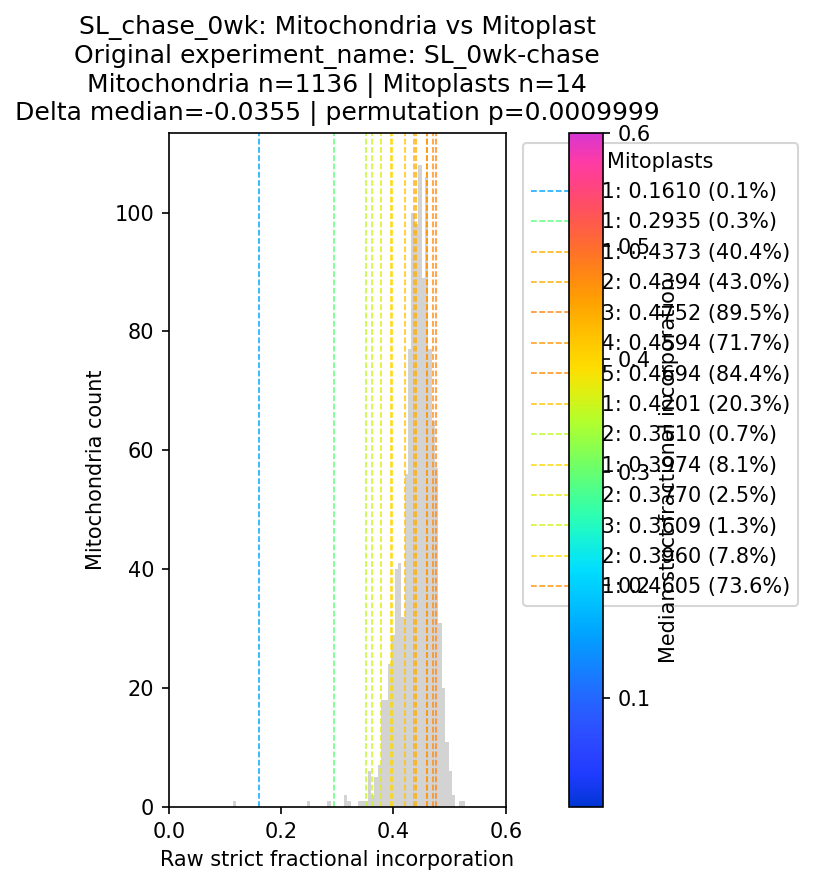

Saved graph for SL_chase_1wk: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group\mitochondria_histogram_with_mitoplast_lines_SL_chase_1wk.pdf


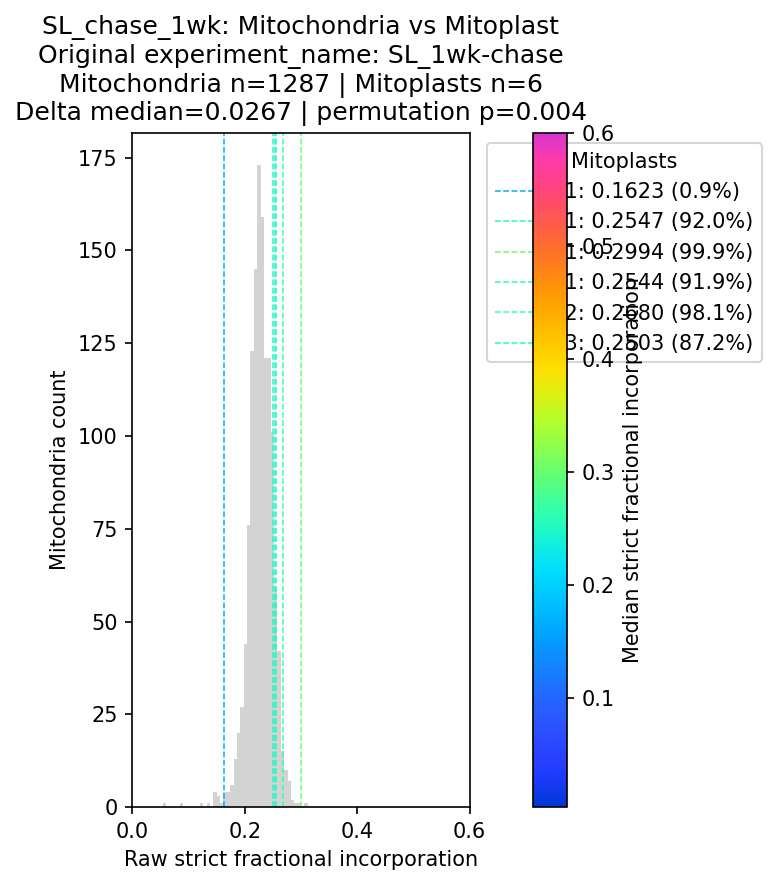

Saved graph for SL_chase_2wk: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group\mitochondria_histogram_with_mitoplast_lines_SL_chase_2wk.pdf


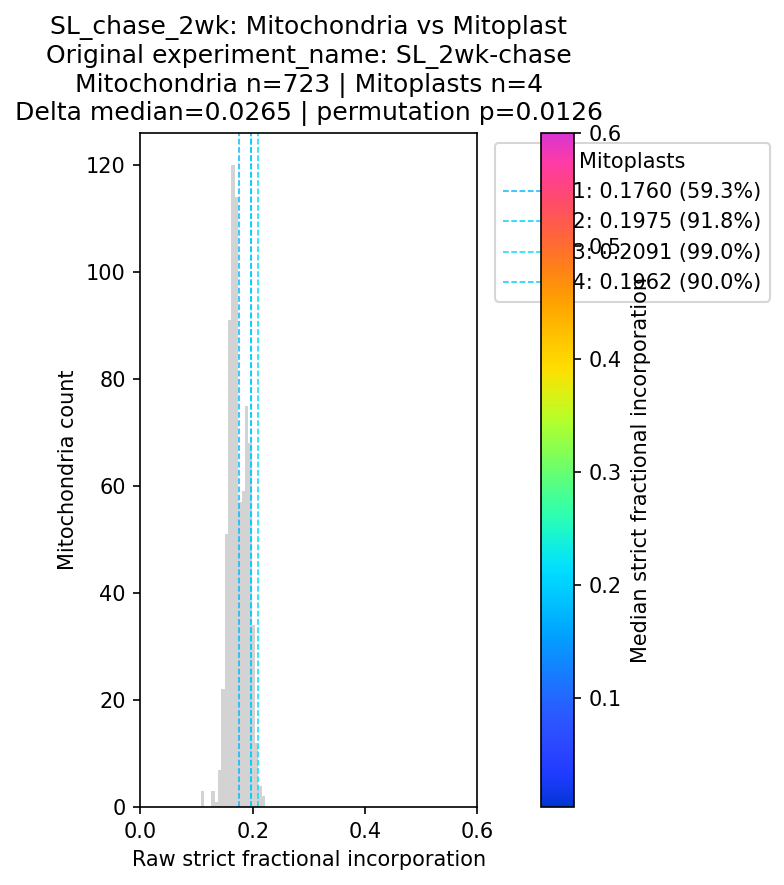


=== Chase-group permutation tests ===


,chase_group,source_experiment_names,sample_values_present,n_mitochondria,n_mitoplasts,mitochondria_median,mitoplast_median,delta_median_mitoplast_minus_mitochondria,p_value,pdf_path,png_path,fdr_q
0,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",1136,14,0.444278,0.408770,-0.035508,0.001000,c:\Users\narendradp\OneDrive - National Instit...,c:\Users\narendradp\OneDrive - National Instit...,0.003000
1,SL_chase_1wk,SL_1wk-chase,"S18_Ar2, S18_Ar6, S25_Ar1, S25_Ar3",1287,6,0.227825,0.254574,0.026748,0.004000,c:\Users\narendradp\OneDrive - National Instit...,c:\Users\narendradp\OneDrive - National Instit...,0.005999
2,SL_chase_2wk,SL_2wk-chase,S24_Ar2,723,4,0.170344,0.196884,0.026541,0.012599,c:\Users\narendradp\OneDrive - National Instit...,c:\Users\narendradp\OneDrive - National Instit...,0.012599



=== Individual mitoplast percentiles ===


,chase_group,source_experiment_names,sample_values_present,mitoplast_label_id,cell_label_id,mitoplast_sample,mitoplast_value,percentile_vs_mitochondria_same_chase_group,n_mitochondria_in_chase_group,n_mitoplasts_in_chase_group
4,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",3,1,S23_Ar7,0.475151,89.524648,1136,14
6,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",5,1,S23_Ar7,0.469438,84.419014,1136,14
13,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",1,1,S2_Ar5,0.460476,73.591549,1136,14
5,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",4,1,S23_Ar7,0.459448,71.742958,1136,14
3,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",2,1,S23_Ar7,0.439374,43.045775,1136,14
2,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",1,1,S23_Ar7,0.437348,40.404930,1136,14
7,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",1,1,S2_Ar1,0.420107,20.334507,1136,14
9,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",1,1,S2_Ar3,0.397433,8.098592,1136,14
12,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",2,1,S2_Ar4,0.396034,7.834507,1136,14
10,SL_chase_0wk,SL_0wk-chase,"S23_Ar2, S23_Ar4, S23_Ar7, S2_Ar1, S2_Ar3, S2_...",2,1,S2_Ar3,0.377023,2.464789,1136,14



Saved individual mitoplast percentile CSV: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group\individual_mitoplast_percentiles_by_chase_group.csv
Saved chase-group statistics CSV: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group\chase_group_permutation_tests.csv
Output directory: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitochondria_vs_mitoplast_by_SL_chase_group


In [7]:
import re
from itertools import count
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl
from scipy.stats import permutation_test

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.transparent": False,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# =============================
# Paths
# =============================
base_dir = Path.cwd()

def first_existing(paths, label):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {label}. Tried:\n" + "\n".join(str(p) for p in paths)
    )

CSV_PATH = first_existing(
    [
        base_dir / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv",
        base_dir / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv",
        Path("/mnt/data/MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
        Path("/mnt/data/MitoFLUXEM_2D_dataset_cleaned_annotations.csv"),
    ],
    "input morphology CSV",
)

LUT_PATH = first_existing(
    [
        base_dir / "LUT.csv",
        base_dir / "LUT(1).csv",
        Path("/mnt/data/LUT.csv"),
        Path("/mnt/data/LUT(1).csv"),
    ],
    "LUT CSV",
)

OUTPUT_DIR = CSV_PATH.parent / "output_mitochondria_vs_mitoplast_by_SL_chase_group"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================
# Load data
# =============================
df = pd.read_csv(CSV_PATH, low_memory=False)

# =============================
# Columns
# =============================
PREFERRED_VALUE_COL = "strict_reduced_raw_fractional_15N_median"

if PREFERRED_VALUE_COL in df.columns:
    VALUE_COL = PREFERRED_VALUE_COL
else:
    candidate_value_cols = [
        c for c in df.columns
        if "fractional_15N" in c and "median" in c
    ]
    if not candidate_value_cols:
        raise KeyError("Could not find a fractional 15N median column.")
    VALUE_COL = candidate_value_cols[0]

SAMPLE_COL = "sample"
LABEL_FILE_COL = "source_label_file"
EXPERIMENT_COL = "experiment_name" if "experiment_name" in df.columns else "group_name"

required_cols = [VALUE_COL, SAMPLE_COL, LABEL_FILE_COL, EXPERIMENT_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df[VALUE_COL] = pd.to_numeric(df[VALUE_COL], errors="coerce")

# =============================
# Natural chase group labels
#   CSV values such as SL_0wk-chase become SL_chase_0wk.
# =============================
def natural_chase_group_name(value):
    text = str(value).strip()

    # Already-natural format, e.g. SL_chase_0wk.
    m = re.match(
        r"^([A-Za-z]+)_chase_(\d+)\s*(wk|w|week|weeks|d|day|days)$",
        text,
        flags=re.I,
    )
    if m:
        condition = m.group(1).upper()
        n = int(m.group(2))
        unit_raw = m.group(3).lower()
        unit = "wk" if unit_raw in {"wk", "w", "week", "weeks"} else "d"
        return f"{condition}_chase_{n}{unit}"

    # Input CSV format, e.g. SL_0wk-chase or WT_0wk-chase.
    m = re.match(
        r"^([A-Za-z]+)_(\d+)\s*(wk|w|week|weeks|d|day|days)[_-]?chase$",
        text,
        flags=re.I,
    )
    if m:
        condition = m.group(1).upper()
        n = int(m.group(2))
        unit_raw = m.group(3).lower()
        unit = "wk" if unit_raw in {"wk", "w", "week", "weeks"} else "d"
        return f"{condition}_chase_{n}{unit}"

    # Keep unexpected labels visible, but normalize whitespace.
    return re.sub(r"\s+", "_", text)

def chase_sort_key(group_name):
    text = str(group_name)
    m = re.match(r"^([A-Za-z]+)_chase_(\d+)(wk|d)$", text, flags=re.I)
    if not m:
        return (99, 10**9, text)

    condition = m.group(1).upper()
    n = int(m.group(2))
    unit = m.group(3).lower()
    days = n * 7 if unit == "wk" else n

    condition_order = {"SL": 0, "WT": 1}
    return (condition_order.get(condition, 50), days, text)

df["chase_group"] = df[EXPERIMENT_COL].map(natural_chase_group_name)

# =============================
# LUT / color scale
# =============================
GLOBAL_VMIN = 0.0037
GLOBAL_VMAX = 0.6
LUT_NORM = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

def load_fiji_lut(path=LUT_PATH):
    try:
        lut_df = pd.read_csv(path)
        cols = [c.strip().lower() for c in lut_df.columns]

        if {"red", "green", "blue"}.issubset(cols):
            r, g, b = cols.index("red"), cols.index("green"), cols.index("blue")
        elif {"r", "g", "b"}.issubset(cols):
            r, g, b = cols.index("r"), cols.index("g"), cols.index("b")
        else:
            r, g, b = 1, 2, 3

        rgb = lut_df.iloc[:, [r, g, b]].to_numpy(dtype=float) / 255.0
        cmap = mpl.colors.ListedColormap(rgb)

        if hasattr(cmap, "with_extremes"):
            cmap = cmap.with_extremes(bad=(0, 0, 0, 0))

        return cmap
    except Exception as e:
        print(f"Could not load LUT CSV, falling back to viridis. Reason: {e}")
        return plt.get_cmap("viridis")

CUSTOM_CMAP = load_fiji_lut()

# =============================
# Subsets
# =============================
label_text = df[LABEL_FILE_COL].astype(str)

mitoplasts = df[
    label_text.str.contains("Mitoplast", case=False, na=False)
].copy()

mitochondria = df[
    label_text.str.contains("Mitochondria", case=False, na=False)
    & ~label_text.str.contains("Mitoplast", case=False, na=False)
].copy()

print(f"Input CSV: {CSV_PATH}")
print(f"LUT CSV:   {LUT_PATH}")
print(f"Value column used: {VALUE_COL}")
print(f"Experiment column used: {EXPERIMENT_COL}")
print(f"Mitoplast rows: {len(mitoplasts)}")
print(f"Mitochondria rows: {len(mitochondria)}")

print("\nMitoplasts by natural chase group:")
print(mitoplasts["chase_group"].value_counts().sort_index().to_string())

# =============================
# Filename helpers
# =============================
def safe_filename(name, max_len=140):
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", str(name))
    name = re.sub(r"_+", "_", name).strip("._-")
    if not name:
        name = "plot"
    return name[:max_len]

def unique_output_path(directory, stem, suffix):
    stem = safe_filename(stem)
    path = directory / f"{stem}{suffix}"

    if not path.exists():
        return path

    for i in count(2):
        candidate = directory / f"{stem}_{i}{suffix}"
        if not candidate.exists():
            return candidate

# =============================
# Stats helpers
# =============================
def median_difference(x, y):
    return np.median(x) - np.median(y)

def run_permutation_test(mito_vals, mitoplast_vals, n_resamples=10000, seed=42):
    """
    H0: mitoplasts and mitochondria are drawn from the same distribution.
    Statistic: difference in medians.
    Effect size returned below is median(mitoplasts) - median(mitochondria).
    """
    mito_vals = np.asarray(mito_vals, dtype=float)
    mitoplast_vals = np.asarray(mitoplast_vals, dtype=float)

    mito_vals = mito_vals[np.isfinite(mito_vals)]
    mitoplast_vals = mitoplast_vals[np.isfinite(mitoplast_vals)]

    if len(mito_vals) < 2 or len(mitoplast_vals) < 2:
        return np.nan, np.nan

    result = permutation_test(
        (mitoplast_vals, mito_vals),
        statistic=median_difference,
        permutation_type="independent",
        alternative="two-sided",
        n_resamples=n_resamples,
        random_state=seed,
    )

    effect_size = median_difference(mitoplast_vals, mito_vals)
    return effect_size, float(result.pvalue)

def bh_fdr(pvals):
    """
    Benjamini-Hochberg FDR correction without extra dependencies.
    Returns q-values aligned to pvals.
    """
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return qvals

    pv = pvals[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)

    adjusted = np.empty(m, dtype=float)
    prev = 1.0

    for i in range(m - 1, -1, -1):
        rank = i + 1
        val = (m / rank) * ranked[i]
        prev = min(prev, val)
        adjusted[i] = prev

    adjusted = np.clip(adjusted, 0, 1)

    back = np.empty(m, dtype=float)
    back[order] = adjusted
    qvals[np.where(valid)[0]] = back

    return qvals

def id_or_nan(value):
    try:
        if pd.isna(value):
            return np.nan
        return int(value)
    except Exception:
        return value

# =============================
# Plot helper
# =============================
def plot_chase_group_histogram(chase_group, mitoplast_group, bins=30):
    """
    For one natural chase group, for example SL_chase_0wk:
    - histogram of all mitochondria in that chase group
    - one vertical line per mitoplast in that chase group
    - line color from LUT based on mitoplast median strict fractional incorporation
    - permutation test comparing mitoplasts vs mitochondria
    """
    same_group_mito = mitochondria[
        mitochondria["chase_group"].astype(str) == str(chase_group)
    ].copy()

    same_group_mitoplasts = mitoplast_group.copy()

    mito_vals = (
        pd.to_numeric(same_group_mito[VALUE_COL], errors="coerce")
        .dropna()
        .to_numpy()
    )

    mitoplast_vals = (
        pd.to_numeric(same_group_mitoplasts[VALUE_COL], errors="coerce")
        .dropna()
        .to_numpy()
    )

    effect_size, p_value = run_permutation_test(mito_vals, mitoplast_vals)

    results = []

    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
    ax.set_box_aspect(2)
    ax.set_xlim(0, 0.6)

    original_experiment_names = ", ".join(
        sorted(same_group_mitoplasts[EXPERIMENT_COL].dropna().astype(str).unique())
    )

    sample_values = ", ".join(
        sorted(same_group_mitoplasts[SAMPLE_COL].dropna().astype(str).unique())
    )

    if len(mito_vals) == 0:
        ax.text(
            0.5,
            0.5,
            f"No mitochondria found for chase group {chase_group}",
            ha="center",
            va="center",
            fontsize=12,
        )

        ax.set_axis_off()
        fig.suptitle(
            f"{chase_group}: Mitochondria vs Mitoplast",
            fontsize=13,
            weight="bold",
        )

        fig.tight_layout()

        pdf_path = unique_output_path(
            OUTPUT_DIR,
            f"mitochondria_histogram_with_mitoplast_lines_{chase_group}_no_mitochondria",
            ".pdf",
        )
        png_path = pdf_path.with_suffix(".png")

        fig.savefig(
            pdf_path,
            format="pdf",
            dpi=300,
            facecolor="white",
            edgecolor="white",
            bbox_inches="tight",
        )
        fig.savefig(
            png_path,
            format="png",
            dpi=300,
            facecolor="white",
            edgecolor="white",
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        return results, {
            "chase_group": chase_group,
            "source_experiment_names": original_experiment_names,
            "sample_values_present": sample_values,
            "n_mitochondria": int(len(mito_vals)),
            "n_mitoplasts": int(len(mitoplast_vals)),
            "mitochondria_median": np.nan,
            "mitoplast_median": np.nan,
            "delta_median_mitoplast_minus_mitochondria": np.nan,
            "p_value": np.nan,
            "pdf_path": str(pdf_path),
            "png_path": str(png_path),
        }

    ax.hist(
        mito_vals,
        bins=np.linspace(0, 0.6, bins + 1),
        color="lightgray",
        edgecolor=None,
    )

    # Plot each mitoplast as a vertical line colored by its own incorporation value.
    for _, mp in same_group_mitoplasts.iterrows():
        mp_value = pd.to_numeric(
            pd.Series([mp[VALUE_COL]]),
            errors="coerce",
        ).iloc[0]

        if pd.isna(mp_value):
            continue

        percentile = 100.0 * (np.sum(mito_vals <= mp_value) / len(mito_vals))
        color_value = float(np.clip(mp_value, GLOBAL_VMIN, GLOBAL_VMAX))
        line_color = CUSTOM_CMAP(LUT_NORM(color_value))

        label_id = id_or_nan(mp.get("label_id", np.nan))
        cell_label_id = id_or_nan(mp.get("cell_label_id", np.nan))

        label_text_for_legend = f"L{label_id}: {mp_value:.4f} ({percentile:.1f}%)"

        ax.axvline(
            mp_value,
            color=line_color,
            linewidth=0.75,
            alpha=0.95,
            ls='--',
            label=label_text_for_legend,
        )

        results.append({
            "chase_group": chase_group,
            "source_experiment_names": original_experiment_names,
            "sample_values_present": sample_values,
            "mitoplast_label_id": label_id,
            "cell_label_id": cell_label_id,
            "mitoplast_sample": str(mp[SAMPLE_COL]),
            "mitoplast_value": float(mp_value),
            "percentile_vs_mitochondria_same_chase_group": float(percentile),
            "n_mitochondria_in_chase_group": int(len(mito_vals)),
            "n_mitoplasts_in_chase_group": int(len(same_group_mitoplasts)),
        })

    mito_median = float(np.median(mito_vals)) if len(mito_vals) else np.nan
    mp_median = float(np.median(mitoplast_vals)) if len(mitoplast_vals) else np.nan

    title_lines = [
        f"{chase_group}: Mitochondria vs Mitoplast",
        f"Original experiment_name: {original_experiment_names}",
        f"Mitochondria n={len(mito_vals)} | Mitoplasts n={len(mitoplast_vals)}",
    ]

    if np.isfinite(effect_size) and np.isfinite(p_value):
        title_lines.append(
            f"Delta median={effect_size:.4f} | permutation p={p_value:.4g}"
        )

    ax.set_xlim(0, 0.6)
    ax.set_title("\n".join(title_lines))
    ax.set_xlabel("Raw strict fractional incorporation")
    ax.set_ylabel("Mitochondria count")
    ax.legend(title="Mitoplasts", bbox_to_anchor=(1.02, 1), loc="upper left")

    sm = mpl.cm.ScalarMappable(norm=LUT_NORM, cmap=CUSTOM_CMAP)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Median strict fractional incorporation")

    fig.tight_layout()

    # Proper unique output names:
    # - no newlines
    # - no title punctuation
    # - includes natural chase group, e.g. SL_chase_0wk
    output_stem = f"mitochondria_histogram_with_mitoplast_lines_{chase_group}"

    pdf_path = unique_output_path(OUTPUT_DIR, output_stem, ".pdf")
    png_path = pdf_path.with_suffix(".png")

    fig.savefig(
        pdf_path,
        format="pdf",
        dpi=300,
        facecolor="white",
        edgecolor="white",
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        format="png",
        dpi=300,
        facecolor="white",
        edgecolor="white",
        bbox_inches="tight",
    )

    print(f"Saved graph for {chase_group}: {pdf_path}")

    plt.show()
    plt.close(fig)

    chase_stats = {
        "chase_group": chase_group,
        "source_experiment_names": original_experiment_names,
        "sample_values_present": sample_values,
        "n_mitochondria": int(len(mito_vals)),
        "n_mitoplasts": int(len(mitoplast_vals)),
        "mitochondria_median": mito_median,
        "mitoplast_median": mp_median,
        "delta_median_mitoplast_minus_mitochondria": effect_size,
        "p_value": p_value,
        "pdf_path": str(pdf_path),
        "png_path": str(png_path),
    }

    return results, chase_stats

# =============================
# Run by natural chase group
# =============================
summary_rows = []
chase_stats_rows = []

chase_groups_to_plot = sorted(
    mitoplasts["chase_group"].dropna().astype(str).unique(),
    key=chase_sort_key,
)

if len(chase_groups_to_plot) == 0:
    raise ValueError("No mitoplast chase groups were found to plot.")

for chase_group in chase_groups_to_plot:
    mitoplast_group = mitoplasts[
        mitoplasts["chase_group"].astype(str) == str(chase_group)
    ]

    res_rows, stats_row = plot_chase_group_histogram(
        chase_group=chase_group,
        mitoplast_group=mitoplast_group,
        bins=100,
    )

    summary_rows.extend(res_rows)
    chase_stats_rows.append(stats_row)

summary_df = pd.DataFrame(summary_rows)
chase_stats_df = pd.DataFrame(chase_stats_rows)

if not chase_stats_df.empty:
    chase_stats_df["fdr_q"] = bh_fdr(chase_stats_df["p_value"].to_numpy())

summary_csv = OUTPUT_DIR / "individual_mitoplast_percentiles_by_chase_group.csv"
stats_csv = OUTPUT_DIR / "chase_group_permutation_tests.csv"

summary_df.to_csv(summary_csv, index=False)
chase_stats_df.to_csv(stats_csv, index=False)

print("\n=== Chase-group permutation tests ===")
if not chase_stats_df.empty:
    display(
        chase_stats_df.sort_values(
            ["p_value", "chase_group"],
            ascending=[True, True],
        )
    )
else:
    print("No chase-group statistics were produced.")

print("\n=== Individual mitoplast percentiles ===")
if not summary_df.empty:
    display(
        summary_df.sort_values(
            [
                "chase_group",
                "percentile_vs_mitochondria_same_chase_group",
                "mitoplast_label_id",
            ],
            ascending=[True, False, True],
        )
    )
else:
    print("No individual mitoplast percentile rows were produced.")

print(f"\nSaved individual mitoplast percentile CSV: {summary_csv}")
print(f"Saved chase-group statistics CSV: {stats_csv}")
print(f"Output directory: {OUTPUT_DIR}")

Unique chase groups in source data:
['SL_0wk-chase', 'SL_1wk-chase', 'SL_2wk-chase', 'SL_4wk-chase', 'WT_0wk-chase']

Rows in all chase groups (SL_0wk-chase, SL_1wk-chase, SL_2wk-chase, SL_4wk-chase): 5248
Rows in SL_0wk-chase only: 1780
15N incorporation: using column 'strict_reduced_raw_fractional_15N_mean'
Object area: using column 'area_nm2'
Median 32S normalized by field: using column 'strict_reduced_mean_norm_32S_median'
Median 31P normalized by field: using column 'strict_reduced_mean_norm_31P_median'
12C14N + 12C15N sum normalized by field: using column 'strict_reduced_mean_norm_sum_12C14N_12C15N_mean'
Partial-wrap flag: using column 'partially_wrapped'

Metric: 15N incorporation
Using data column: strict_reduced_raw_fractional_15N_mean
  Mitochondria: 1136
  Partially wrapped: 12
  Mitolysosome grade 1: 11
  Mitolysosome grade 2: 18
  Mitolysosome grade 3: 72
  Mitolysosome grade 4: 65
Overall Kruskal-Wallis p = 5.53e-32
                          comparison  n_ref  n_group    

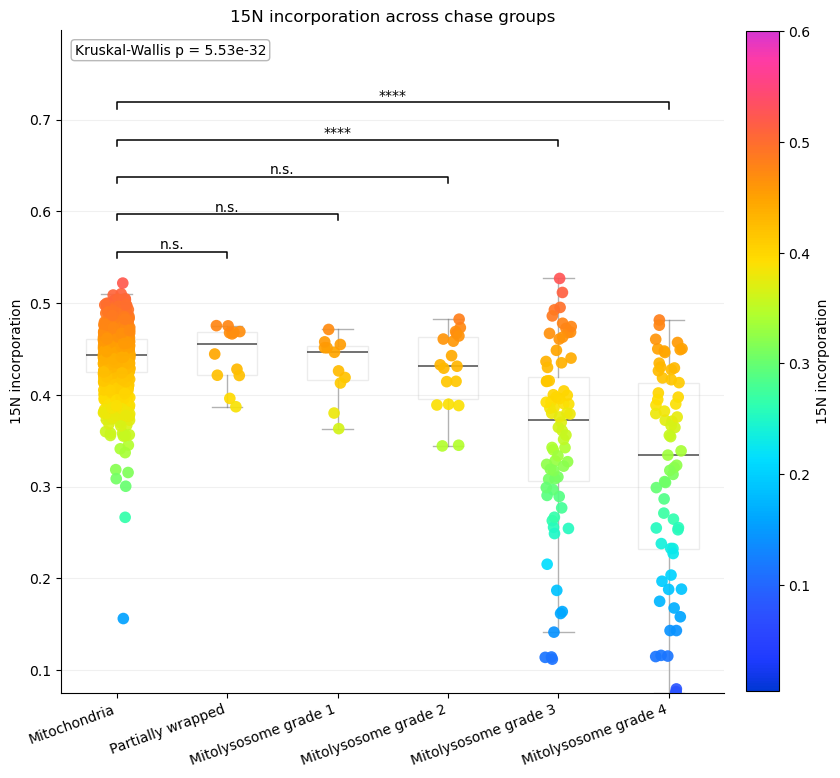

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\0wk_SL0wk_chase_15N_incorporation.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: log10(Object area nm²)
Using data column: area_nm2
  Mitochondria: 3958
  Partially wrapped: 19
  Mitolysosome grade 1: 27
  Mitolysosome grade 2: 39
  Mitolysosome grade 3: 102
  Mitolysosome grade 4: 105
Overall Kruskal-Wallis p = 2.48e-38
                          comparison  n_ref  n_group        U        p_raw       p_holm significance
   Mitochondria vs Partially wrapped   3958       19  10496.0 5.680935e-08 2.272374e-07         ****
Mitochondria vs Mitolysosome grade 1   3958       27  24005.0 7.844849e-07 2.353455e-06         ****
Mitochondria vs Mitolysosome grade 2   3958       39  50585.0 2.084280e-04 2.084280e-04          ***
Mitochondria vs Mitolysosome grade 3   3958      102 250959.0 2.660864e-05 5.321729e-05         ****
Mitochondri

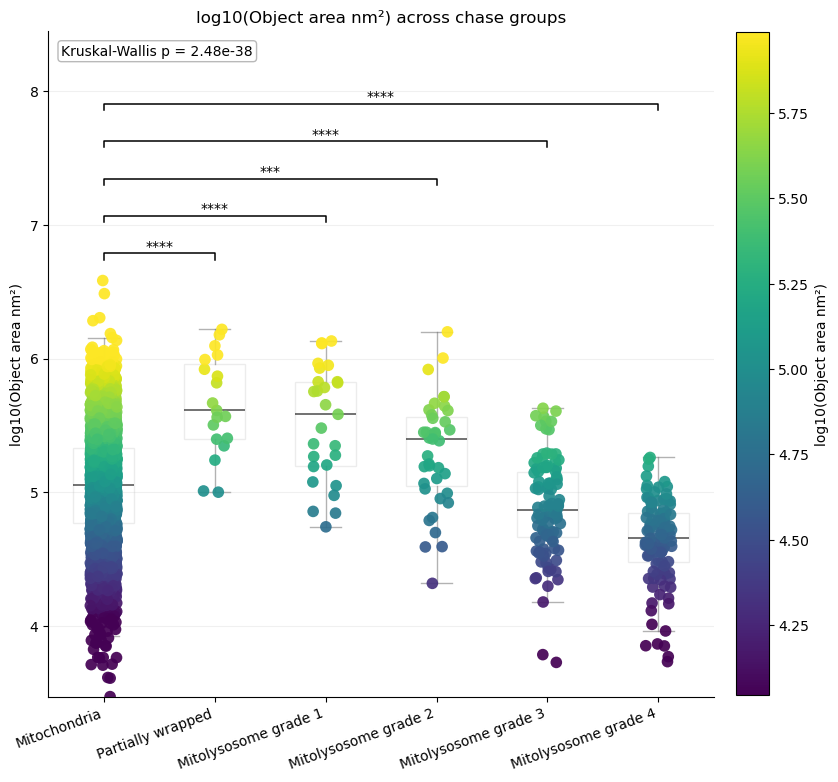

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_log10_object_area.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: Median 32S normalized by field
Using data column: strict_reduced_mean_norm_32S_median
  Mitochondria: 3958
  Partially wrapped: 19
  Mitolysosome grade 1: 27
  Mitolysosome grade 2: 39
  Mitolysosome grade 3: 102
  Mitolysosome grade 4: 105
Overall Kruskal-Wallis p = 1.25e-45
                          comparison  n_ref  n_group        U        p_raw       p_holm significance
   Mitochondria vs Partially wrapped   3958       19  44625.0 1.595174e-01 4.785521e-01         n.s.
Mitochondria vs Mitolysosome grade 1   3958       27  55595.0 7.167584e-01 1.000000e+00         n.s.
Mitochondria vs Mitolysosome grade 2   3958       39  75579.5 8.233400e-01 1.000000e+00         n.s.
Mitochondria vs Mitolysosome grade 3   3958      102 319308.5 9.347279e-24 3.738912

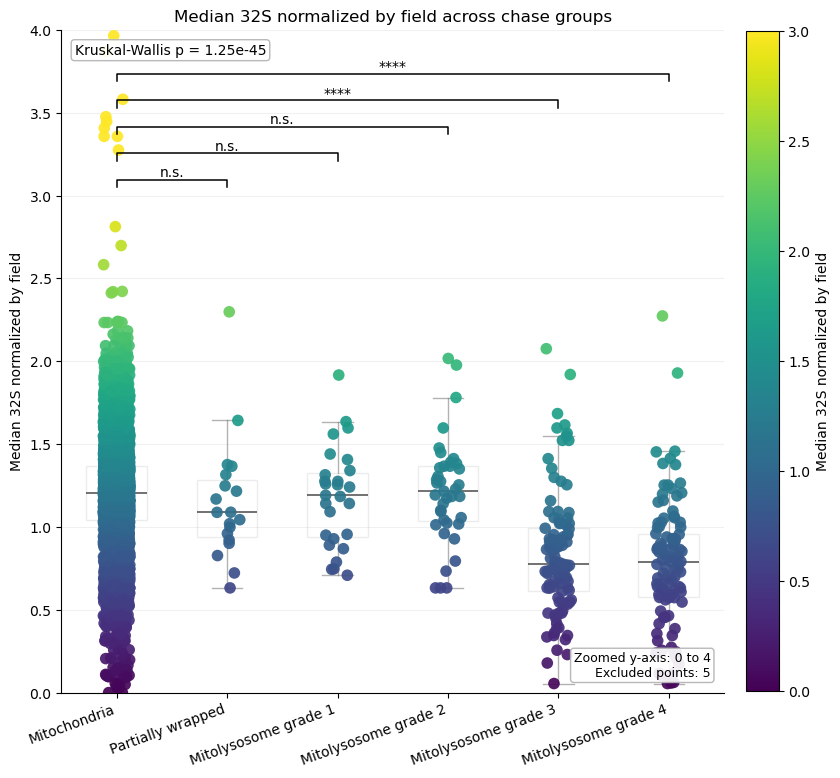

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_median_32S_normalized_by_field.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: Median 31P normalized by field
Using data column: strict_reduced_mean_norm_31P_median
  Mitochondria: 3958
  Partially wrapped: 19
  Mitolysosome grade 1: 27
  Mitolysosome grade 2: 39
  Mitolysosome grade 3: 102
  Mitolysosome grade 4: 105
Overall Kruskal-Wallis p = 5.19e-12
                          comparison  n_ref  n_group        U    p_raw   p_holm significance
   Mitochondria vs Partially wrapped   3958       19  54925.5 0.000510 0.001530           **
Mitochondria vs Mitolysosome grade 1   3958       27  69117.5 0.008370 0.008370           **
Mitochondria vs Mitolysosome grade 2   3958       39  97787.0 0.004001 0.008002           **
Mitochondria vs Mitolysosome grade 3   3958      102 159299.0 0.000266 0.001063           **
Mitochond

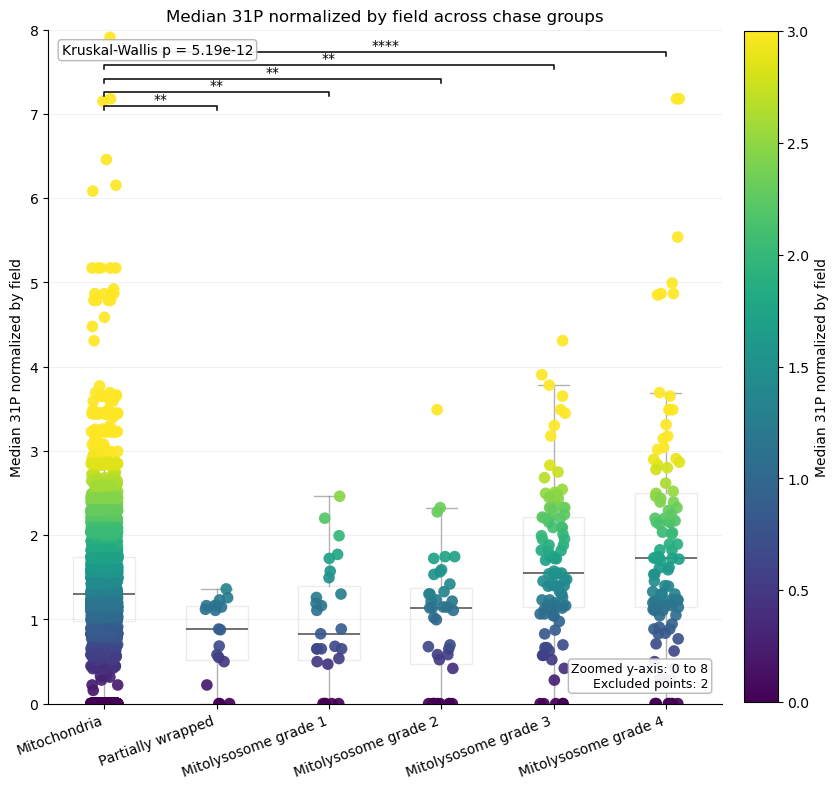

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_median_31P_normalized_by_field.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: 12C14N + 12C15N sum normalized by field
Using data column: strict_reduced_mean_norm_sum_12C14N_12C15N_mean
  Mitochondria: 3958
  Partially wrapped: 19
  Mitolysosome grade 1: 27
  Mitolysosome grade 2: 39
  Mitolysosome grade 3: 102
  Mitolysosome grade 4: 105
Overall Kruskal-Wallis p = 2.09e-39
                          comparison  n_ref  n_group        U        p_raw       p_holm significance
   Mitochondria vs Partially wrapped   3958       19  47535.0 4.664509e-02 1.399353e-01         n.s.
Mitochondria vs Mitolysosome grade 1   3958       27  64593.0 6.106293e-02 1.399353e-01         n.s.
Mitochondria vs Mitolysosome grade 2   3958       39  83091.0 4.099152e-01 4.099152e-01         n.s.
Mitochondria vs Mitolysosome grade 3   3958      

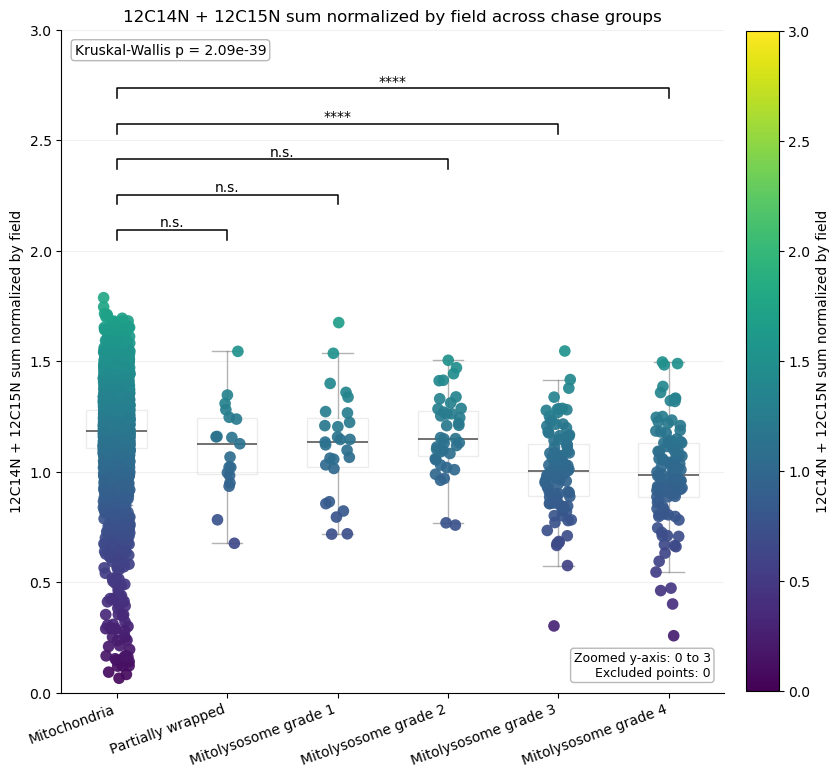

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_sum_12C14N_12C15N_normalized_by_field.pdf


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.colors import Normalize, LogNorm
from scipy.stats import kruskal, mannwhitneyu

# Illustrator-friendly PDF text
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ============================================================
# Paths
# ============================================================
BASE_DIR = Path(globals().get("SCRIPT_DIR", Path.cwd()))
CSV_PATH = BASE_DIR / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv"
LUT_PATH = BASE_DIR / "LUT.csv"
OUT_DIR = Path(globals().get("OUT_DIR", BASE_DIR / "output_lysosome_pulse_chase_analysis"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Constants
# ============================================================
SCORE_COL = "content_morphology_score"
CHASE_COL = "group_name"
FIGSIZE_SQUARE = (8.5, 8.5)

GROUP_ORDER = [
    "Mitochondria",
    "Partially wrapped",
    "Mitolysosome grade 1",
    "Mitolysosome grade 2",
    "Mitolysosome grade 3",
    "Mitolysosome grade 4",
]

CHASE_ALL = ["SL_0wk-chase", "SL_1wk-chase", "SL_2wk-chase", "SL_4wk-chase"]

# Metric column candidates
AREA_CANDIDATES = ["area_nm2", "area", "object_area", "profile_area"]
S32_CANDIDATES = ["strict_reduced_mean_norm_32S_median", "strict_reduced_mean_norm_32S_mean"]
P31_CANDIDATES = ["strict_reduced_mean_norm_31P_median", "strict_reduced_mean_norm_31P_mean"]
SUM_CANDIDATES = [
    "strict_reduced_mean_norm_sum_12C14N_12C15N_mean",
    "strict_reduced_mean_norm_sum_12C14N_12C15N_median",
]
N15_COL = "strict_reduced_raw_fractional_15N_mean"

# ============================================================
# LUT loader
# ============================================================
def load_fiji_lut(path):
    df_lut = pd.read_csv(path)
    cols = [c.strip().lower() for c in df_lut.columns]

    if "red" in cols:
        r, g, b = cols.index("red"), cols.index("green"), cols.index("blue")
    elif "r" in cols:
        r, g, b = cols.index("r"), cols.index("g"), cols.index("b")
    else:
        r, g, b = 0, 1, 2

    rgb = df_lut.iloc[:, [r, g, b]].to_numpy(dtype=float) / 255.0
    cmap = mpl.colors.ListedColormap(rgb)
    if hasattr(cmap, "with_extremes"):
        cmap = cmap.with_extremes(bad=(0, 0, 0, 0))
    return cmap

CUSTOM_LUT = load_fiji_lut(LUT_PATH)
VIRIDIS = plt.get_cmap("viridis")

# ============================================================
# Helpers
# ============================================================
def save_figure(fig, filename):
    out_path = OUT_DIR / filename
    fig.savefig(out_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path.resolve()}")

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return adj

    ordered = idx[np.argsort(pvals[valid])]
    m = len(ordered)
    running_max = 0.0

    for rank, i in enumerate(ordered):
        raw = pvals[i] * (m - rank)
        running_max = max(running_max, raw)
        adj[i] = min(running_max, 1.0)

    return adj

def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1.1, clip_on=False, zorder=6)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=10, zorder=7)

def box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18):
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_edgecolor(edgecolor)
        patch.set_alpha(alpha)
        patch.set_linewidth(1.0)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.2)
        med.set_alpha(0.65)
    for whisk in bp["whiskers"]:
        whisk.set_color("0.45")
        whisk.set_linewidth(1.0)
        whisk.set_alpha(0.55)
    for cap in bp["caps"]:
        cap.set_color("0.45")
        cap.set_linewidth(1.0)
        cap.set_alpha(0.55)

def parse_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])

def resolve_column(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            print(f"{label}: using column '{c}'")
            return c
    raise ValueError(f"Could not find a valid column for {label}. Tried: {candidates}")

def resolve_partial_mask(df):
    if "partially_wrapped" in df.columns:
        print("Partial-wrap flag: using column 'partially_wrapped'")
        return parse_bool_series(df["partially_wrapped"])
    if "partially_wrapped_group_name" in df.columns:
        print("Partial-wrap flag: using column 'partially_wrapped_group_name'")
        return df["partially_wrapped_group_name"].astype(str).str.strip().str.len() > 0
    print("Partial-wrap flag: falling back to source_label_file text match")
    return df["source_label_file"].astype(str).str.contains("partially_wrapped", case=False, na=False)

def make_group_masks(df):
    partial_mask = resolve_partial_mask(df)
    mito_mask = df["source_label_file"].astype(str).str.contains("Mitochondria", case=False, na=False)
    mitolysosome_mask = df["source_label_file"].astype(str).str.contains("Mitolysosome", case=False, na=False)

    return {
        "Mitochondria": mito_mask & ~partial_mask,
        "Partially wrapped": partial_mask,
        "Mitolysosome grade 1": mitolysosome_mask & (df[SCORE_COL] == 1) & ~partial_mask,
        "Mitolysosome grade 2": mitolysosome_mask & (df[SCORE_COL] == 2) & ~partial_mask,
        "Mitolysosome grade 3": mitolysosome_mask & (df[SCORE_COL] == 3) & ~partial_mask,
        "Mitolysosome grade 4": mitolysosome_mask & (df[SCORE_COL] == 4) & ~partial_mask,
    }

def build_plot_df(df, metric_col, group_masks):
    rows = []
    counts = {}
    for label in GROUP_ORDER:
        vals = df.loc[group_masks[label], metric_col].dropna().to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        counts[label] = len(vals)
        if len(vals) > 0:
            rows.append(pd.DataFrame({"group": label, "value": vals}))
    if len(rows) == 0:
        return pd.DataFrame(columns=["group", "value"]), counts
    return pd.concat(rows, ignore_index=True), counts

def metric_norm(values, fixed_vmin=None, fixed_vmax=None, use_log=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return Normalize(vmin=0, vmax=1)

    if fixed_vmin is not None and fixed_vmax is not None:
        if use_log:
            vmin = max(float(fixed_vmin), 1e-12)
            vmax = max(float(fixed_vmax), vmin * 1.01)
            return LogNorm(vmin=vmin, vmax=vmax)
        return Normalize(vmin=float(fixed_vmin), vmax=float(fixed_vmax))

    pos = values[values > 0]
    if use_log and len(pos) > 0:
        vmin = np.nanpercentile(pos, 1)
        vmax = np.nanpercentile(pos, 99)
        vmin = max(vmin, np.nanmin(pos))
        vmax = max(vmax, vmin * 1.01)
        return LogNorm(vmin=vmin, vmax=vmax)

    vmin = np.nanpercentile(values, 1)
    vmax = np.nanpercentile(values, 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)
    if vmin == vmax:
        vmax = vmin + 1.0
    return Normalize(vmin=vmin, vmax=vmax)

def zoom_exclusion_count(values, ylim):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    lo, hi = ylim
    return int(np.sum((values < lo) | (values > hi)))

def plot_metric_panel(
    df,
    metric_col,
    metric_label,
    out_name,
    cmap,
    norm=None,
    fixed_ylim=None,
    transform=None,
):
    group_masks = make_group_masks(df)
    plot_df, counts = build_plot_df(df, metric_col, group_masks)
    if plot_df.empty:
        raise ValueError(f"No valid data found for metric '{metric_col}'.")

    transform_excluded = 0
    if transform == "log10":
        positive_mask = plot_df["value"] > 0
        transform_excluded = int((~positive_mask).sum())
        plot_df = plot_df.loc[positive_mask].copy()
        plot_df["value"] = np.log10(plot_df["value"].to_numpy(dtype=float))
        if transform_excluded > 0:
            print(f"{metric_label}: log10 transform excluded {transform_excluded} nonpositive values")

    if plot_df.empty:
        raise ValueError(f"All values were removed for metric '{metric_col}' after transform/filtering.")

    group_names_used = [g for g in GROUP_ORDER if (plot_df["group"] == g).any()]
    group_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_names_used]

    if len(group_data) < 2:
        raise ValueError(f"Need at least two groups with data for metric '{metric_col}'.")

    print(f"\nMetric: {metric_label}")
    print(f"Using data column: {metric_col}")
    for g in group_names_used:
        print(f"  {g}: {counts[g]}")

    overall_p = kruskal(*group_data).pvalue

    ref_name = "Mitochondria"
    ref_vals = plot_df.loc[plot_df["group"] == ref_name, "value"].to_numpy(dtype=float)

    posthoc_rows = []
    raw_pvals = []

    for label in group_names_used:
        if label == ref_name:
            continue
        vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        u = mannwhitneyu(ref_vals, vals, alternative="two-sided")
        raw_pvals.append(u.pvalue)
        posthoc_rows.append(
            {
                "comparison": f"{ref_name} vs {label}",
                "n_ref": len(ref_vals),
                "n_group": len(vals),
                "U": float(u.statistic),
                "p_raw": float(u.pvalue),
            }
        )

    adj_pvals = holm_adjust(raw_pvals)
    for i, ap in enumerate(adj_pvals):
        posthoc_rows[i]["p_holm"] = float(ap)
        posthoc_rows[i]["significance"] = p_to_stars(ap)

    stats_df = pd.DataFrame(posthoc_rows)

    print(f"Overall Kruskal-Wallis p = {overall_p:.3g}")
    if not stats_df.empty:
        print(stats_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    ax.set_box_aspect(1)

    x_pos = np.arange(len(group_names_used))
    box_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_names_used]

    bp = ax.boxplot(
        box_data,
        positions=x_pos,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        zorder=1,
        medianprops=dict(color="black", linewidth=1.2, alpha=0.65),
        whiskerprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
        capprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
    )
    box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18)

    all_vals = plot_df["value"].to_numpy(dtype=float)
    if norm is None:
        norm = metric_norm(all_vals)

    rng = np.random.default_rng(0)
    for i, label in enumerate(group_names_used):
        vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            c=vals,
            cmap=cmap,
            norm=norm,
            s=70,
            alpha=0.92,
            edgecolors='none',   # Change from None to 'none'
            linewidths=0,        # Explicitly set the linewidth to 0
            zorder=4,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_names_used, rotation=20, ha="right")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} across chase groups")
    ax.grid(axis="y", alpha=0.18, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label(metric_label)

    ax.text(
        0.02,
        0.98,
        f"Kruskal-Wallis p = {overall_p:.3g}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
        zorder=8,
    )

    if fixed_ylim is not None:
        lo, hi = fixed_ylim
        ax.set_ylim(lo, hi)

        excluded = zoom_exclusion_count(all_vals, fixed_ylim)
        zoom_msg = f"Zoomed y-axis: {lo:g} to {hi:g}\nExcluded points: {excluded}"
        print(f"{metric_label}: {zoom_msg.replace(chr(10), ' | ')}")

        ax.text(
            0.98,
            0.02,
            zoom_msg,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
            zorder=8,
        )

        ref_idx = group_names_used.index(ref_name)
        base_y = hi - 0.95
        step = 0.16
        h = 0.045
        anno_i = 0
        for _, row in stats_df.iterrows():
            group_label = row["comparison"].split(" vs ")[1]
            if group_label not in group_names_used:
                continue
            grp_idx = group_names_used.index(group_label)
            y = base_y + anno_i * step
            if y + h <= hi - 0.02:
                add_bracket(ax, ref_idx, grp_idx, y, h, row["significance"])
            anno_i += 1
    else:
        ymax = float(np.nanmax(all_vals))
        ymin = float(np.nanmin(all_vals))
        yrng = max(ymax - ymin, 0.05 * max(abs(ymax), 1.0))

        base_y = ymax + 0.05 * yrng
        step = 0.09 * yrng
        h = 0.015 * yrng

        ref_idx = group_names_used.index(ref_name)
        anno_i = 0
        for _, row in stats_df.iterrows():
            group_label = row["comparison"].split(" vs ")[1]
            if group_label not in group_names_used:
                continue
            grp_idx = group_names_used.index(group_label)
            y = base_y + anno_i * step
            add_bracket(ax, ref_idx, grp_idx, y, h, row["significance"])
            anno_i += 1

        upper = base_y + max(1, anno_i) * step + 0.10 * yrng
        if upper > ymax:
            ax.set_ylim(ymin if ymin < ymax else 0, upper)

    if transform == "log10" and transform_excluded > 0:
        ax.text(
            0.98,
            0.02,
            f"log10(area) excluded {transform_excluded} nonpositive values",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
            zorder=8,
        )

    fig.tight_layout()
    save_figure(fig, out_name)

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(CSV_PATH, low_memory=False)
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")

print("Unique chase groups in source data:")
print(sorted(df[CHASE_COL].dropna().astype(str).unique().tolist()))

df_all = df[df[CHASE_COL].astype(str).isin(CHASE_ALL)].copy()
df_0wk = df[df[CHASE_COL].astype(str).eq("SL_0wk-chase")].copy()

print(f"\nRows in all chase groups ({', '.join(CHASE_ALL)}): {len(df_all)}")
print(f"Rows in SL_0wk-chase only: {len(df_0wk)}")
if df_all.empty:
    raise ValueError("No rows found for the full chase-group subset.")
if df_0wk.empty:
    raise ValueError("No rows found for SL_0wk-chase.")

# ============================================================
# Resolve exact metric columns from the dataframe
# ============================================================
N15_COL = resolve_column(df, [N15_COL], "15N incorporation")
AREA_COL = resolve_column(df, AREA_CANDIDATES, "Object area")
S32_COL = resolve_column(df, S32_CANDIDATES, "Median 32S normalized by field")
P31_COL = resolve_column(df, P31_CANDIDATES, "Median 31P normalized by field")
SUM_COL = resolve_column(df, SUM_CANDIDATES, "12C14N + 12C15N sum normalized by field")

# Convert selected metric columns to numeric in both dataframes
for c in [N15_COL, AREA_COL, S32_COL, P31_COL, SUM_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")
    df_0wk[c] = pd.to_numeric(df_0wk[c], errors="coerce")

# ============================================================
# Make the plots
# ============================================================
# 15N incorporation: only 0wk chase, custom LUT.csv colormap
plot_metric_panel(
    df_0wk,
    N15_COL,
    "15N incorporation",
    "0wk_SL0wk_chase_15N_incorporation.pdf",
    cmap=CUSTOM_LUT,
    norm=Normalize(vmin=0.0037, vmax=0.6),
)

# Area: convert to log10(area), all chase groups, viridis
plot_metric_panel(
    df_all,
    AREA_COL,
    "log10(Object area nm²)",
    "all_chase_log10_object_area.pdf",
    cmap=VIRIDIS,
    norm=None,
    transform="log10",
)

# 32S: all chase groups, viridis, fixed y-axis 0-3
plot_metric_panel(
    df_all,
    S32_COL,
    "Median 32S normalized by field",
    "all_chase_median_32S_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 4),
)

# 31P: all chase groups, viridis, fixed y-axis 0-3
plot_metric_panel(
    df_all,
    P31_COL,
    "Median 31P normalized by field",
    "all_chase_median_31P_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 8),
)

# Total nitrogen: all chase groups, viridis, fixed y-axis 0-3
plot_metric_panel(
    df_all,
    SUM_COL,
    "12C14N + 12C15N sum normalized by field",
    "all_chase_sum_12C14N_12C15N_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 3),
)

Unique chase groups in source data:
['SL_0wk-chase', 'SL_1wk-chase', 'SL_2wk-chase', 'SL_4wk-chase', 'WT_0wk-chase']

Rows in all chase groups (SL_0wk-chase, SL_1wk-chase, SL_2wk-chase, SL_4wk-chase): 5248
Rows in SL_0wk-chase only: 1780
15N incorporation: using column 'strict_reduced_raw_fractional_15N_mean'
Object area: using column 'area_nm2'
Median 32S normalized by field: using column 'strict_reduced_mean_norm_32S_median'
Median 31P normalized by field: using column 'strict_reduced_mean_norm_31P_median'
12C14N + 12C15N sum normalized by field: using column 'strict_reduced_mean_norm_sum_12C14N_12C15N_mean'
Partial-wrap flag: using column 'partially_wrapped'

Metric: 15N incorporation
Using data column: strict_reduced_raw_fractional_15N_mean
  Mitochondria: 1136
  Partially ruptured: 12
  Mitoplasts: 14
Overall Kruskal-Wallis p = 0.0208
                        comparison  n_ref  n_group       U    p_raw   p_holm significance
Mitochondria vs Partially ruptured   1136       12  6242.0

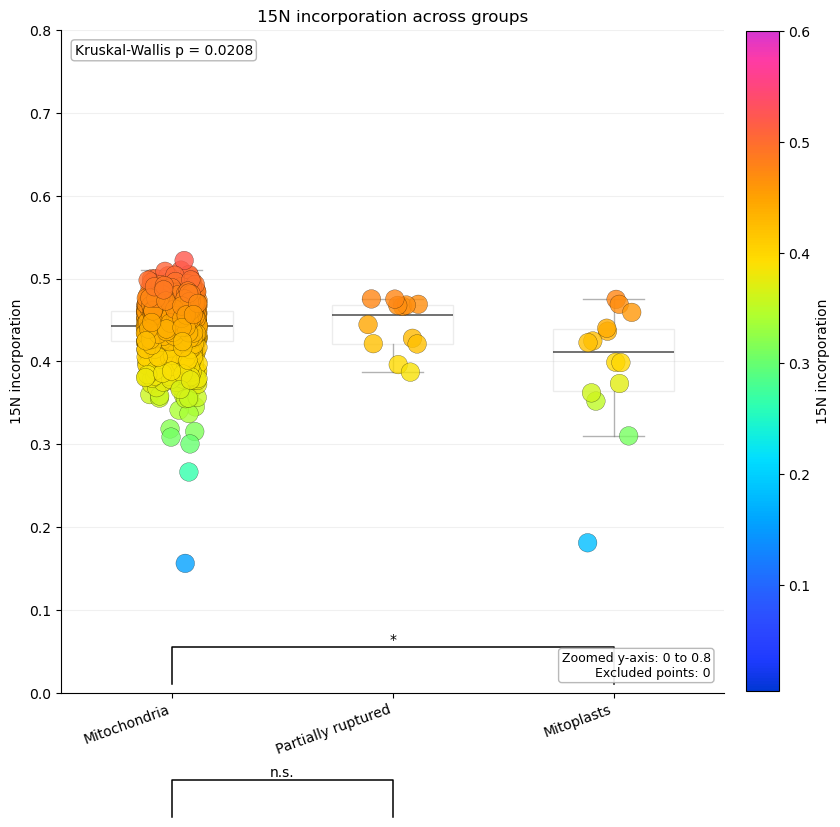

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\0wk_mito_partially_ruptured_mitoplasts_15N_incorporation.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: log10(Object area nm²)
Using data column: area_nm2
  Mitochondria: 3958
  Partially ruptured: 19
  Mitoplasts: 24
Overall Kruskal-Wallis p = 1.27e-07
                        comparison  n_ref  n_group       U        p_raw       p_holm significance
Mitochondria vs Partially ruptured   3958       19 10496.0 5.680935e-08 1.136187e-07         ****
        Mitochondria vs Mitoplasts   3958       24 38832.0 1.228571e-01 1.228571e-01         n.s.


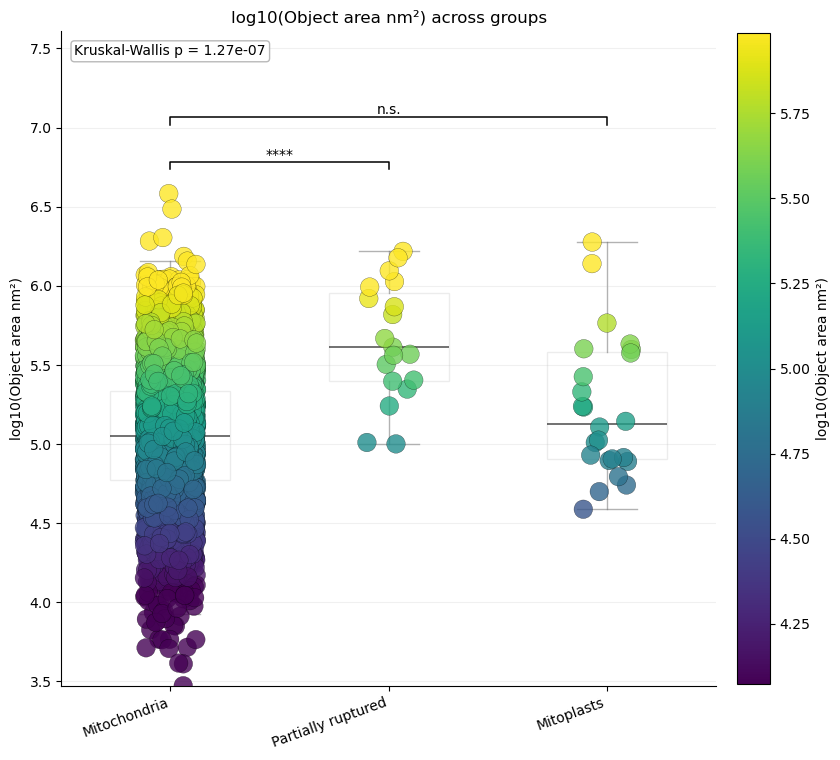

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_mito_partially_ruptured_mitoplasts_log10_object_area.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: Median 32S normalized by field
Using data column: strict_reduced_mean_norm_32S_median
  Mitochondria: 3958
  Partially ruptured: 19
  Mitoplasts: 24
Overall Kruskal-Wallis p = 5.97e-06
                        comparison  n_ref  n_group       U    p_raw   p_holm significance
Mitochondria vs Partially ruptured   3958       19 44625.0 0.159517 0.159517         n.s.
        Mitochondria vs Mitoplasts   3958       24 73917.5 0.000003 0.000005         ****
Median 32S normalized by field: Zoomed y-axis: 0 to 3 | Excluded points: 14


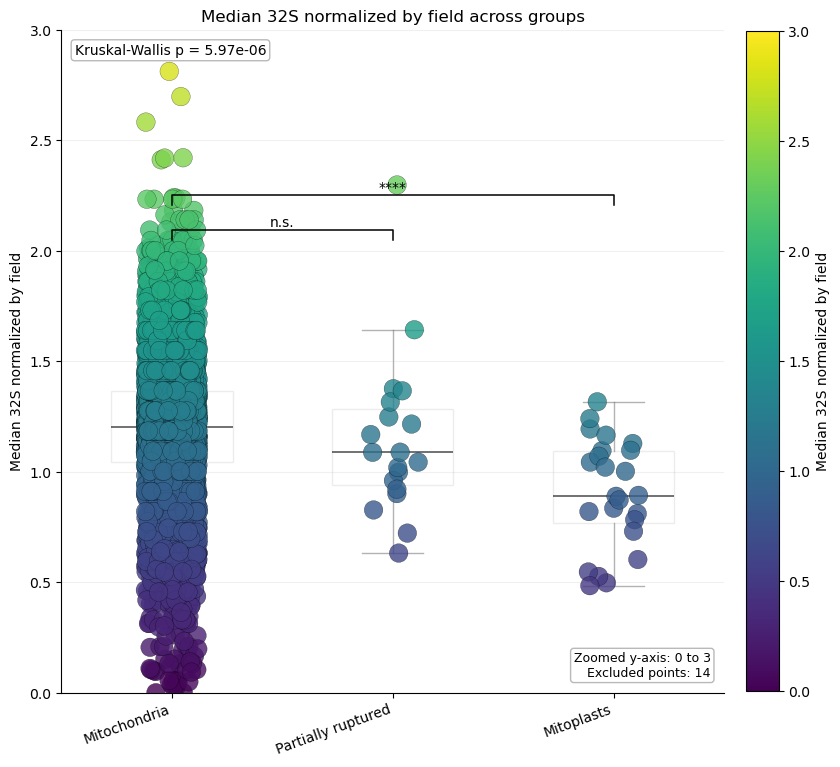

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_mito_partially_ruptured_mitoplasts_median_32S_normalized_by_field.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: Median 31P normalized by field
Using data column: strict_reduced_mean_norm_31P_median
  Mitochondria: 3958
  Partially ruptured: 19
  Mitoplasts: 24
Overall Kruskal-Wallis p = 2.54e-10
                        comparison  n_ref  n_group       U        p_raw       p_holm significance
Mitochondria vs Partially ruptured   3958       19 54925.5 5.101323e-04 5.101323e-04          ***
        Mitochondria vs Mitoplasts   3958       24 79346.0 1.334917e-08 2.669835e-08         ****
Median 31P normalized by field: Zoomed y-axis: 0 to 3 | Excluded points: 108


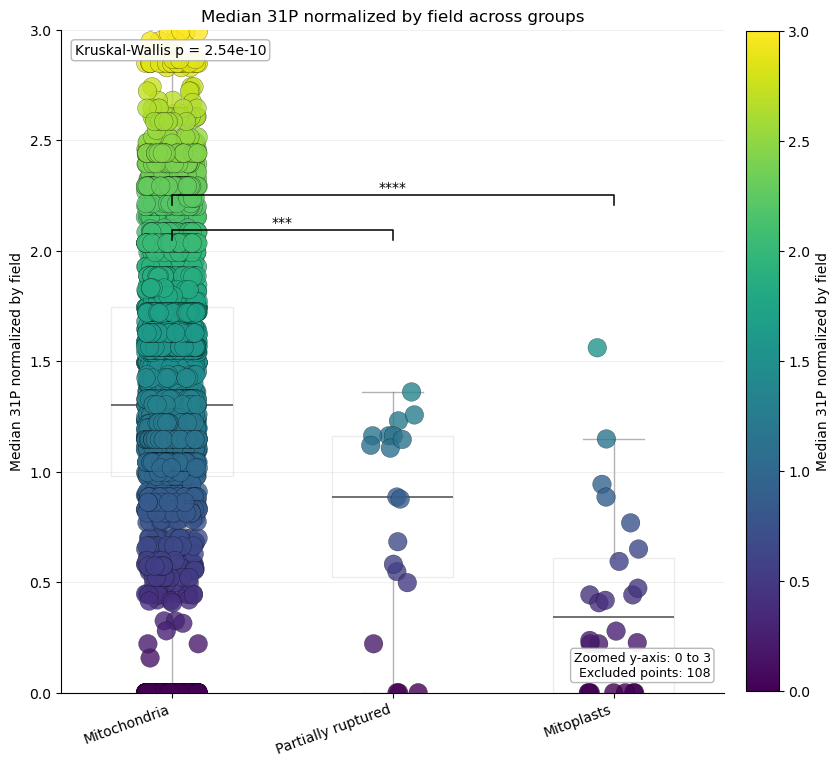

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_mito_partially_ruptured_mitoplasts_median_31P_normalized_by_field.pdf
Partial-wrap flag: using column 'partially_wrapped'

Metric: 12C14N + 12C15N sum normalized by field
Using data column: strict_reduced_mean_norm_sum_12C14N_12C15N_mean
  Mitochondria: 3958
  Partially ruptured: 19
  Mitoplasts: 24
Overall Kruskal-Wallis p = 2.42e-09
                        comparison  n_ref  n_group       U        p_raw       p_holm significance
Mitochondria vs Partially ruptured   3958       19 47535.0 4.664509e-02 4.664509e-02            *
        Mitochondria vs Mitoplasts   3958       24 81112.0 2.142495e-09 4.284990e-09         ****
12C14N + 12C15N sum normalized by field: Zoomed y-axis: 0 to 3 | Excluded points: 0


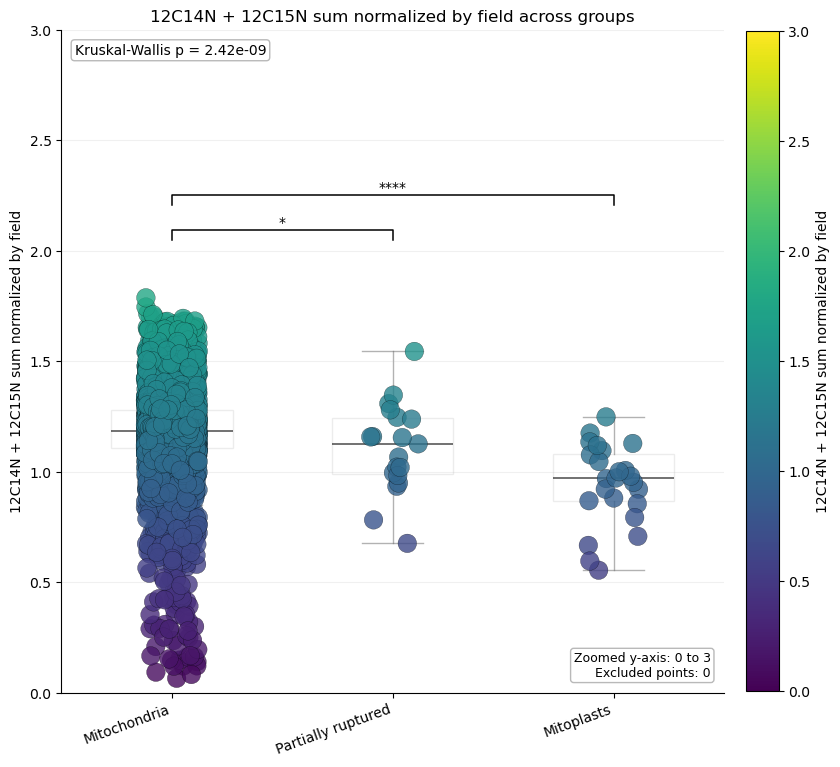

Saved: C:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_lysosome_pulse_chase_analysis\all_chase_mito_partially_ruptured_mitoplasts_sum_12C14N_12C15N_normalized_by_field.pdf


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.colors import Normalize, LogNorm
from scipy.stats import kruskal, mannwhitneyu

# Illustrator-friendly PDF text
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ============================================================
# Paths
# ============================================================
BASE_DIR = Path(globals().get("SCRIPT_DIR", Path.cwd()))
CSV_PATH = BASE_DIR / "MitoFLUXEM_2D_dataset_cleaned_annotations.csv"
LUT_PATH = BASE_DIR / "LUT.csv"
OUT_DIR = Path(globals().get("OUT_DIR", BASE_DIR / "output_lysosome_pulse_chase_analysis"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Constants
# ============================================================
SCORE_COL = "content_morphology_score"
CHASE_COL = "group_name"
FIGSIZE_SQUARE = (8.5, 8.5)

CHASE_ALL = ["SL_0wk-chase", "SL_1wk-chase", "SL_2wk-chase", "SL_4wk-chase"]
CHASE_0WK = ["SL_0wk-chase"]

GROUP_ORDER = [
    "Mitochondria",
    "Partially ruptured",
    "Mitoplasts",
]

# Metric column candidates
AREA_CANDIDATES = ["area_nm2", "area", "object_area", "profile_area"]
S32_CANDIDATES = ["strict_reduced_mean_norm_32S_median", "strict_reduced_mean_norm_32S_mean"]
P31_CANDIDATES = ["strict_reduced_mean_norm_31P_median", "strict_reduced_mean_norm_31P_mean"]
SUM_CANDIDATES = [
    "strict_reduced_mean_norm_sum_12C14N_12C15N_mean",
    "strict_reduced_mean_norm_sum_12C14N_12C15N_median",
]
N15_COL = "strict_reduced_raw_fractional_15N_mean"

# ============================================================
# LUT loader
# ============================================================
def load_fiji_lut(path):
    df_lut = pd.read_csv(path)
    cols = [c.strip().lower() for c in df_lut.columns]

    if "red" in cols:
        r, g, b = cols.index("red"), cols.index("green"), cols.index("blue")
    elif "r" in cols:
        r, g, b = cols.index("r"), cols.index("g"), cols.index("b")
    else:
        r, g, b = 0, 1, 2

    rgb = df_lut.iloc[:, [r, g, b]].to_numpy(dtype=float) / 255.0
    cmap = mpl.colors.ListedColormap(rgb)
    if hasattr(cmap, "with_extremes"):
        cmap = cmap.with_extremes(bad=(0, 0, 0, 0))
    return cmap

CUSTOM_LUT = load_fiji_lut(LUT_PATH)
VIRIDIS = plt.get_cmap("viridis")

# ============================================================
# Helpers
# ============================================================
def save_figure(fig, filename):
    out_path = OUT_DIR / filename
    fig.savefig(out_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path.resolve()}")

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return adj

    ordered = idx[np.argsort(pvals[valid])]
    m = len(ordered)
    running_max = 0.0

    for rank, i in enumerate(ordered):
        raw = pvals[i] * (m - rank)
        running_max = max(running_max, raw)
        adj[i] = min(running_max, 1.0)

    return adj

def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1.1, clip_on=False, zorder=6)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=10, zorder=7)

def box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18):
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_edgecolor(edgecolor)
        patch.set_alpha(alpha)
        patch.set_linewidth(1.0)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.2)
        med.set_alpha(0.65)
    for whisk in bp["whiskers"]:
        whisk.set_color("0.45")
        whisk.set_linewidth(1.0)
        whisk.set_alpha(0.55)
    for cap in bp["caps"]:
        cap.set_color("0.45")
        cap.set_linewidth(1.0)
        cap.set_alpha(0.55)

def parse_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])

def resolve_column(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            print(f"{label}: using column '{c}'")
            return c
    raise ValueError(f"Could not find a valid column for {label}. Tried: {candidates}")

def resolve_partial_mask(df):
    if "partially_wrapped" in df.columns:
        print("Partial-wrap flag: using column 'partially_wrapped'")
        return parse_bool_series(df["partially_wrapped"])
    if "partially_wrapped_group_name" in df.columns:
        print("Partial-wrap flag: using column 'partially_wrapped_group_name'")
        return df["partially_wrapped_group_name"].astype(str).str.strip().str.len() > 0
    print("Partial-wrap flag: falling back to source_label_file text match")
    return df["source_label_file"].astype(str).str.contains("partially_wrapped", case=False, na=False)

def make_group_masks(df):
    partial_mask = resolve_partial_mask(df)
    mito_mask = df["source_label_file"].astype(str).str.contains("Mitochondria", case=False, na=False)
    mitoplast_mask = df["source_label_file"].astype(str).str.contains("Mitoplast", case=False, na=False)

    return {
        "Mitochondria": mito_mask & ~partial_mask & ~mitoplast_mask,
        "Partially ruptured": partial_mask,
        "Mitoplasts": mitoplast_mask,
    }

def build_plot_df(df, metric_col, group_masks):
    rows = []
    counts = {}
    for label in GROUP_ORDER:
        vals = df.loc[group_masks[label], metric_col].dropna().to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        counts[label] = len(vals)
        if len(vals) > 0:
            rows.append(pd.DataFrame({"group": label, "value": vals}))
    if len(rows) == 0:
        return pd.DataFrame(columns=["group", "value"]), counts
    return pd.concat(rows, ignore_index=True), counts

def metric_norm(values, fixed_vmin=None, fixed_vmax=None, use_log=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return Normalize(vmin=0, vmax=1)

    if fixed_vmin is not None and fixed_vmax is not None:
        if use_log:
            vmin = max(float(fixed_vmin), 1e-12)
            vmax = max(float(fixed_vmax), vmin * 1.01)
            return LogNorm(vmin=vmin, vmax=vmax)
        return Normalize(vmin=float(fixed_vmin), vmax=float(fixed_vmax))

    pos = values[values > 0]
    if use_log and len(pos) > 0:
        vmin = np.nanpercentile(pos, 1)
        vmax = np.nanpercentile(pos, 99)
        vmin = max(vmin, np.nanmin(pos))
        vmax = max(vmax, vmin * 1.01)
        return LogNorm(vmin=vmin, vmax=vmax)

    vmin = np.nanpercentile(values, 1)
    vmax = np.nanpercentile(values, 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)
    if vmin == vmax:
        vmax = vmin + 1.0
    return Normalize(vmin=vmin, vmax=vmax)

def zoom_exclusion_count(values, ylim):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    lo, hi = ylim
    return int(np.sum((values < lo) | (values > hi)))

def plot_metric_panel(
    df,
    metric_col,
    metric_label,
    out_name,
    cmap,
    norm=None,
    fixed_ylim=None,
    transform=None,
):
    group_masks = make_group_masks(df)
    plot_df, counts = build_plot_df(df, metric_col, group_masks)
    if plot_df.empty:
        raise ValueError(f"No valid data found for metric '{metric_col}'.")

    transform_excluded = 0
    if transform == "log10":
        positive_mask = plot_df["value"] > 0
        transform_excluded = int((~positive_mask).sum())
        plot_df = plot_df.loc[positive_mask].copy()
        plot_df["value"] = np.log10(plot_df["value"].to_numpy(dtype=float))
        if transform_excluded > 0:
            print(f"{metric_label}: log10 transform excluded {transform_excluded} nonpositive values")

    if plot_df.empty:
        raise ValueError(f"All values were removed for metric '{metric_col}' after transform/filtering.")

    group_names_used = [g for g in GROUP_ORDER if (plot_df["group"] == g).any()]
    group_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_names_used]

    if len(group_data) < 2:
        raise ValueError(f"Need at least two groups with data for metric '{metric_col}'.")

    print(f"\nMetric: {metric_label}")
    print(f"Using data column: {metric_col}")
    for g in group_names_used:
        print(f"  {g}: {counts[g]}")

    overall_p = kruskal(*group_data).pvalue

    ref_name = "Mitochondria"
    ref_vals = plot_df.loc[plot_df["group"] == ref_name, "value"].to_numpy(dtype=float)

    posthoc_rows = []
    raw_pvals = []

    for label in group_names_used:
        if label == ref_name:
            continue
        vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        u = mannwhitneyu(ref_vals, vals, alternative="two-sided")
        raw_pvals.append(u.pvalue)
        posthoc_rows.append(
            {
                "comparison": f"{ref_name} vs {label}",
                "n_ref": len(ref_vals),
                "n_group": len(vals),
                "U": float(u.statistic),
                "p_raw": float(u.pvalue),
            }
        )

    adj_pvals = holm_adjust(raw_pvals)
    for i, ap in enumerate(adj_pvals):
        posthoc_rows[i]["p_holm"] = float(ap)
        posthoc_rows[i]["significance"] = p_to_stars(ap)

    stats_df = pd.DataFrame(posthoc_rows)

    print(f"Overall Kruskal-Wallis p = {overall_p:.3g}")
    if not stats_df.empty:
        print(stats_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    ax.set_box_aspect(1)

    x_pos = np.arange(len(group_names_used))
    box_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_names_used]

    bp = ax.boxplot(
        box_data,
        positions=x_pos,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        zorder=1,
        medianprops=dict(color="black", linewidth=1.2, alpha=0.65),
        whiskerprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
        capprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
    )
    box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18)

    all_vals = plot_df["value"].to_numpy(dtype=float)
    if norm is None:
        norm = metric_norm(all_vals)

    rng = np.random.default_rng(0)
    for i, label in enumerate(group_names_used):
        vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            c=vals,
            cmap=cmap,
            norm=norm,
            s=180,
            alpha=0.8,
            edgecolors="black",
            linewidths=0.2,
            zorder=4,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_names_used, rotation=20, ha="right")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} across groups")
    ax.grid(axis="y", alpha=0.18, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label(metric_label)

    ax.text(
        0.02,
        0.98,
        f"Kruskal-Wallis p = {overall_p:.3g}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
        zorder=8,
    )

    if fixed_ylim is not None:
        lo, hi = fixed_ylim
        ax.set_ylim(lo, hi)

        excluded = zoom_exclusion_count(all_vals, fixed_ylim)
        zoom_msg = f"Zoomed y-axis: {lo:g} to {hi:g}\nExcluded points: {excluded}"
        print(f"{metric_label}: {zoom_msg.replace(chr(10), ' | ')}")

        ax.text(
            0.98,
            0.02,
            zoom_msg,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
            zorder=8,
        )

        ref_idx = group_names_used.index(ref_name)
        base_y = hi - 0.95
        step = 0.16
        h = 0.045
        anno_i = 0
        for _, row in stats_df.iterrows():
            group_label = row["comparison"].split(" vs ")[1]
            if group_label not in group_names_used:
                continue
            grp_idx = group_names_used.index(group_label)
            y = base_y + anno_i * step
            if y + h <= hi - 0.02:
                add_bracket(ax, ref_idx, grp_idx, y, h, row["significance"])
            anno_i += 1
    else:
        ymax = float(np.nanmax(all_vals))
        ymin = float(np.nanmin(all_vals))
        yrng = max(ymax - ymin, 0.05 * max(abs(ymax), 1.0))

        base_y = ymax + 0.05 * yrng
        step = 0.09 * yrng
        h = 0.015 * yrng

        ref_idx = group_names_used.index(ref_name)
        anno_i = 0
        for _, row in stats_df.iterrows():
            group_label = row["comparison"].split(" vs ")[1]
            if group_label not in group_names_used:
                continue
            grp_idx = group_names_used.index(group_label)
            y = base_y + anno_i * step
            add_bracket(ax, ref_idx, grp_idx, y, h, row["significance"])
            anno_i += 1

        upper = base_y + max(1, anno_i) * step + 0.10 * yrng
        if upper > ymax:
            ax.set_ylim(ymin if ymin < ymax else 0, upper)

    if transform == "log10" and transform_excluded > 0:
        ax.text(
            0.98,
            0.02,
            f"log10(area) excluded {transform_excluded} nonpositive values",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
            zorder=8,
        )

    fig.tight_layout()
    save_figure(fig, out_name)

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(CSV_PATH, low_memory=False)
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")

print("Unique chase groups in source data:")
print(sorted(df[CHASE_COL].dropna().astype(str).unique().tolist()))

df_all = df[df[CHASE_COL].astype(str).isin(CHASE_ALL)].copy()
df_0wk = df[df[CHASE_COL].astype(str).eq("SL_0wk-chase")].copy()

print(f"\nRows in all chase groups ({', '.join(CHASE_ALL)}): {len(df_all)}")
print(f"Rows in SL_0wk-chase only: {len(df_0wk)}")
if df_all.empty:
    raise ValueError("No rows found for the full chase-group subset.")
if df_0wk.empty:
    raise ValueError("No rows found for SL_0wk-chase.")

# ============================================================
# Resolve exact metric columns from the dataframe
# ============================================================
N15_COL = resolve_column(df, [N15_COL], "15N incorporation")
AREA_COL = resolve_column(df, AREA_CANDIDATES, "Object area")
S32_COL = resolve_column(df, S32_CANDIDATES, "Median 32S normalized by field")
P31_COL = resolve_column(df, P31_CANDIDATES, "Median 31P normalized by field")
SUM_COL = resolve_column(df, SUM_CANDIDATES, "12C14N + 12C15N sum normalized by field")

# Convert selected metric columns to numeric in both dataframes
for c in [N15_COL, AREA_COL, S32_COL, P31_COL, SUM_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")
    df_0wk[c] = pd.to_numeric(df_0wk[c], errors="coerce")

# ============================================================
# Make the plots
# ============================================================
plot_metric_panel(
    df_0wk,
    N15_COL,
    "15N incorporation",
    "0wk_mito_partially_ruptured_mitoplasts_15N_incorporation.pdf",
    cmap=CUSTOM_LUT,
    norm=Normalize(vmin=0.0037, vmax=0.6),
    fixed_ylim=(0,0.8),
)

plot_metric_panel(
    df_all,
    AREA_COL,
    "log10(Object area nm²)",
    "all_chase_mito_partially_ruptured_mitoplasts_log10_object_area.pdf",
    cmap=VIRIDIS,
    norm=None,
    transform="log10",
)

plot_metric_panel(
    df_all,
    S32_COL,
    "Median 32S normalized by field",
    "all_chase_mito_partially_ruptured_mitoplasts_median_32S_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 3),
)

plot_metric_panel(
    df_all,
    P31_COL,
    "Median 31P normalized by field",
    "all_chase_mito_partially_ruptured_mitoplasts_median_31P_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 3),
)

plot_metric_panel(
    df_all,
    SUM_COL,
    "12C14N + 12C15N sum normalized by field",
    "all_chase_mito_partially_ruptured_mitoplasts_sum_12C14N_12C15N_normalized_by_field.pdf",
    cmap=VIRIDIS,
    norm=Normalize(vmin=0, vmax=3),
    fixed_ylim=(0, 3),
)

C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\1070058891.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw["sample_code"] = raw["sample"].map(canonical_sample_code)
C:\Users\narendradp\AppData\Local\Temp\ipykernel_48924\1070058891.py:134: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw["sample_group"] = raw["sample_code"].map(sample_group)


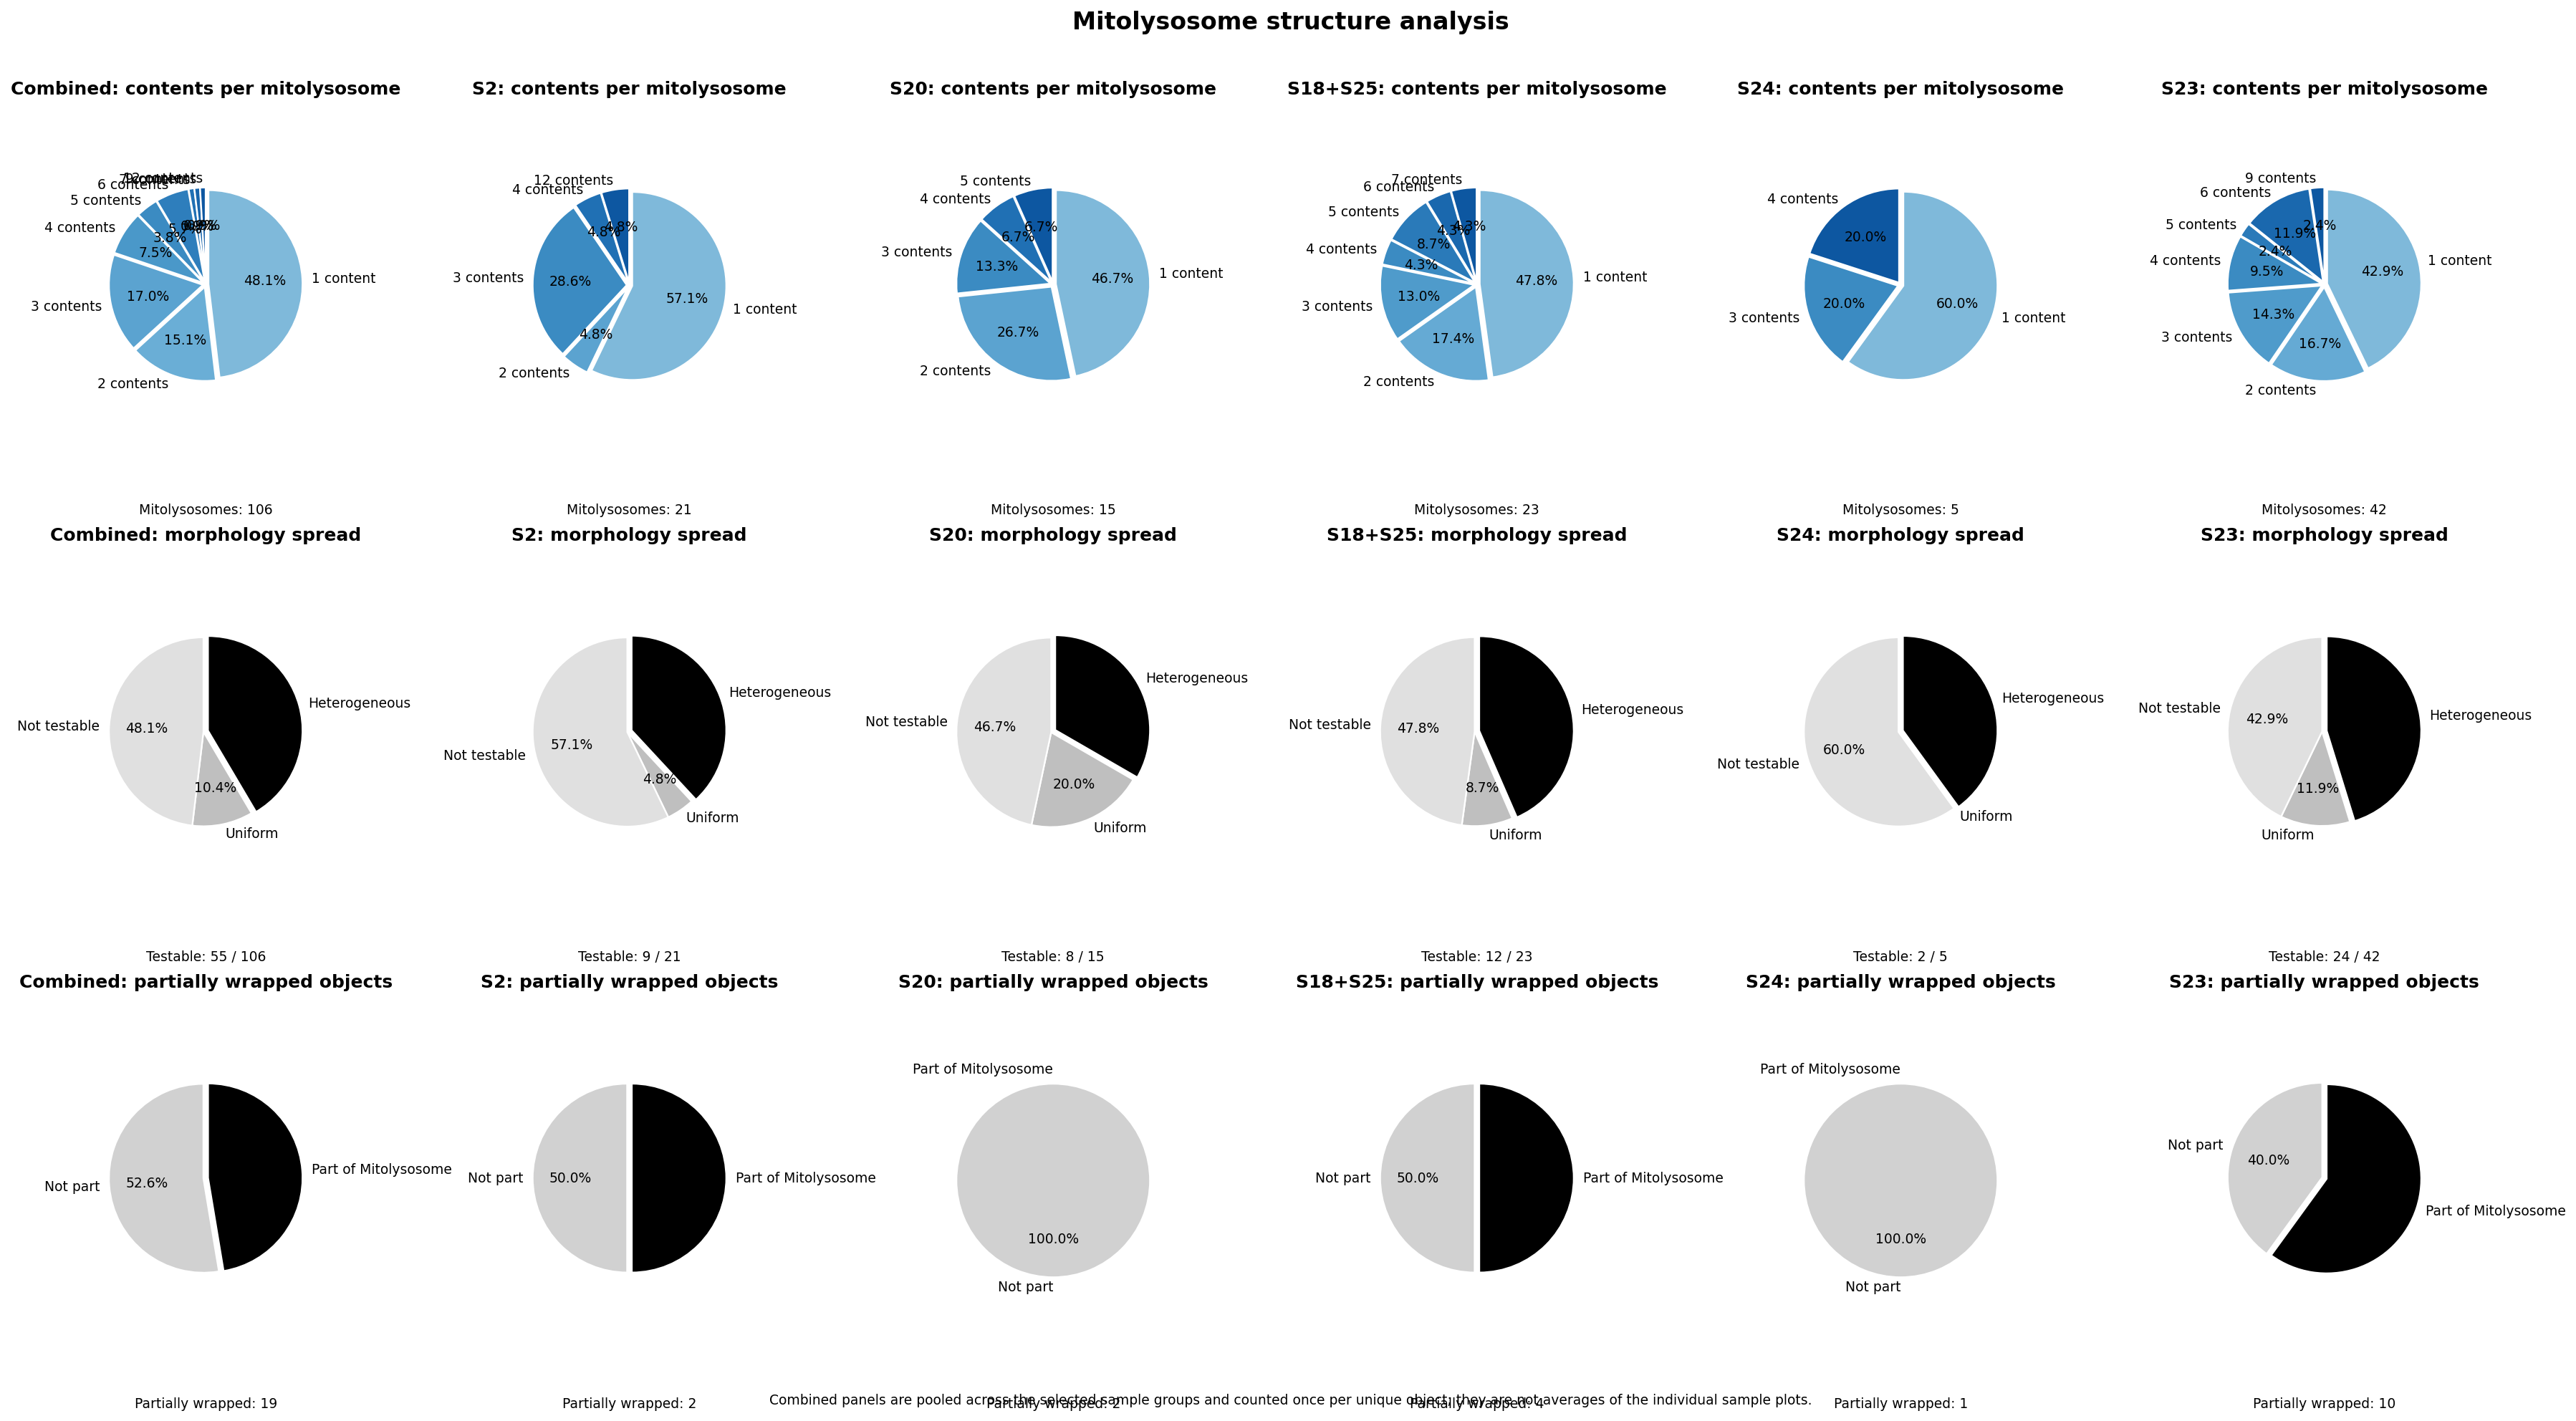

Saved figure: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\mitolysosome_structure_analysis.png
Saved figure: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\mitolysosome_structure_analysis.pdf
Saved summary: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\mitolysosome_structure_analysis_summary.csv
Saved zero-content review list: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\zero_content_mitolysosomes_for_review.csv
Zero-content mitolysosomes censored from analysis: 13


In [10]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# -------------------------------------------------------------------
# File locations
# -------------------------------------------------------------------
filename = "MitoFLUXEM_2D_dataset_cleaned_annotations.csv"
data_file = Path.cwd() / filename
if not data_file.exists():
    data_file = Path("/mnt/data") / filename

outdir = Path.cwd() / "output_mitolysosome_structure_analysis"
outdir.mkdir(exist_ok=True)

# -------------------------------------------------------------------
# Make PDF output more Illustrator-friendly
# -------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titleweight": "bold",
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,    # editable text in Illustrator
})

# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def normalize_bool(series: pd.Series) -> pd.Series:
    """Robust boolean conversion for mixed dtype columns."""
    s = series.copy()
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)

    s_str = s.astype(str).str.strip().str.upper()
    out = pd.Series(False, index=s.index, dtype=bool)
    out.loc[s_str.isin(["TRUE", "T", "YES", "Y", "1"])] = True

    num = pd.to_numeric(s, errors="coerce")
    out.loc[num.eq(1).fillna(False)] = True
    return out


def canonical_sample_code(value) -> str | None:
    """
    Convert sample labels to canonical form:
      S02 -> S2
      S18 -> S18
    """
    m = re.search(r"S0*(\d+)", str(value).strip())
    if not m:
        return None
    return f"S{int(m.group(1))}"


def sample_group(code: str | None) -> str | None:
    """Group S18 and S25 together because they came from the same tissue sample."""
    if code in {"S18", "S25"}:
        return "S18+S25"
    if code in {"S2", "S20", "S23", "S24"}:
        return code
    return None


def summarize_content_counts(qc_df: pd.DataFrame) -> pd.Series:
    """Distribution of the total number of contents per mitolysosome."""
    if qc_df.empty:
        return pd.Series(dtype=int)
    return qc_df["n_total_contents"].value_counts().sort_index()


def summarize_spread(qc_df: pd.DataFrame):
    """
    Proxy for the old KW significance panel.

    - Heterogeneous: at least 2 testable contents and >1 distinct morphology label
    - Uniform:       at least 2 testable contents and exactly 1 morphology label
    - Not testable:   fewer than 2 testable contents
    """
    n_total = len(qc_df)
    n_not_testable = int((qc_df["n_testable_contents"] < 2).sum())
    testable = qc_df[qc_df["n_testable_contents"] >= 2].copy()
    n_testable_mitos = len(testable)

    if n_testable_mitos == 0:
        return 0, 0, n_not_testable, 0, n_total

    hetero_n = int((testable["n_unique_morphology_labels"] > 1).sum())
    uniform_n = int((testable["n_unique_morphology_labels"] <= 1).sum())
    return hetero_n, uniform_n, n_not_testable, n_testable_mitos, n_total


def summarize_partial_wrap(raw_df: pd.DataFrame, group_name: str):
    """
    For partially_wrapped objects, return:
      - n_part_of_mito
      - n_not_part
      - n_total_partial_wrapped
    """
    if group_name == "Combined":
        tmp = raw_df.copy()
    else:
        tmp = raw_df[raw_df["sample_group"].eq(group_name)].copy()

    tmp = tmp.drop_duplicates(subset=["sample_group", "unique_ID"])
    tmp = tmp[tmp["partially_wrapped"]].copy()

    n_total = len(tmp)
    if n_total == 0:
        return 0, 0, 0

    n_part_of_mito = int(tmp["_is_mitolysosome"].sum())
    n_not_part = int((~tmp["_is_mitolysosome"]).sum())
    return n_part_of_mito, n_not_part, n_total


def get_group_subset(df: pd.DataFrame, group_name: str) -> pd.DataFrame:
    if group_name == "Combined":
        return df.copy()
    return df[df["sample_group"].eq(group_name)].copy()


# -------------------------------------------------------------------
# Load and normalize
# -------------------------------------------------------------------
raw = pd.read_csv(data_file, low_memory=False)

# Sample normalization
raw["sample_code"] = raw["sample"].map(canonical_sample_code)
raw["sample_group"] = raw["sample_code"].map(sample_group)

selected_groups = {"S2", "S20", "S18+S25", "S24", "S23"}
raw = raw[raw["sample_group"].isin(selected_groups)].copy()

# Boolean columns
for col in [
    "is_main_mitolysosome",
    "is_mitolysosome_content",
    "partially_wrapped",
    "_is_mitolysosome",
    "content_morphology_rated",
]:
    if col in raw.columns:
        raw[col] = normalize_bool(raw[col])

# -------------------------------------------------------------------
# Identify main mitolysosomes and contents
# Contents are identified by the substring "Contents" in unique_ID.
# -------------------------------------------------------------------
content_mask = (
    raw["unique_ID"].astype(str).str.contains("Contents", case=False, na=False)
    & raw["is_mitolysosome_content"]
    & raw["corrected_mito_unique_ID"].astype(str).str.startswith("Mitolysosome", na=False)
)

main_mask = (
    raw["is_main_mitolysosome"]
    & raw["corrected_mito_unique_ID"].astype(str).str.startswith("Mitolysosome", na=False)
)

main_rows = raw[main_mask].copy()
content_rows = raw[content_mask].copy()

# -------------------------------------------------------------------
# Build mitolysosome-level summary table
# -------------------------------------------------------------------
mito_index = (
    main_rows[["sample_group", "corrected_mito_unique_ID"]]
    .drop_duplicates()
    .rename(columns={"corrected_mito_unique_ID": "mitolysosome"})
)

content_counts = (
    content_rows.groupby(["sample_group", "corrected_mito_unique_ID"])["label_id"]
    .nunique()
    .rename("n_total_contents")
    .reset_index()
    .rename(columns={"corrected_mito_unique_ID": "mitolysosome"})
)

testable_rows = content_rows[
    content_rows["content_morphology_rated"] & content_rows["content_morphology_label"].notna()
].copy()

testable_counts = (
    testable_rows.groupby(["sample_group", "corrected_mito_unique_ID"])["label_id"]
    .nunique()
    .rename("n_testable_contents")
    .reset_index()
    .rename(columns={"corrected_mito_unique_ID": "mitolysosome"})
)

label_diversity = (
    testable_rows.groupby(["sample_group", "corrected_mito_unique_ID"])["content_morphology_label"]
    .agg(lambda s: s.dropna().astype(str).nunique())
    .rename("n_unique_morphology_labels")
    .reset_index()
    .rename(columns={"corrected_mito_unique_ID": "mitolysosome"})
)

qc_table = (
    mito_index
    .merge(content_counts, on=["sample_group", "mitolysosome"], how="left")
    .merge(testable_counts, on=["sample_group", "mitolysosome"], how="left")
    .merge(label_diversity, on=["sample_group", "mitolysosome"], how="left")
)

for c in ["n_total_contents", "n_testable_contents", "n_unique_morphology_labels"]:
    qc_table[c] = qc_table[c].fillna(0).astype(int)

# -------------------------------------------------------------------
# Censor mitolysosomes with 0 contents and save them for review
# -------------------------------------------------------------------
zero_content_mitos = qc_table[qc_table["n_total_contents"] == 0].copy()
zero_content_mitos = zero_content_mitos.sort_values(["sample_group", "mitolysosome"]).reset_index(drop=True)

review_csv = outdir / "zero_content_mitolysosomes_for_review.csv"
zero_content_mitos.to_csv(review_csv, index=False)

# Remove zero-content mitolysosomes from analysis
qc_table = qc_table[qc_table["n_total_contents"] > 0].copy()

# Also keep only contents belonging to mitolysosomes that survived censoring
valid_mitos = set(qc_table["mitolysosome"].astype(str))
content_rows = content_rows[content_rows["corrected_mito_unique_ID"].astype(str).isin(valid_mitos)].copy()
testable_rows = testable_rows[testable_rows["corrected_mito_unique_ID"].astype(str).isin(valid_mitos)].copy()

# -------------------------------------------------------------------
# Plot groups
# -------------------------------------------------------------------
panel_groups = ["Combined", "S2", "S20", "S18+S25", "S24", "S23"]

# -------------------------------------------------------------------
# Save a summary CSV
# -------------------------------------------------------------------
summary_rows = []
for group in panel_groups:
    sub_qc = get_group_subset(qc_table, group)

    hetero_n, uniform_n, n_not_testable, n_testable_mitos, n_total_mitos = summarize_spread(sub_qc)
    partial_part, partial_not_part, n_partial = summarize_partial_wrap(raw, group)

    summary_rows.append({
        "group": group,
        "n_mitolysosomes_after_censoring": n_total_mitos if group != "Combined" else len(qc_table),
        "heterogeneous_mitolysosomes": hetero_n,
        "uniform_mitolysosomes": uniform_n,
        "not_testable_mitolysosomes": n_not_testable,
        "testable_mitolysosomes": n_testable_mitos,
        "partially_wrapped_total": n_partial,
        "partially_wrapped_part_of_mitolysosome": partial_part,
        "partially_wrapped_not_part_of_mitolysosome": partial_not_part,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(outdir / "mitolysosome_structure_analysis_summary.csv", index=False)

# -------------------------------------------------------------------
# Plotting
# -------------------------------------------------------------------
fig, axes = plt.subplots(3, 6, figsize=(24, 13), dpi=150)

# Row 1: contents per mitolysosome
for col, group in enumerate(panel_groups):
    ax = axes[0, col]
    sub_qc = get_group_subset(qc_table, group)
    dist = summarize_content_counts(sub_qc)

    if dist.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        continue

    colors = cm.Blues(np.linspace(0.45, 0.85, len(dist)))
    labels = [f"{n} content" if n == 1 else f"{n} contents" for n in dist.index]

    ax.pie(
        dist.values,
        labels=labels,
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        counterclock=False,
        colors=colors,
        explode=[0.03] * len(dist),
        wedgeprops={"edgecolor": "white", "linewidth": 1.1},
        textprops={"color": "black", "fontsize": 9},
    )

    ax.set_title(f"{group}: contents per mitolysosome")
    ax.axis("equal")
    ax.text(
        0.5, -0.12,
        f"Mitolysosomes: {len(sub_qc)}",
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=9,
    )

# Row 2: heterogeneous / uniform / not testable
for col, group in enumerate(panel_groups):
    ax = axes[1, col]
    sub_qc = get_group_subset(qc_table, group)
    hetero_n, uniform_n, n_not_testable, n_testable_mitos, n_total_mitos = summarize_spread(sub_qc)

    if n_total_mitos == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        continue

    ax.pie(
        [hetero_n, uniform_n, n_not_testable],
        labels=["Heterogeneous", "Uniform", "Not testable"],
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        counterclock=False,
        colors=["black", "0.75", "0.88"],
        explode=[0.05, 0.0, 0.0],
        wedgeprops={"edgecolor": "white", "linewidth": 1.1},
        textprops={"color": "black", "fontsize": 9},
    )

    ax.set_title(f"{group}: morphology spread")
    ax.axis("equal")
    ax.text(
        0.5, -0.12,
        f"Testable: {n_testable_mitos} / {n_total_mitos}",
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=9,
    )

# Row 3: partially wrapped objects
for col, group in enumerate(panel_groups):
    ax = axes[2, col]
    n_part_of_mito, n_not_part, n_total = summarize_partial_wrap(raw, group)

    if n_total == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        continue

    ax.pie(
        [n_part_of_mito, n_not_part],
        labels=["Part of Mitolysosome", "Not part"],
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        counterclock=False,
        colors=["black", "0.82"],
        explode=[0.05, 0.0],
        wedgeprops={"edgecolor": "white", "linewidth": 1.1},
        textprops={"color": "black", "fontsize": 9},
    )

    ax.set_title(f"{group}: partially wrapped objects")
    ax.axis("equal")
    ax.text(
        0.5, -0.12,
        f"Partially wrapped: {n_total}",
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=9,
    )

fig.text(
    0.5, 0.01,
    "Combined panels are pooled across the selected sample groups and counted once per unique object; they are not averages of the individual sample plots.",
    ha="center",
    va="bottom",
    fontsize=9,
)

fig.suptitle("Mitolysosome structure analysis", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()

png_path = outdir / "mitolysosome_structure_analysis.png"
pdf_path = outdir / "mitolysosome_structure_analysis.pdf"

fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved figure: {png_path}")
print(f"Saved figure: {pdf_path}")
print(f"Saved summary: {outdir / 'mitolysosome_structure_analysis_summary.csv'}")
print(f"Saved zero-content review list: {review_csv}")
print(f"Zero-content mitolysosomes censored from analysis: {len(zero_content_mitos)}")


QC: Contents per mitolysosome
S18_Ar3_Mitolysosome1 | total=1 | testable(>=3 meas)=1 | contents=['S18_Ar3_Mitolysosome1_1'] | testable_contents=['S18_Ar3_Mitolysosome1_1']
S18_Ar4_Mitolysosome1 | total=1 | testable(>=3 meas)=1 | contents=['S18_Ar4_Mitolysosome1_1'] | testable_contents=['S18_Ar4_Mitolysosome1_1']
S18_Ar4_Mitolysosome2 | total=5 | testable(>=3 meas)=3 | contents=['S18_Ar4_Mitolysosome2_1', 'S18_Ar4_Mitolysosome2_2', 'S18_Ar4_Mitolysosome2_3', 'S18_Ar4_Mitolysosome2_4', 'S18_Ar4_Mitolysosome2_5'] | testable_contents=['S18_Ar4_Mitolysosome2_1', 'S18_Ar4_Mitolysosome2_2', 'S18_Ar4_Mitolysosome2_3']
S18_Ar4_Mitolysosome3 | total=1 | testable(>=3 meas)=1 | contents=['S18_Ar4_Mitolysosome3_1'] | testable_contents=['S18_Ar4_Mitolysosome3_1']
S18_Ar4_Mitolysosome4 | total=3 | testable(>=3 meas)=2 | contents=['S18_Ar4_Mitolysosome4_1', 'S18_Ar4_Mitolysosome4_2', 'S18_Ar4_Mitolysosome4_3'] | testable_contents=['S18_Ar4_Mitolysosome4_1', 'S18_Ar4_Mitolysosome4_3']
S18_Ar4_Mitolyso

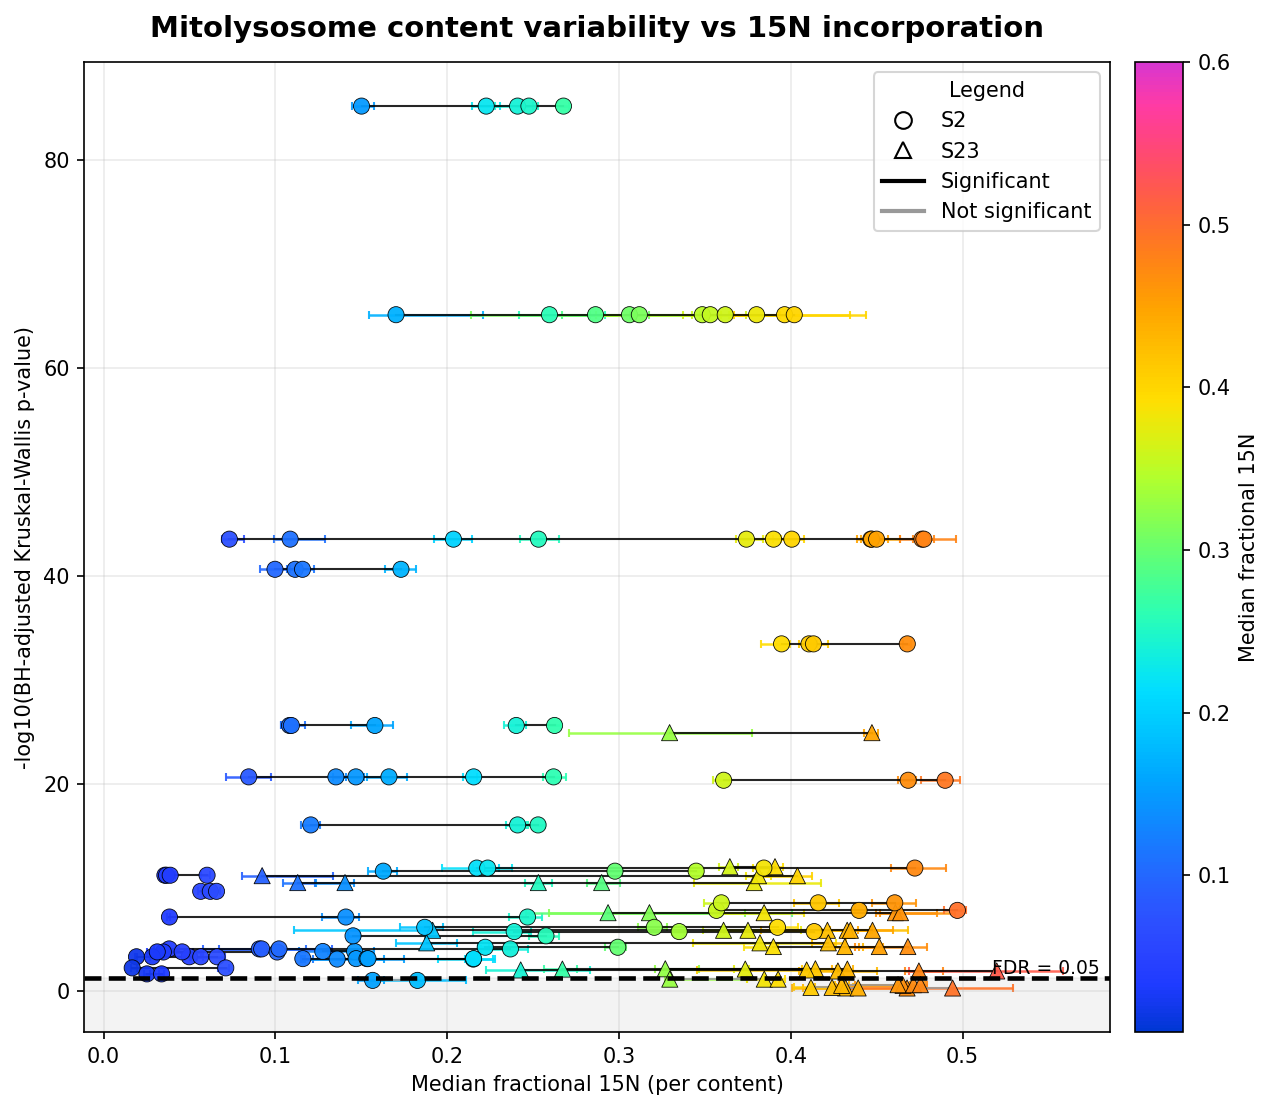

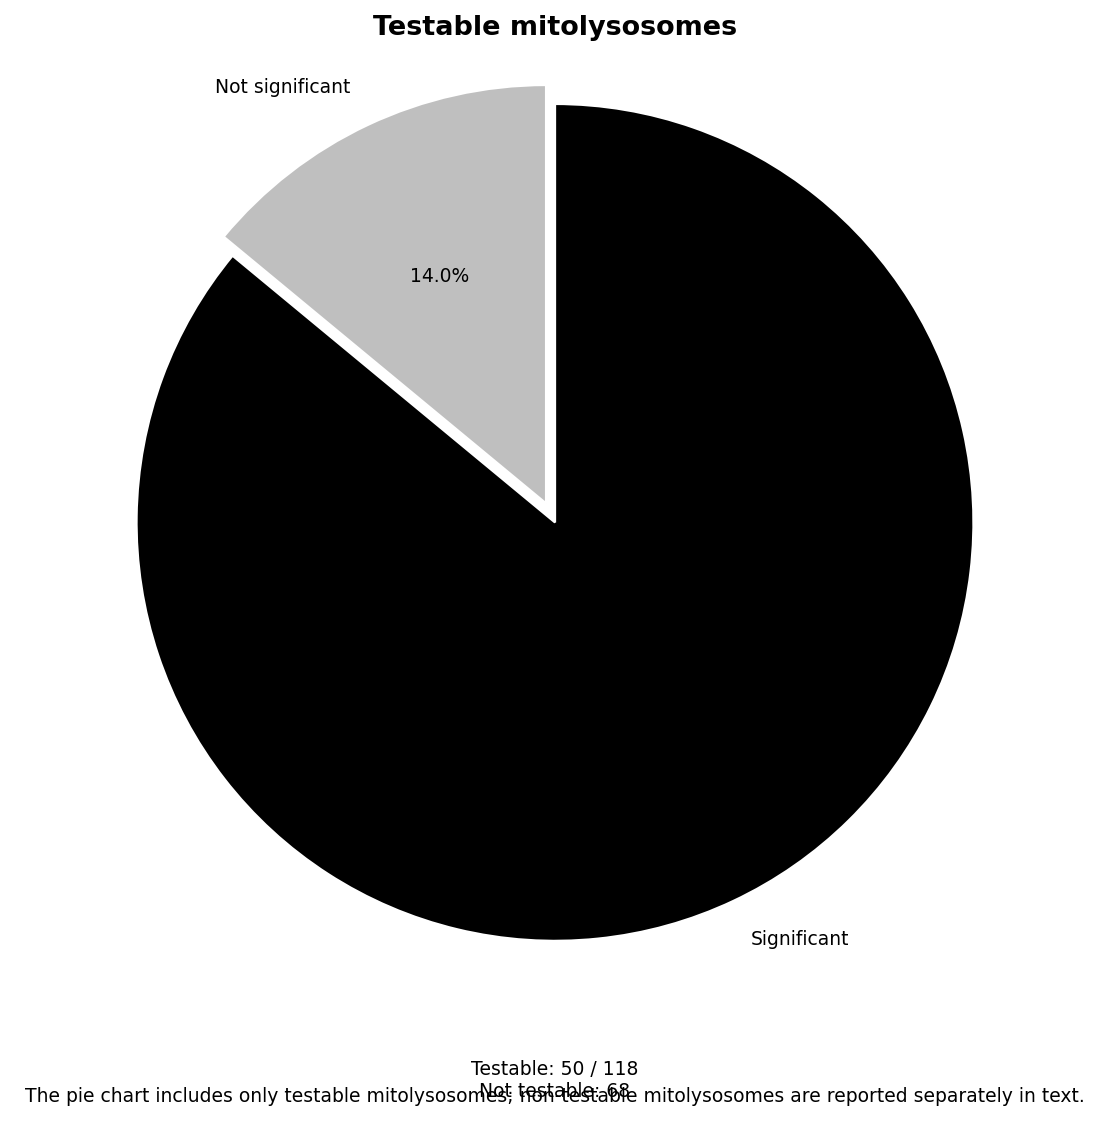

Saved PDF: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\mitolysosome_content_variability_vs_15N.pdf
Saved PDF: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Graph_2D_data\output_mitolysosome_structure_analysis\mitolysosome_significance_pie.pdf


In [13]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from pathlib import Path

# ----------------------------
# Settings for Illustrator-friendly PDF export
# ----------------------------
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
})

# ----------------------------
# File paths / output folder
# ----------------------------
base_dir = Path.cwd()
data_path = base_dir / "combined_output.csv"
lut_path = base_dir / "LUT.csv"
npz_dir = base_dir / "MitoFLUXEM_npz_input"
outdir = base_dir / "output_mitolysosome_structure_analysis"
outdir.mkdir(exist_ok=True)

# ----------------------------
# Load data only if needed
# ----------------------------
if "df" not in globals():
    df = pd.read_csv(data_path)

if "lut" not in globals():
    lut = pd.read_csv(lut_path)

# ----------------------------
# Choose the 15N source from the dataframe if available
# ----------------------------
def pick_first_existing_column(frame, candidates):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

values_col = pick_first_existing_column(df, [
    "strict_reduced_raw_fractional_15N_values",
    "reduced_raw_fractional_15N_values",
    "raw_fractional_15N_values",
    "fractional_15N_values",
    "fractional_15N",
    "15N_values",
    "15N",
])

# ----------------------------
# Custom LUT colormap
# ----------------------------
lut_rgb = lut[["Red", "Green", "Blue"]].to_numpy() / 255.0
custom_cmap = ListedColormap(lut_rgb, name="custom_lut")

vmin_15n = 0.0037
vmax_15n = 0.6
norm_15n = Normalize(vmin=vmin_15n, vmax=vmax_15n, clip=True)

# ----------------------------
# Restrict to mitolysosome contents
# ----------------------------
df_ML = df[df["source_label_file"].astype(str).str.contains("Mitolysosome", na=False)].copy()
df_ML_contents = df_ML[df_ML["source_label_file"].astype(str).str.contains("Contents", na=False)].copy()

# ----------------------------
# Identity system
# ----------------------------
df_ML_contents["mito_name"] = df_ML_contents["source_label_file"].astype(str).str.split("-", n=1).str[0]
df_ML_contents["content_id"] = df_ML_contents["label_id"].astype(str)

df_ML_contents["MitoLysosome_Label"] = (
    df_ML_contents["sample"].astype(str) + "_" +
    df_ML_contents["mito_name"].astype(str)
)

df_ML_contents["QC_label"] = df_ML_contents["MitoLysosome_Label"] + "_" + df_ML_contents["content_id"]
df_ML_contents["sample_prefix"] = df_ML_contents["sample"].astype(str).str.split("_").str[0]

# ----------------------------
# Parse list-valued 15N column
# ----------------------------
def parse_value_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple, np.ndarray)):
                return list(parsed)
            return [parsed]
        except Exception:
            cleaned = x.strip("[]()")
            if not cleaned:
                return []
            return [item.strip() for item in cleaned.split(",")]
    return [x]

def load_fractional_15n_from_npz(npz_filename):
    npz_path = npz_dir / str(npz_filename)
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing npz file: {npz_path}")
    arr = np.load(npz_path, allow_pickle=True)
    if "fractional_15N" not in arr.files:
        raise KeyError(f"'fractional_15N' not found in {npz_path.name}")
    vals = np.asarray(arr["fractional_15N"]).ravel()
    vals = pd.to_numeric(pd.Series(vals), errors="coerce").dropna().tolist()
    return vals

if values_col is not None:
    df_ML_contents["value_list"] = df_ML_contents[values_col].apply(parse_value_list)
    if "npz_file" in df_ML_contents.columns:
        need_npz = df_ML_contents["value_list"].apply(len).eq(0)
        df_ML_contents.loc[need_npz, "value_list"] = df_ML_contents.loc[need_npz, "npz_file"].apply(load_fractional_15n_from_npz)
else:
    if "npz_file" not in df_ML_contents.columns:
        raise KeyError("Neither a usable 15N values column nor 'npz_file' is available.")
    df_ML_contents["value_list"] = df_ML_contents["npz_file"].apply(load_fractional_15n_from_npz)

expanded = (
    df_ML_contents
    .explode("value_list")
    .rename(columns={"value_list": "fractional_15N"})
    .copy()
)

expanded["fractional_15N"] = pd.to_numeric(expanded["fractional_15N"], errors="coerce")
expanded = expanded.dropna(subset=["fractional_15N", "MitoLysosome_Label", "content_id"])

# ----------------------------
# QC: count measurements per content
# ----------------------------
content_measurements = (
    expanded.groupby(["MitoLysosome_Label", "content_id"], as_index=False)
    .agg(
        n_measurements=("fractional_15N", "size"),
        median_15N=("fractional_15N", "median"),
        q1=("fractional_15N", lambda s: s.quantile(0.25)),
        q3=("fractional_15N", lambda s: s.quantile(0.75)),
    )
)

content_measurements["testable"] = content_measurements["n_measurements"] >= 3
content_measurements["QC_label"] = (
    content_measurements["MitoLysosome_Label"] + "_" + content_measurements["content_id"].astype(str)
)

qc_table = (
    content_measurements.groupby("MitoLysosome_Label")
    .agg(
        n_total_contents=("content_id", "size"),
        n_testable_contents=("testable", "sum"),
        contents=("QC_label", list),
        testable_contents=("QC_label", lambda s: list(s[content_measurements.loc[s.index, "testable"]])),
    )
    .reset_index()
)

print("\nQC: Contents per mitolysosome")
for _, row in qc_table.iterrows():
    print(
        f"{row['MitoLysosome_Label']} | "
        f"total={row['n_total_contents']} | "
        f"testable(>=3 meas)={row['n_testable_contents']} | "
        f"contents={row['contents']} | "
        f"testable_contents={row['testable_contents']}"
    )

total_contents = int(qc_table["n_total_contents"].sum())
testable_contents = int(qc_table["n_testable_contents"].sum())
not_testable_contents = total_contents - testable_contents

print("\nContent-level summary")
print(f"Total contents: {total_contents}")
print(f"Testable contents (>=3 measurements): {testable_contents}")
print(f"Not testable contents: {not_testable_contents}")

# Keep only testable contents for downstream analysis
testable_content_labels = set(content_measurements.loc[content_measurements["testable"], "QC_label"])

expanded["QC_label"] = expanded["MitoLysosome_Label"] + "_" + expanded["content_id"].astype(str)
expanded_testable = expanded[expanded["QC_label"].isin(testable_content_labels)].copy()

# ----------------------------
# Kruskal-Wallis per mitolysosome
# ----------------------------
kw_rows = []

for mito_id, mito_sub in expanded_testable.groupby("MitoLysosome_Label"):
    content_groups = {
        c: g["fractional_15N"].to_numpy()
        for c, g in mito_sub.groupby("content_id")
        if len(g) >= 3
    }

    n_total_content_groups = expanded[expanded["MitoLysosome_Label"] == mito_id]["content_id"].nunique()
    n_testable_content_groups = len(content_groups)

    if n_testable_content_groups < 2:
        kw_rows.append({
            "mitolysosome": mito_id,
            "n_total_content_groups": n_total_content_groups,
            "n_testable_content_groups": n_testable_content_groups,
            "kw_p": np.nan,
            "note": "fewer than 2 content groups with >=3 measurements"
        })
        continue

    try:
        _, kw_p = kruskal(*content_groups.values())
    except Exception as e:
        kw_rows.append({
            "mitolysosome": mito_id,
            "n_total_content_groups": n_total_content_groups,
            "n_testable_content_groups": n_testable_content_groups,
            "kw_p": np.nan,
            "note": str(e)
        })
        continue

    kw_rows.append({
        "mitolysosome": mito_id,
        "n_total_content_groups": n_total_content_groups,
        "n_testable_content_groups": n_testable_content_groups,
        "kw_p": kw_p,
        "note": ""
    })

kw_results = pd.DataFrame(kw_rows)

mask = kw_results["kw_p"].notna()
if mask.any():
    reject, p_adj, _, _ = multipletests(kw_results.loc[mask, "kw_p"], method="fdr_bh")
    kw_results.loc[mask, "kw_p_fdr"] = p_adj
    kw_results.loc[mask, "kw_sig"] = reject
else:
    kw_results["kw_p_fdr"] = np.nan
    kw_results["kw_sig"] = False

print("\nKruskal-Wallis results with BH correction:")
print(kw_results.to_string(index=False))

# Mitolysosome-level summary for the pie chart
total_mitos = int(len(qc_table))
testable_mitos = int((qc_table["n_testable_contents"] >= 2).sum())
not_testable_mitos = total_mitos - testable_mitos
sig_mitos = int(kw_results["kw_sig"].fillna(False).sum())
nonsig_mitos = int(testable_mitos - sig_mitos)

print("\nMitolysosome-level summary")
print(f"Total mitolysosomes: {total_mitos}")
print(f"Testable mitolysosomes (>=2 testable contents): {testable_mitos}")
print(f"Not testable mitolysosomes: {not_testable_mitos}")
print(f"Significant mitolysosomes: {sig_mitos}")
print(f"Not significant mitolysosomes: {nonsig_mitos}")

# ----------------------------
# Build plot data using only testable contents
# ----------------------------
content_summary = (
    expanded_testable.groupby(["MitoLysosome_Label", "content_id"], as_index=False)["fractional_15N"]
    .agg(
        median_15N="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
)

content_summary["sample_prefix"] = content_summary["MitoLysosome_Label"].str.split("_").str[0]

plot_df = content_summary.merge(
    kw_results,
    left_on="MitoLysosome_Label",
    right_on="mitolysosome",
    how="left"
).dropna(subset=["kw_p_fdr", "median_15N"]).copy()

content_counts = plot_df.groupby("MitoLysosome_Label")["content_id"].nunique()
valid_ids = content_counts[content_counts >= 2].index
plot_df = plot_df[plot_df["MitoLysosome_Label"].isin(valid_ids)].copy()
plot_df["neglog10_q"] = -np.log10(plot_df["kw_p_fdr"].clip(lower=1e-300))

# ----------------------------
# FIGURE 1: Mitolysosome content variability vs 15N incorporation
# ----------------------------
marker_map = {
    "S2": "o",
    "S23": "^",
}

fig1, ax1 = plt.subplots(figsize=(9, 7.5), dpi=150)

for mito_id, group in plot_df.groupby("MitoLysosome_Label"):
    group = group.sort_values("median_15N")
    sample = group["sample_prefix"].iloc[0]
    sig = bool(group["kw_sig"].iloc[0])

    x = group["median_15N"].to_numpy()
    y = group["neglog10_q"].to_numpy()

    for xi, yi, q1, q3 in zip(x, y, group["q1"].to_numpy(), group["q3"].to_numpy()):
        color = custom_cmap(norm_15n(xi))
        ax1.errorbar(
            xi,
            yi,
            xerr=[[xi - q1], [q3 - xi]],
            fmt="none",
            ecolor=color,
            elinewidth=1.2,
            capsize=2,
            alpha=0.9,
            zorder=1,
        )

    line_color = "black" if sig else "0.6"
    ax1.plot(
        x,
        y,
        color=line_color,
        linewidth=1.0,
        alpha=0.85,
        zorder=2,
    )

    ax1.scatter(
        x,
        y,
        c=x,
        cmap=custom_cmap,
        norm=norm_15n,
        s=60,
        marker=marker_map.get(sample, "o"),
        edgecolors="black",
        linewidths=0.4,
        alpha=0.95,
        zorder=3,
    )

threshold = -np.log10(0.05)
ymin, ymax = ax1.get_ylim()
ax1.axhspan(ymin, threshold, color="lightgray", alpha=0.25, zorder=0)
ax1.axhline(threshold, linestyle="--", linewidth=2.2, color="black", zorder=4)
ax1.set_ylim(ymin, ymax)

ax1.text(
    0.99,
    threshold + 0.03,
    "FDR = 0.05",
    transform=ax1.get_yaxis_transform(),
    ha="right",
    va="bottom",
    fontsize=9,
    color="black",
)

ax1.set_xlabel("Median fractional 15N (per content)")
ax1.set_ylabel("-log10(BH-adjusted Kruskal-Wallis p-value)")
ax1.set_title("Mitolysosome content variability vs 15N incorporation", fontsize=14, pad=12)
ax1.grid(True, alpha=0.25, zorder=0)

legend_elements = [
    Line2D([0], [0], marker="o", linestyle="None", label="S2",
           markerfacecolor="white", markeredgecolor="black", markersize=8),
    Line2D([0], [0], marker="^", linestyle="None", label="S23",
           markerfacecolor="white", markeredgecolor="black", markersize=8),
    Line2D([0], [0], color="black", lw=2, label="Significant"),
    Line2D([0], [0], color="0.6", lw=2, label="Not significant"),
]
ax1.legend(handles=legend_elements, title="Legend", frameon=True, loc="best")

sm = ScalarMappable(norm=norm_15n, cmap=custom_cmap)
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax1, pad=0.02)
cbar.set_label("Median fractional 15N")

fig1.tight_layout()
pdf1_path = outdir / "mitolysosome_content_variability_vs_15N.pdf"
fig1.savefig(pdf1_path, bbox_inches="tight")
plt.show()

# ----------------------------
# FIGURE 2: Pie chart for testable mitolysosomes only
# ----------------------------
fig2, ax2 = plt.subplots(figsize=(7.5, 7.5), dpi=150)

pie_sizes = [sig_mitos, nonsig_mitos]
pie_labels = ["Significant", "Not significant"]
pie_colors = ["black", "0.75"]

ax2.pie(
    pie_sizes,
    labels=pie_labels,
    autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    explode=[0.05, 0.0],
    wedgeprops={"edgecolor": "white", "linewidth": 1.1},
    textprops={"color": "black", "fontsize": 9},
)

ax2.set_title("Testable mitolysosomes", fontsize=13, pad=10)
ax2.axis("equal")
ax2.text(
    0.5, -0.12,
    f"Testable: {testable_mitos} / {total_mitos}\nNot testable: {not_testable_mitos}",
    ha="center", va="center",
    transform=ax2.transAxes,
    fontsize=9,
)

fig2.text(
    0.5, 0.01,
    "The pie chart includes only testable mitolysosomes; non-testable mitolysosomes are reported separately in text.",
    ha="center",
    va="bottom",
    fontsize=9,
)

fig2.tight_layout()
pdf2_path = outdir / "mitolysosome_significance_pie.pdf"
fig2.savefig(pdf2_path, bbox_inches="tight")
plt.show()

print(f"Saved PDF: {pdf1_path}")
print(f"Saved PDF: {pdf2_path}")